# Transcription Factor Project - KOLF2.1J Clustering & Embedding
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the KOLF2.1J Perturb-seq dataset from the Nourreddine et al. (2024) preprint to investigate the effects of transcription factor knockdowns (TF KDs)

**Guiding Questions:** What do TF KD effects reveal about:
* the transcriptional regulatory network of hiPSCs?
* TF crosstalk and co-regulation?
* cell lineage?
* how TFs influence chromatin remodeling?

# Import statements

In [1]:
# Using psp_env virtual environment
import sys
import os
repo_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if repo_root not in sys.path:
    sys.path.insert(0, "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/")

import psp
import gc
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

In [2]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style("ticks")
from scipy import sparse

# Data preprocessing: normalization, feature selection, subsetting KD cells only

Normalize data to median NTC UMI count and then perform relative z-normalization

In [3]:
filepath = "/home/ranwyl/data_tf_project/KOLF_Pan_Genome_Alpha_CPMnorm_KD_ETest_Gene_gRNA_Filtered.h5ad"
adata = psp.utils.read_anndata(filepath)
adata

AnnData object with n_obs × n_vars = 60132 × 16115
    obs: 'gRNA', 'n_gRNA', 'n_gRNA_UMIs', 'gene_target', 'celltype', 'perturbation_type', 'n_UMI_counts', 'n_genes', 'perturbed', 'channel', 'perturbation', 'gene_target_ensembl_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_ids', 'feature_types', 'n_UMI_counts', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'etest_results', 'etest_results_params'
    layers: 'counts'

In [4]:
adata.obs["batch"] = "ALPHA"

In [5]:
def replogle_normalize(adata: ad.AnnData,
                        batch_key: str="gem_group",
                        ctrl_key: str="perturbed",
                        ctrl_value: str="False",
                        UMI_count_key: str="UMI_count",
                        counts_layer: str | None = None,
                        save_pre_norm_layer: bool=False,
                        pre_norm_layer: str | None = None,
                        save_norm_layer: bool=True,
                        norm_layer: str="replogle_norm") -> None:
    """
    Normalize to median (core) NTC UMI count and relative z-normalize
    KD cells to NTC cells in the same batch.
    """
    # Save counts
    if save_pre_norm_layer:
        print(f"Saving pre-normalized data to '{pre_norm_layer}' layer")
        if pre_norm_layer in adata.layers:
            print(f"Overwriting existing '{pre_norm_layer}' layer")
        adata.layers[pre_norm_layer] = adata.X.copy()

    # Use counts layer if available, otherwise adata.X
    if counts_layer:
        if counts_layer in adata.layers:
            print(f"Setting .X to '{counts_layer}' layer")
            adata.X = adata.layers[counts_layer].copy()

    # Normalize to median NTC UMI count
    print("Normalizing to median NTC UMI count")
    median_umi_count = adata[adata.obs[ctrl_key] == ctrl_value
                             ].obs[UMI_count_key].median()
    sc.pp.normalize_total(adata, target_sum=median_umi_count)
    
    # Pull out dense X as a numpy array
    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()     # now X is (n_obs, n_vars) numpy
    else:
        X = X.copy()        # be safe if adata.X is a view

    out = np.zeros_like(X)  # final z-normalized pseudobulk

    # For each batch, compute mu/std on controls and fill out
    print("Performing relative z-normalization")
    obs = adata.obs
    for batch in obs[batch_key].unique():
        mask_batch = (obs[batch_key] == batch).values
        mask_ctrl  = mask_batch & (obs[ctrl_key] == ctrl_value).values

        # get control pseudocounts and compute mean/std per gene
        ctrl_mat = X[mask_ctrl]           # shape (#ctrl_cells, n_vars)
        mu  = ctrl_mat.mean(axis=0)       # (n_vars,)
        std = ctrl_mat.std(axis=0)
        # prevent divide-by-zero error temporarily
        zero_std_mask = (std == 0)
        std[zero_std_mask] = 1.0  

        # z-normalize all cells in this batch
        # broadcasting: (n_cells_in_batch, n_vars) - (n_vars,) / (n_vars,)
        out[mask_batch] = (X[mask_batch] - mu) / std
        # set values where std = 0 to NaN
        out[mask_batch][:, zero_std_mask] = np.nan

    # Clip in-place
    np.clip(out, -10, 10, out=out)

    # Write back
    adata.X = out

    # Save to new layer
    if save_norm_layer:
        print(f"Saving normalized data to '{norm_layer}' layer")
        if norm_layer in adata.layers:
            print(f"Overwriting existing '{norm_layer}' layer")
        adata.layers[norm_layer] = adata.X.copy()
        print(f"Normalized data stored in .X and '{norm_layer}' layer")
    else:
        print(f"Normalized data stored in .X")

In [6]:
replogle_normalize(adata, batch_key="batch", 
                   counts_layer="counts", UMI_count_key="n_UMI_counts",
                   save_norm_layer=True, norm_layer="replogle_norm")

Setting .X to 'counts' layer
Normalizing to median NTC UMI count
normalizing counts per cell
    finished (0:00:00)
Performing relative z-normalization


Saving normalized data to 'replogle_norm' layer
Normalized data stored in .X and 'replogle_norm' layer


Feature selection

In [7]:
def validate_3_DGE_results_dfs(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Check that 3 DGE analysis results DFs have same rows and cols.
    """
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    DGE_results_1 = DGE_results_dfs[0].sort_index()
    DGE_results_2 = DGE_results_dfs[1].sort_index()
    DGE_results_3 = DGE_results_dfs[2].sort_index()
    if not (DGE_results_1.index.equals(DGE_results_2.index) and 
            DGE_results_2.index.equals(DGE_results_3.index)):
        raise ValueError("DGE results DataFrames must have same index (genes)")
    if not ((set(DGE_results_1.columns) == set(DGE_results_2.columns)) &
            (set(DGE_results_2.columns) == set(DGE_results_3.columns))):
        raise ValueError("DGE results DataFrames must have same columns (KDs)")
    # Return DFs with sorted index
    return [DGE_results_1, DGE_results_2, DGE_results_3]

def build_3_run_DEGs_dict(DGE_results_dfs: list[pd.DataFrame],
                          p_threshold: float,
                          p_threshold_type: str="pvalue",
                          target_type: str="gRNA",
                          lfc_threshold: float = 0,
                          lfc_col: str = "log2FoldChange",
                          validate: bool=True,
                          remove_self_DEGs: bool=True,
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that are DEGs of that KD (pass significance 
    and LFC thresholds) in at least 2 DGE analysis runs.
    If remove_self_DEGs is True, then Gene A is removed from the DEG list
    for Gene KD A and so on.
    """
    # Check for valid significance threshold
    if p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("p_threshold_type must be 'pvalue' or 'padj'")
    # Check for valid target type
    if target_type not in ("gRNA", "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target'")
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Find genes that are DEGs of the same KD in at least 2 DGE runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if target_type == "gRNA":
        targets = {"_".join(col.split("_")[:2]) for col in DGE_results_1.columns}
    else:
        targets = {col.split("_")[0] for col in DGE_results_1.columns}
    targets = sorted(list(targets))
    DEGs_dict = dict()
    for target in targets:
        target_p_col = f"{target}_{p_threshold_type}"
        target_lfc_col = f"{target}_{lfc_col}"
        DEGs_run1 = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (abs(DGE_results_1[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run2 = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (abs(DGE_results_2[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run3 = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (abs(DGE_results_3[target_lfc_col]) > lfc_threshold)].index)                                 
        DEGs_at_least_2 = ((DEGs_run1 & DEGs_run2) | (DEGs_run2 & DEGs_run3) |
                           (DEGs_run1 & DEGs_run3))
        # Remove gene target from DEG list
        if remove_self_DEGs:
            self_gene = target if target_type == "gene_target" else target.split("_")[0]
            DEGs_at_least_2 = DEGs_at_least_2 - {self_gene}
        DEGs_dict[target] = DEGs_at_least_2
    return DEGs_dict

def build_3_run_n_DEGs_df(DEGs_dict: dict[str, set[str]]
                          ) -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame reporting
    the number of DEGs per KD.
    """
    kds = list(DEGs_dict.keys())
    n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df.sort_values(by="n_DEGs", ascending=False)
    return n_DEGs_df

def build_cluster_DEGs_dict(DEGs_dict: dict[str, set[str]],
                            cluster_df: pd.DataFrame
                            ) -> dict[int, set[str]]:
    """
    Build dict of DEGs per cluster.
    """
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_DEGs_dict = {
        cl: set().union(*[DEGs_dict[kd] for kd in cluster_kd_dict[cl]])
        for cl in cluster_kd_dict
    }
    return cluster_DEGs_dict

def plot_n_DEGs_per_cluster(cluster_DEGs_dict: dict[int, set[str]],
                            title: str, 
                            figsize: tuple[int, int] = (6,3), 
                            xlabel: str="Cluster", 
                            ymax: int | None = None,
                            color: str = "tab:blue"):
    """
    Given a dict of DEGs per cluster, plot number of DEGs per cluster.
    """
    clusters = sorted(list(cluster_DEGs_dict.keys()))
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in clusters]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=clusters, y=n_DEGs, ax=ax, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# DEGs per cluster")
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

def get_DEG_feature_set(DEGs_dict: dict):
    return {gene for DEG_set in DEGs_dict.values() for gene in DEG_set}

In [8]:
filepath1 = "/home/ranwyl/results_tf_project/KOLF_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_kolf_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/KOLF_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_kolf_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/KOLF_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_kolf_3 = pd.read_pickle(filepath3)
de_results_kolf = [de_results_kolf_1, de_results_kolf_2, de_results_kolf_3]

No self-DEGs

In [9]:
kd_deg_dict_kolf = build_3_run_DEGs_dict(de_results_kolf,
    p_threshold=0.02, lfc_threshold=0.25, target_type="gene_target",
    remove_self_DEGs=True)

In [10]:
n_degs_df = build_3_run_n_DEGs_df(kd_deg_dict_kolf)
n_degs_df.head(20)

,n_DEGs
POU5F1,417
DNMT1,121
ZNF521,81
THAP12,42
ZNF396,41
NANOG,40
ADNP2,30
PHF20,29
CHAMP1,23
POU5F1B,23


In [11]:
features = get_DEG_feature_set(kd_deg_dict_kolf)
print(f"Feature set for clustering/embedding (excluding self-DEGs): {len(features)} genes")

Feature set for clustering/embedding (excluding self-DEGs): 909 genes


In [12]:
tf_kds_to_keep = set(n_degs_df[n_degs_df["n_DEGs"] > 0].index)
print(f"TF KDs with 1+ DEGs (excluding self-DEGs): {len(tf_kds_to_keep)}")

TF KDs with 1+ DEGs (excluding self-DEGs): 180


Filter genes to DEGs only

In [13]:
adata_mde = adata[:, adata.var_names.isin(features)]
adata_mde

View of AnnData object with n_obs × n_vars = 60132 × 909
    obs: 'gRNA', 'n_gRNA', 'n_gRNA_UMIs', 'gene_target', 'celltype', 'perturbation_type', 'n_UMI_counts', 'n_genes', 'perturbed', 'channel', 'perturbation', 'gene_target_ensembl_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant', 'batch'
    var: 'gene_ids', 'feature_types', 'n_UMI_counts', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'etest_results', 'etest_results_params'
    layers: 'counts', 

Filter cells to TF KDs with 1+ DEGs

In [14]:
adata_mde = adata_mde[adata_mde.obs.gene_target.isin(tf_kds_to_keep)].copy()
adata_mde

AnnData object with n_obs × n_vars = 27461 × 909
    obs: 'gRNA', 'n_gRNA', 'n_gRNA_UMIs', 'gene_target', 'celltype', 'perturbation_type', 'n_UMI_counts', 'n_genes', 'perturbed', 'channel', 'perturbation', 'gene_target_ensembl_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant', 'batch'
    var: 'gene_ids', 'feature_types', 'n_UMI_counts', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'etest_results', 'etest_results_params'
    layers: 'counts', 'replogl

In [108]:
pluripotency_tfs = {'POU5F1', 'NANOG', 'SOX2', 'KLF4', 'MYC'}
pluripotency_associated = {'SOX1', 'SOX3', 'KLF2', 'KLF5', 'MYCL', 'MYCN', 'UTF1', 'SALL4', 'TCL1A'}
endoderm_tfs = {'GATA6', 'GATA4', 'FOXA2', 'SOX17'}
tfs_of_interest = pluripotency_tfs | pluripotency_associated | endoderm_tfs
print(f"Notable TF KDs: {', '.join(set(adata_mde.obs.gene_target) & tfs_of_interest)}")

Notable TF KDs: POU5F1, NANOG, KLF4


# Read in CORUM complexes

In [15]:
def build_corum_complex_gene_dict(corum_txt_filepath: str) -> dict[str, list[str]]:
    """
    From a CORUM complex .txt file, build dict of each CORUM complex ID 
    mapped to a list of its genes. Uses code from psp.da.annotate_clusters()
    """
    corum_table = pd.read_csv(corum_txt_filepath, sep='\t')
    complexes = {
        name: subs.split(';')
        for name, subs in zip(corum_table['complex_name'],
                              corum_table['subunits_gene_name'])
    }
    return complexes

In [16]:
corum_filepath = "/home/ranwyl/reference_tf_project/corum_humanComplexes.txt"
corum_complexes = build_corum_complex_gene_dict(corum_filepath)

# Pairwise Pearson correlation matrices

In [17]:
import numpy as np
import pandas as pd
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, parallel_backend, delayed
import matplotlib.pyplot as plt
import seaborn as sns

def compute_mean_profile(adata, group_indices):
    mean_vector = adata.X[group_indices, :].mean(axis=0)
    return mean_vector.A1 if hasattr(mean_vector, 'A1') else mean_vector

def create_corrmatrix(adata: ad.AnnData, 
                    gene_target_obs_key: str="gene_target",
                    title: str='', 
                    mode: str='perturb', 
                    mask_self: bool=True,
                    vmax: float | None = None, 
                    vmin: float | None = None, 
                    n_jobs: int=20, 
                    figsize: tuple[int, int] = (8,8)):
    """
    Version of psp.da.create_corrmatrix() with these changes:
    1) Takes gene_target_obs_key, n_jobs, and figsize as arguments
    2) Gets gene target indices without causing SettingWithCopyWarning
    3) Adds option to mask expression of a target gene to 0 in its own mean 
       expression profile
    """
    # Get indices of each gene target
    gene_target_groups = adata.obs.groupby(gene_target_obs_key).indices
    # Initialize tqdm progress bar
    with tqdm_joblib(desc="Computing mean profiles", 
                     total=len(gene_target_groups)) as progress_bar:
        # Compute the mean expression profile for each group in parallel
        with parallel_backend('threading'):
            mean_profiles = Parallel(n_jobs=n_jobs)(
                delayed(compute_mean_profile)(adata, indices) 
                for indices in gene_target_groups.values()
            )
    mean_profiles = pd.DataFrame(np.array(mean_profiles).T, index=list(adata.var.index),
                                 columns=list(gene_target_groups.keys()))
    # Mask expression of each gene target to 0
    if mask_self:
        shared = mean_profiles.index.intersection(mean_profiles.columns)
        print(f"Masking expression of {len(shared)} gene targets to 0")
        for gene in shared:
            mean_profiles.loc[gene, gene] = 0.0
    
    # Perturbation-perturbation correlations
    if mode == 'perturb':
        corr_matrix = np.corrcoef(mean_profiles.T)
        distance_df = pd.DataFrame(corr_matrix, index=mean_profiles.columns, 
                                   columns=mean_profiles.columns)
    # Gene-gene correlations
    elif mode == 'gene':
        corr_matrix = np.corrcoef(mean_profiles)
        distance_df = pd.DataFrame(corr_matrix, index=mean_profiles.index, 
                                   columns=mean_profiles.index)
    # Plot pairwise Pearson correlation matrix
    lim = np.percentile(abs(corr_matrix.flatten()), 98)
    if vmax is None:
        vmax = lim
    if vmin is None:
        vmin = -lim
    fig = sns.clustermap(distance_df,cmap="RdBu",xticklabels=False, yticklabels=False, center=0, 
        vmax=vmax, vmin=vmin, figsize=figsize)
    fig.ax_heatmap.set_xlabel('')
    fig.ax_heatmap.set_ylabel('');
    fig.ax_heatmap.set_title(title)
    fig.ax_row_dendrogram.set_visible(False)
    fig.ax_col_dendrogram.set_visible(False)
    return(fig,distance_df,mean_profiles)

Computing mean profiles:   0%|          | 0/180 [00:00<?, ?it/s]

Masking expression of 11 gene targets to 0


/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


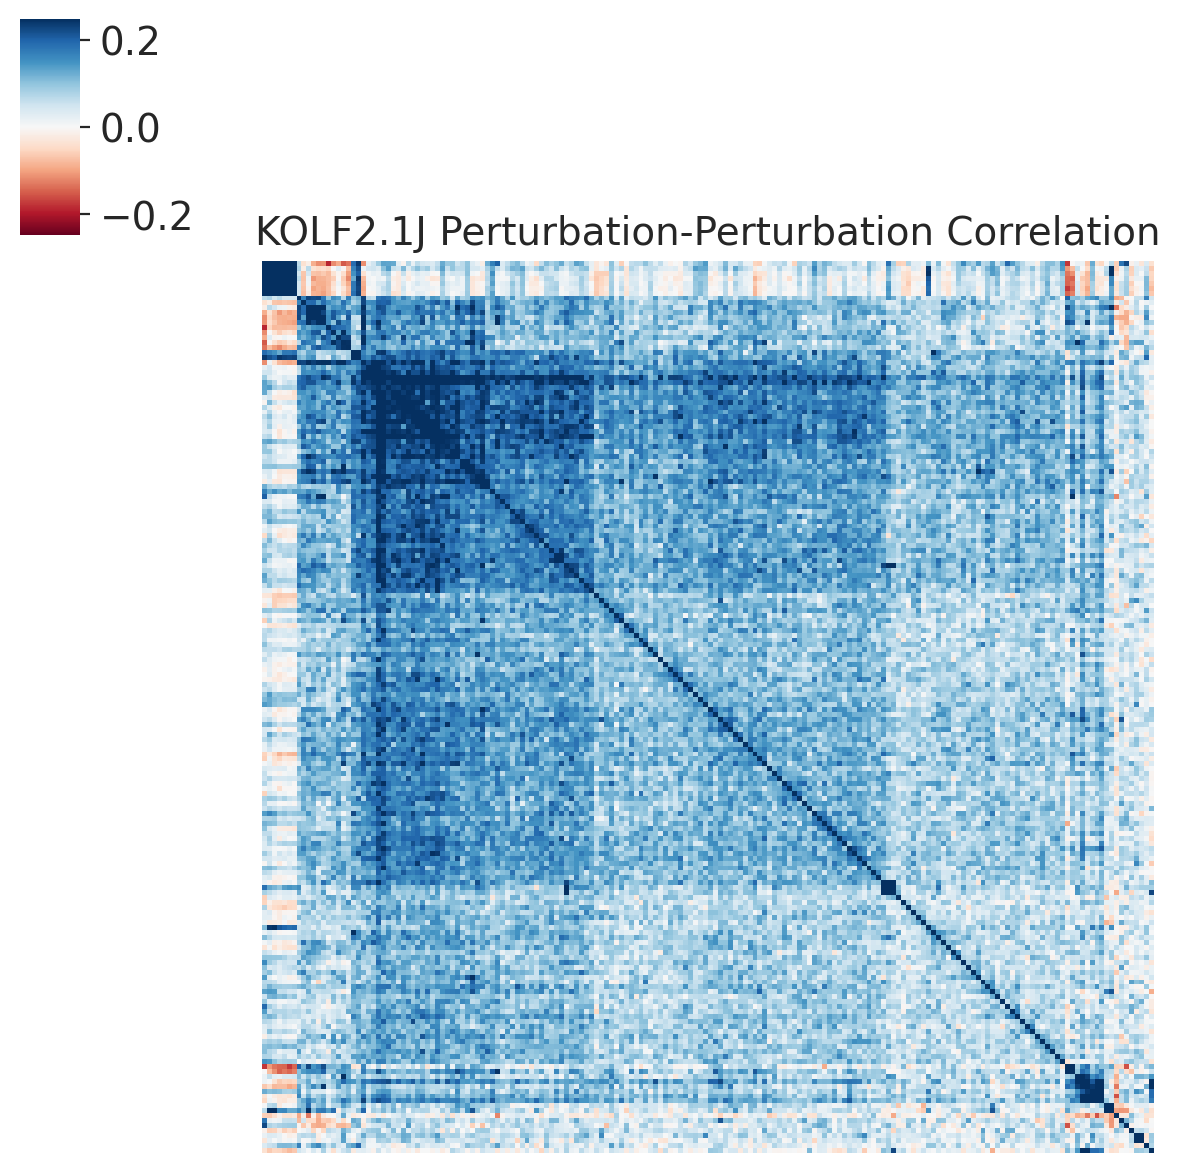

In [18]:
perturb_corr_fig, perturb_corrs, perturb_mean_profiles = \
    create_corrmatrix(adata_mde, mode="perturb", figsize=(6,6), mask_self=True,
                      title="KOLF2.1J Perturbation-Perturbation Correlation")

Computing mean profiles:   0%|          | 0/180 [00:00<?, ?it/s]

Masking expression of 11 gene targets to 0


/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


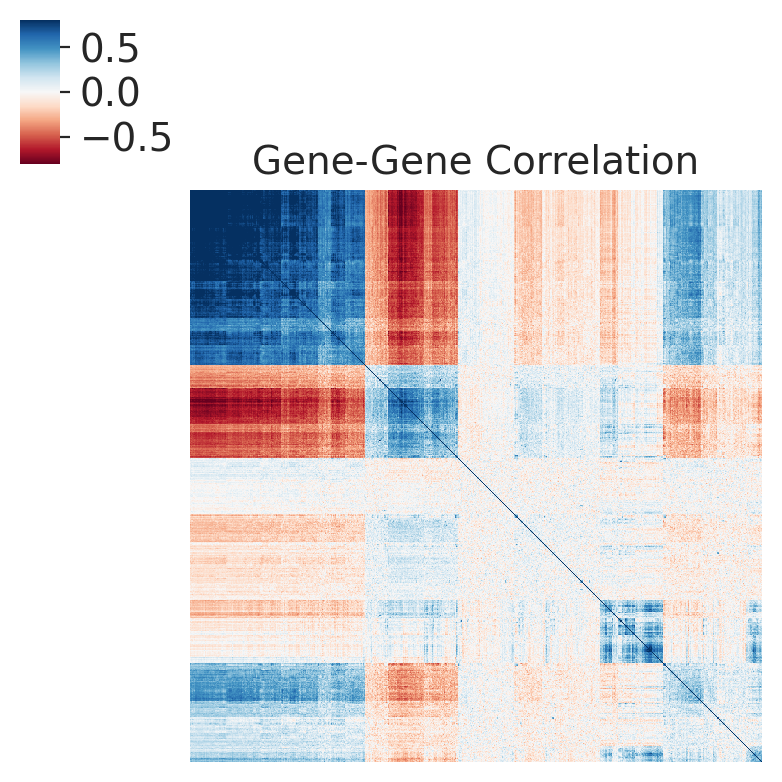

In [20]:
gene_corr_fig, gene_corrs, gene_mean_profiles = \
    create_corrmatrix(adata_mde, mode="gene", figsize=(4,4), mask_self=True,
                      title="Gene-Gene Correlation")

# CORUM complexes

In [19]:
corum_perturb, non_corum_perturb = \
    psp.da.get_corum_perturbation_pairs_from_list(perturb_corrs.columns.unique(), corum_complexes)

3 CORUM complexes present


In [20]:
corum_perturb

[('ESR1', 'SP1'), ('NFKB2', 'SP1'), ('SMAD3', 'SP1')]

In [ ]:
corum_perturb_fig, corum_perturb_u_stat, corum_perturb_p_value = \
    psp.da.benchmark_corum_vs_noncorum_pairs(perturb_corrs, corum_perturb, non_corum_perturb)

In [ ]:
corum_gene, non_corum_gene = \
    psp.da.get_corum_perturbation_pairs_from_list(gene_corrs.columns.unique(), corum_complexes)
corum_gene_fig, corum_gene_u_stat, corum_gene_p_value = \
    psp.da.benchmark_corum_vs_noncorum_pairs(gene_corrs, corum_gene, non_corum_gene)

# HDBSCAN clustering

In [28]:
from sklearn.cluster import HDBSCAN

def compute_HDBSCAN_clusters(correlations, clusterer, pallete_clustered = None, 
                             vmin = None, vmax = None, figsize=(8,8)):
    """
    Version of psp.da.compute_HDBSCAN_clusters() with figsize parameter.
    """
    labels = clusterer.fit_predict(1-correlations)
    labels_series = pd.Series(labels, index=correlations.index)
    # Map each cluster label to a distinct color
    unique_labels = sorted(labels_series.unique())
    palette = sns.color_palette("tab20", n_colors=len(unique_labels))
    lut = dict(zip(unique_labels, palette))
    row_colors = labels_series.map(lut)
    if vmin is None:
        vmin = -np.percentile(abs(correlations.values.flatten()), 98)
    if vmax is None:
        vmax = np.percentile(abs(correlations.values.flatten()), 98)
    # Plot a clustermap of the similarity matrix, annotating clusters with colored bars
    g = sns.clustermap(
        correlations,
        cmap="RdBu",
        vmin=vmin,
        vmax=vmax,
        center=0,
        row_colors=row_colors,
        col_colors=row_colors,
        xticklabels=False,
        yticklabels=False,
        figsize=figsize
    )
    # Build a legend for the cluster colors
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)
    plt.show()
    print(f"HDBSCAN Found {labels_series.max()+1} Clusters")
    clustered_genes = labels_series[labels_series != -1].index
    sim_clustered = correlations.loc[clustered_genes, clustered_genes]
    print(f"Correlation matrix on only genes assigned a HDBScan Cluster: {len(sim_clustered)} total genes")
    labels_clustered = labels_series.loc[clustered_genes]
    unique_labels_clustered = sorted(labels_clustered.unique())
    if pallete_clustered is None:
        palette_clustered = sns.color_palette("Spectral", n_colors=len(unique_labels_clustered))
    else:
        palette_clustered = pallete_clustered
    lut_clustered = dict(zip(unique_labels_clustered, palette_clustered))
    row_colors_clustered = labels_clustered.map(lut_clustered)
    # Plot a clustermap on the clustered subset
    lim = np.percentile(abs(sim_clustered.values.flatten()), 98)
    g2 = sns.clustermap(
        sim_clustered,
        cmap="RdBu",
        vmin=-.5, vmax=.5,
        center=0,
        row_colors=row_colors_clustered,
        col_colors=row_colors_clustered,
        linewidths=0,      # <-- no lines between cells
        linecolor=None,    # <-- explicit "no line" color
        xticklabels=False,
        yticklabels=False,
        figsize=figsize
    )
    # Hide dendrograms for cleaner presentation
    g2.ax_row_dendrogram.set_visible(False)
    g2.ax_col_dendrogram.set_visible(False)
    # Plot the LUT for clustered genes only (excluding noise)
    fig_lut2, ax_lut2 = plt.subplots(figsize=(max(6, len(unique_labels_clustered) * 0.5), 1))
    for idx, label in enumerate(unique_labels_clustered):
        ax_lut2.bar(idx, 1, color=lut_clustered[label], edgecolor='none')
        ax_lut2.text(idx, 1.05, str(label), ha='center', va='bottom', fontsize=10, rotation=90)
    ax_lut2.set_xticks([])
    ax_lut2.set_yticks([])
    # Add some padding to the x-axis limits for better visualization
    padding = 0.5
    ax_lut2.set_xlim(-0.5 - padding, len(unique_labels_clustered) - 0.5 + padding)
    ax_lut2.set_title("Cluster Color LUT")
    plt.tight_layout()
    plt.show()

    return g, g2, labels_series

def compute_HDBSCAN_clusters_20d_embedding(bulks, correlations, clusterer, axis = 1, 
                                           pallete_clustered = None, figsize=(8,8)):
    """
    Version of psp.da.compute_HDBSCAN_clusters_20d_embedding() with figsize parameter.
    """
    dat = psp.da.standardize(bulks, axis = axis)
    import pymde
    pymde.seed(42)
    mde = pymde.preserve_neighbors(dat.values.T, embedding_dim=20, n_neighbors=7,repulsive_fraction=5)
    Y = mde.embed(verbose=True, eps=1e-9, max_iter=1000)
    labels = clusterer.fit_predict(Y)
    labels_series = pd.Series(labels, index=bulks.index)
    # Map each cluster label to a distinct color
    unique_labels = sorted(labels_series.unique())
    palette = sns.color_palette("tab20", n_colors=len(unique_labels))
    lut = dict(zip(unique_labels, palette))
    row_colors = labels_series.map(lut)
    lim = np.percentile(abs(correlations.values.flatten()), 98)
    # Plot a clustermap of the similarity matrix, annotating clusters with colored bars
    g = sns.clustermap(
        correlations,
        cmap="RdBu",
        vmin=-lim,
        vmax=lim,
        center=0,
        row_colors=row_colors,
        col_colors=row_colors,
        xticklabels=False,
        yticklabels=False,
        figsize=figsize
    )
    # Build a legend for the cluster colors
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)
    plt.show()
    print(f"HDBSCAN Found {labels_series.max()+1} Clusters")
    clustered_genes = labels_series[labels_series != -1].index
    sim_clustered = correlations.loc[clustered_genes, clustered_genes]
    print(f"Correlation matrix on only genes assigned a HDBScan Cluster: {len(sim_clustered)} total genes")
    labels_clustered = labels_series.loc[clustered_genes]
    unique_labels_clustered = sorted(labels_clustered.unique())
    palette_clustered = sns.color_palette("tab20", n_colors=len(unique_labels_clustered))
    if pallete_clustered is None:
        palette_clustered = sns.color_palette("hls", n_colors=len(unique_labels_clustered))
    else:
        palette_clustered = pallete_clustered
    lut_clustered = dict(zip(unique_labels_clustered, palette_clustered))
    row_colors_clustered = labels_clustered.map(lut_clustered)
    # Plot a clustermap on the clustered subset
    lim = np.percentile(abs(sim_clustered.values.flatten()), 98)
    g2 = sns.clustermap(
        sim_clustered,
        cmap="RdBu",
        vmin=-.5, vmax=.5,
        center=0,
        row_colors=row_colors_clustered,
        col_colors=row_colors_clustered,
        linewidths=0,      # <-- no lines between cells
        linecolor=None,    # <-- explicit "no line" color   
        xticklabels=False,
        yticklabels=False,
        figsize=figsize
    )
    # Hide dendrograms for cleaner presentation
    g2.ax_row_dendrogram.set_visible(False)
    g2.ax_col_dendrogram.set_visible(False)
     # Plot the LUT for clustered genes only (excluding noise)
    fig_lut2, ax_lut2 = plt.subplots(figsize=(max(6, len(unique_labels_clustered) * 0.5), 1))
    for idx, label in enumerate(unique_labels_clustered):
        ax_lut2.bar(idx, 1, color=lut_clustered[label], edgecolor='none')
        ax_lut2.text(idx, 1.05, str(label), ha='center', va='bottom', fontsize=10, rotation=90)
    ax_lut2.set_xticks([])
    ax_lut2.set_yticks([])
    # Add some padding to the x-axis limits for better visualization
    padding = 0.5
    ax_lut2.set_xlim(-0.5 - padding, len(unique_labels_clustered) - 0.5 + padding)
    ax_lut2.set_title("Cluster Color LUT")
    plt.tight_layout()
    plt.show()
    return g, g2, labels_series

Perturbation clusters

/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


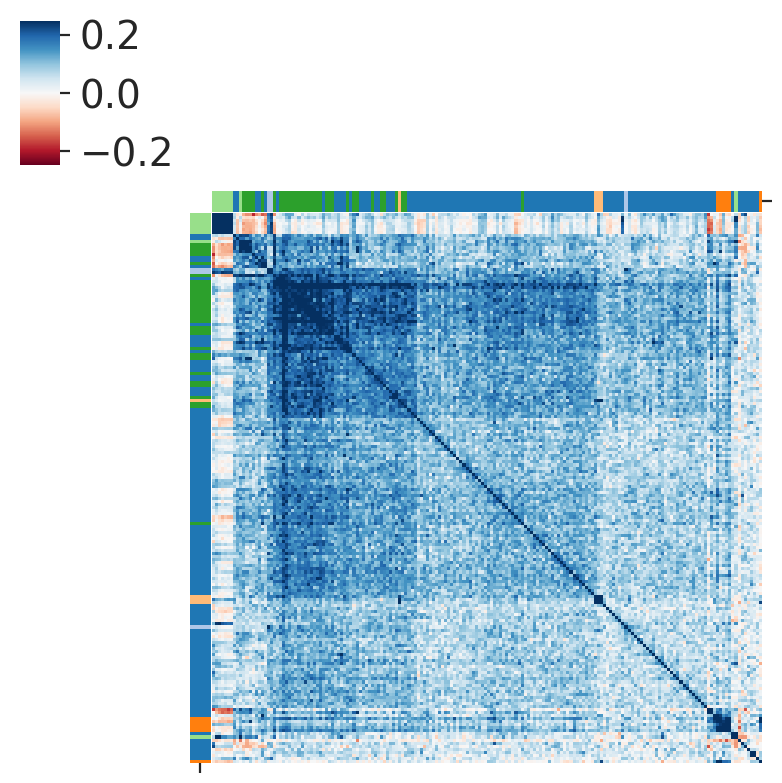

HDBSCAN Found 5 Clusters
Correlation matrix on only genes assigned a HDBScan Cluster: 55 total genes


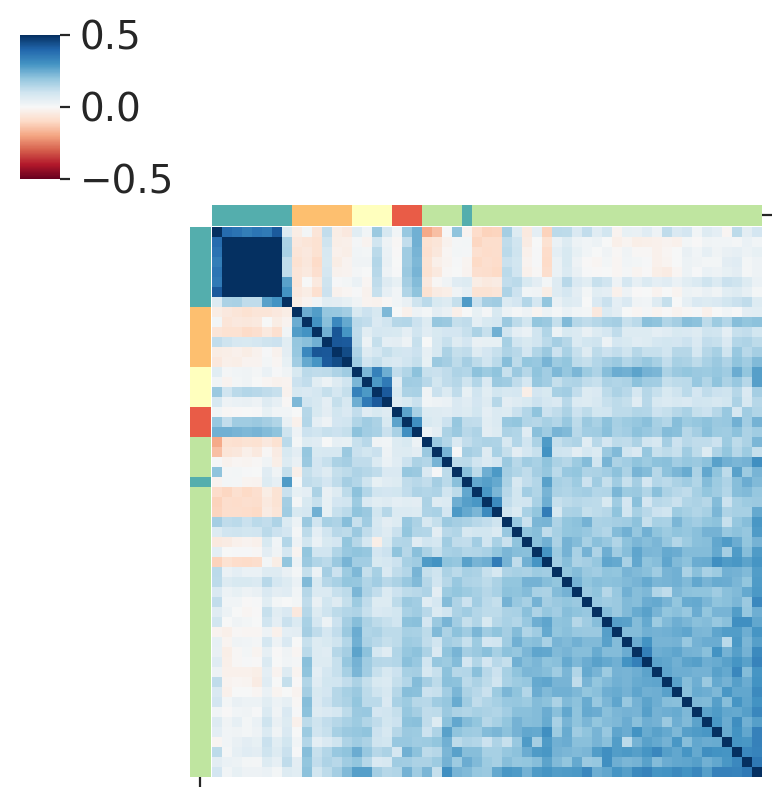

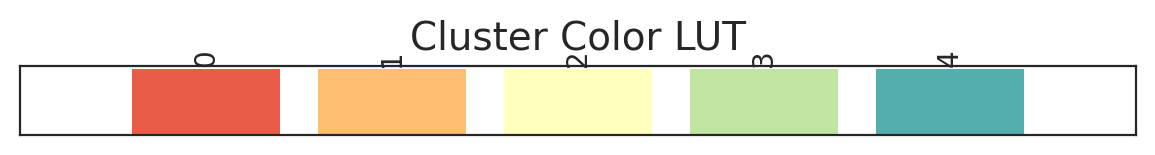

In [40]:
clusterer_perturb_eom = \
    HDBSCAN(metric='precomputed', min_cluster_size=3, cluster_selection_method='eom', min_samples=1)
fig1_eom, fig2_eom, perturbation_HDBSCAN_labels_eom = \
    compute_HDBSCAN_clusters(perturb_corrs, clusterer_perturb_eom, figsize=(4,4))

In [41]:
eom_clusters = pd.DataFrame(
    perturbation_HDBSCAN_labels_eom[perturbation_HDBSCAN_labels_eom != -1].sort_values(),
    columns=["HDBSCAN cluster (eom)"])
eom_clusters.value_counts()

HDBSCAN cluster (eom)
3                        33
4                         9
1                         6
2                         4
0                         3
Name: count, dtype: int64

/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


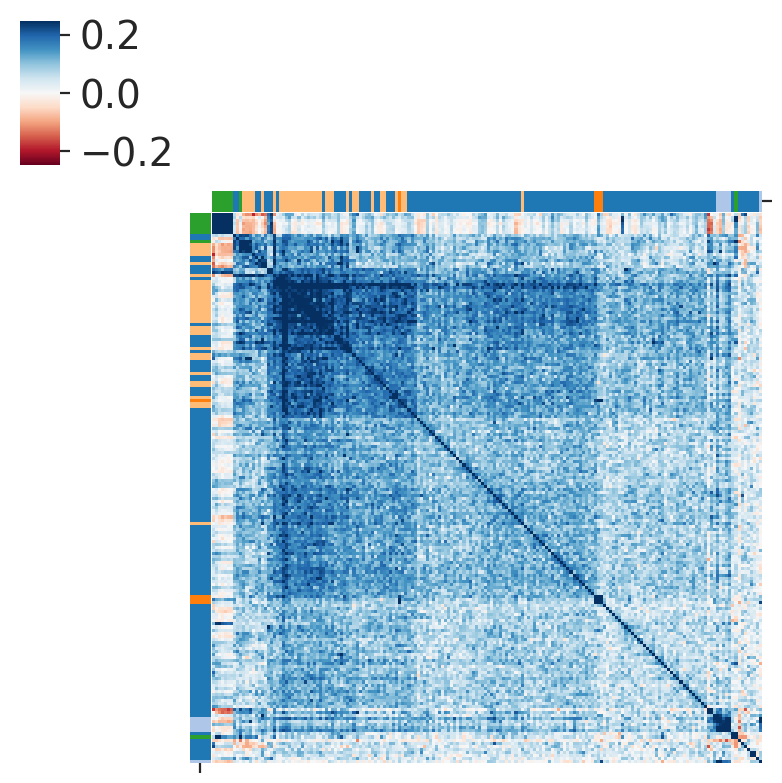

HDBSCAN Found 4 Clusters
Correlation matrix on only genes assigned a HDBScan Cluster: 52 total genes


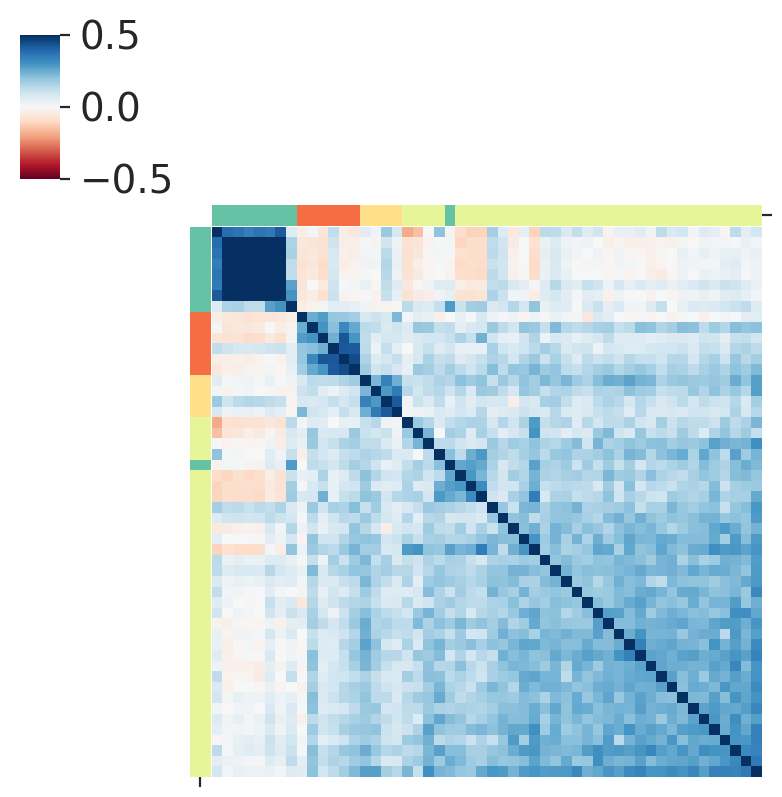

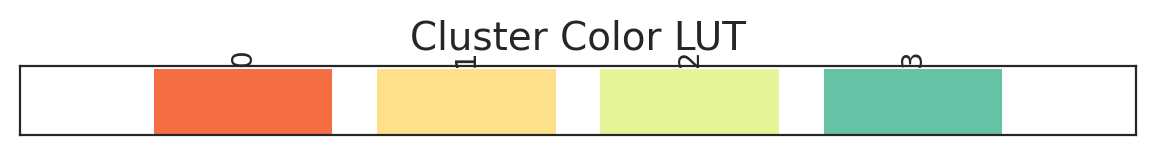

In [52]:
clusterer_perturb_leaf4 = \
    HDBSCAN(metric='precomputed', min_cluster_size=4, cluster_selection_method='leaf', min_samples=1)
fig1_leaf4, fig2_leaf4, perturbation_HDBSCAN_labels_leaf4 = \
    compute_HDBSCAN_clusters(perturb_corrs, clusterer_perturb_leaf4, figsize=(4,4))

In [53]:
leaf_clusters4 = pd.DataFrame(
    perturbation_HDBSCAN_labels_leaf4[perturbation_HDBSCAN_labels_leaf4 != -1].sort_values(),
    columns=["HDBSCAN cluster (leaf, min cluster size 4)"])
leaf_clusters4.value_counts()

HDBSCAN cluster (leaf, min cluster size 4)
2                                             33
3                                              9
0                                              6
1                                              4
Name: count, dtype: int64

In [54]:
for cl in leaf_clusters4["HDBSCAN cluster (leaf, min cluster size 4)"].unique():
    print(f"Cluster {cl}: "
          f"{', '.join(leaf_clusters4[leaf_clusters4['HDBSCAN cluster (leaf, min cluster size 4)'] == cl].index)}")

Cluster 0: ADNP2, CHAMP1, DNMT1, PITX3, SETDB1, VDR
Cluster 1: GTF2IRD1, EBF2, ZNF420, ZNF695
Cluster 2: ESRRG, FOXH1, NFE2L2, ARNT2, IRF9, IRX5, TBX19, NR5A1, NFKB2, PHF1, SETDB2, SIX6, POU4F3, SOX4, TIGD7, SOX11, ZNF205, ZNF24, ZFP1, ZBTB34, CREB3L3, ARID2, ZSCAN23, ZNF623, ZNF462, ZNF426, ZNF732, ZSCAN18, ZFP37, ZFP41, ZNF658, ZNF787, ZNF829
Cluster 3: POU5F1, RBPJ, NANOG, POU5F1B, PHF20, POU3F2, ZNF521, ZNF219, ZNF396


/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


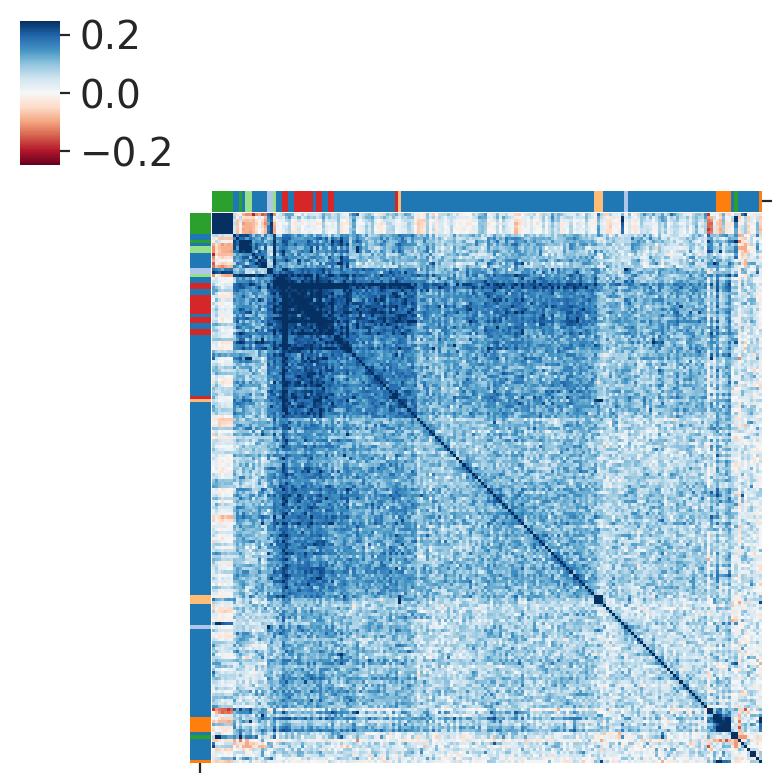

HDBSCAN Found 6 Clusters
Correlation matrix on only genes assigned a HDBScan Cluster: 38 total genes


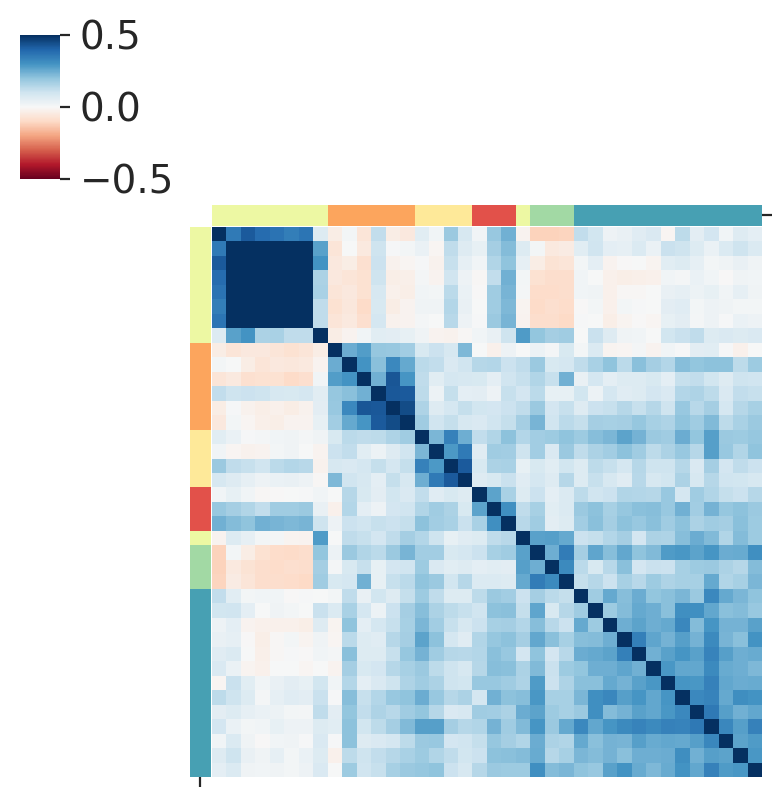

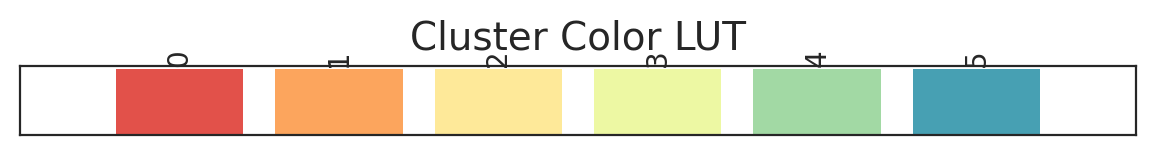

In [29]:
clusterer_perturb_leaf3 = \
    HDBSCAN(metric='precomputed', min_cluster_size=3, cluster_selection_method='leaf', min_samples=1)
fig1_leaf3, fig2_leaf3, perturbation_HDBSCAN_labels_leaf3 = \
    compute_HDBSCAN_clusters(perturb_corrs, clusterer_perturb_leaf3, figsize=(4,4))

In [30]:
leaf_clusters3 = pd.DataFrame(
    perturbation_HDBSCAN_labels_leaf3[perturbation_HDBSCAN_labels_leaf3 != -1].sort_values(),
    columns=["HDBSCAN cluster (leaf, min cluster size 3)"])
leaf_clusters3.value_counts()

HDBSCAN cluster (leaf, min cluster size 3)
5                                             13
3                                              9
1                                              6
2                                              4
0                                              3
4                                              3
Name: count, dtype: int64

In [57]:
for cl in leaf_clusters3["HDBSCAN cluster (leaf, min cluster size 3)"].unique():
    print(f"Cluster {cl}: "
          f"{', '.join(leaf_clusters3[leaf_clusters3['HDBSCAN cluster (leaf, min cluster size 3)'] == cl].index)}")

Cluster 0: CBX2, PKNOX2, PCGF2
Cluster 1: ADNP2, CHAMP1, PITX3, DNMT1, VDR, SETDB1
Cluster 2: ZNF420, EBF2, GTF2IRD1, ZNF695
Cluster 3: POU3F2, PHF20, NANOG, ZNF396, POU5F1B, ZNF219, POU5F1, ZNF521, RBPJ
Cluster 4: ZNF205, SOX4, ZNF787
Cluster 5: IRX5, NFKB2, SIX6, ZNF24, IRF9, ARNT2, ESRRG, ZNF426, ZFP37, ZFP41, ZNF623, ZNF732, ZSCAN23


In [31]:
perturbation_HDBSCAN_labels = perturbation_HDBSCAN_labels_leaf3

In [32]:
bulks_mde = psp.da.bulk_by_gene_target_mean(adata_mde)

Gene clusters

In [ ]:
clusterer_gene = \
    HDBSCAN(metric='euclidean', min_cluster_size=10, cluster_selection_method='leaf', min_samples=1)
fig1, fig2, gene_HDBSCAN_labels = \
    compute_HDBSCAN_clusters_20d_embedding(bulks_mde, gene_corrs, clusterer_gene, figsize=(6,6))

# Minimum Distortion Embedding

## MDE functions

In [21]:
# Generate embeddings

from sklearn.manifold import SpectralEmbedding
import pymde
import leidenalg
import igraph as ig
from sklearn.neighbors import kneighbors_graph

def embed_spectral_mde(mp_standardized, 
                       n_components: int=20,
                       spectral_n_neighbors: int=25,
                       mde_n_neighbors: int=7, 
                       repulsive_fraction: float=5,
                       random_state: int=42):
    """
    Function from psp KOLF_Perturbation_Atlas_Data_Analysis.ipynb 
    example notebook. Modified to take spectral_n_neighbors as arg.
    """
    embedder = SpectralEmbedding(
        n_components=n_components,
        n_neighbors=spectral_n_neighbors,
        affinity='nearest_neighbors',
        eigen_solver='arpack',
        random_state=random_state,
    )
    X = embedder.fit_transform(mp_standardized)
    pymde.seed(random_state)
    mde = pymde.preserve_neighbors(X, embedding_dim=2, 
                                   n_neighbors=mde_n_neighbors,
                                   repulsive_fraction=repulsive_fraction)
    Y = mde.embed(verbose=True, eps=1e-9, max_iter=2000)
    return Y

def build_mde_df(Y, bulk_df, perturbation_HDBSCAN_labels, n_neighbors=6, seed=12):
    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    hdbscan_map = dict(perturbation_HDBSCAN_labels)
    embedding_df['hdbscan cluster'] = embedding_df['gene_target'].map(hdbscan_map)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )
    return embedding_df

In [22]:
# Choosing k for KNN graph (cluster agreement, silhouette scores)

import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score
import igraph as ig
import leidenalg
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import silhouette_score

def plot_cluster_agreement(Y, perturbation_HDBSCAN_labels, title):
    """
    Version of psp.da.plot_cluster_agreement() that returns
    DataFrame of ARI and AMI results.
    """
    # Make everything deterministic
    seed = 42
    random.seed(seed)
    np.random.seed(seed)

    sns.set(style="whitegrid", font_scale=1.2)

    # Define neighbor sizes to test
    neighbor_sizes = list(range(2, 20))

    # Restrict to points assigned by HDBSCAN
    mask = perturbation_HDBSCAN_labels >= 0
    hdb_labels = perturbation_HDBSCAN_labels[mask].values

    # Evaluate clustering agreement for each neighbor size
    ari_scores = []
    ami_scores = []
    for k in neighbor_sizes:
        knn_graph = kneighbors_graph(Y, n_neighbors=k, include_self=False)
        sources, targets = knn_graph.nonzero()
        g = ig.Graph(directed=False)
        g.add_vertices(Y.shape[0])
        g.add_edges(list(zip(sources, targets)))
        # Leiden clustering with fixed seed
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            seed=seed
        )
        leiden_labels = np.array(partition.membership)
        # Compute metrics
        ari_scores.append(adjusted_rand_score(hdb_labels, leiden_labels[mask]))
        ami_scores.append(adjusted_mutual_info_score(hdb_labels, leiden_labels[mask]))

    # Plot results
    plt.figure(figsize=(6,4))
    plt.plot(neighbor_sizes, ari_scores, marker='o', linestyle='-', color='C0', label='ARI')
    plt.plot(neighbor_sizes, ami_scores, marker='s', linestyle='--', color='C1', label='AMI')
    plt.xlabel('Number of Leiden Neighbors (k)')
    plt.ylabel('Adjusted score')
    if title:
        plt.title(title)
    else:
        plt.title('Clustering agreement vs. k (Leiden vs. HDBSCAN)')
    plt.xticks(neighbor_sizes)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Create DataFrame
    score_df = pd.DataFrame({"ARI": ari_scores, "AMI": ami_scores},
                            index=neighbor_sizes)
    return score_df

def plot_silhouette_scores(Y, title):
    """
    Plot silhouette score of MDE Leiden clustering
    for each specified number of neighbors for KNN graph.
    """
    seed=12
    sns.set(style="whitegrid", font_scale=1.2)

    # Define neighbor sizes to test
    neighbor_sizes = list(range(2, 20))

    # Evaluate clustering agreement for each neighbor size
    s_scores = []
    for k in neighbor_sizes:
        knn_graph = kneighbors_graph(Y, n_neighbors=k, include_self=False)
        sources, targets = knn_graph.nonzero()
        g = ig.Graph(directed=False)
        g.add_vertices(Y.shape[0])
        g.add_edges(list(zip(sources, targets)))
        # Leiden clustering with fixed seed
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            seed=seed
        )
        leiden_labels = np.array(partition.membership)
        # Compute metrics
        s_scores.append(silhouette_score(Y, labels=leiden_labels, random_state=seed))

    # Plot results
    plt.figure(figsize=(6,4))
    plt.plot(neighbor_sizes, s_scores, marker='o', linestyle='-', color='tab:red')
    plt.xlabel('Number of Leiden Neighbors (k)')
    plt.ylabel('Silhouette score')
    if title:
        plt.title(title)
    else:
        plt.title('Silhouette score vs. k')
    plt.xticks(neighbor_sizes)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # Create DataFrame
    score_df = pd.DataFrame({"Silhouette score": s_scores},
                            index=neighbor_sizes)
    return score_df

In [23]:
# Plots
from sklearn.neighbors import kneighbors_graph
import igraph as ig 
import plotly.express as px 
import leidenalg 
from scipy.spatial.distance import pdist, squareform

# Pairwise dist mtx of Leiden cluster centroids
def plot_pairwise_distance_matrix(Y, bulk_df, n_neighbors = 6, seed = 12,
                                  figsize=(6,6), tick_fontsize = 10, title_fontsize=14,
                                  title_y_position=1.02,
                                  title="Pairwise Distance Matrix of Leiden Cluster Centroids"):
    # KNN graph and Leiden clustering
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # Pairwise distance matrix of cluster centroids
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target'] = bulk_df.columns
    embedding_df['cluster'] = leiden_labels
    embedding_df['cluster'] = embedding_df['cluster'].astype(str)
    cluster_groups = embedding_df.groupby('cluster')
    centroids = cluster_groups[['x', 'y']].mean()
    pairwise_distances = pd.DataFrame(
        squareform(pdist(centroids, metric='euclidean')),
        index=centroids.index,
        columns=centroids.index
    )
    sns.set_style("white")
    ax = sns.clustermap(pairwise_distances, cmap='PuBuGn', figsize=figsize,
                        xticklabels=True, yticklabels=True)
    ax.ax_heatmap.tick_params(right=True, bottom=True, labelsize=tick_fontsize)
    ax.fig.suptitle(title, fontsize=title_fontsize, y=title_y_position)
    plt.show()

# MDE plots
def plot_mde_interactive(Y, bulk_df, perturbation_HDBSCAN_labels,
                         n_neighbors=6, seed=12, save_dir_stem=None,
                         marker_size = 7, marker_opacity = 0.7,
                         color_sequence = "Dark24", 
                         title = 'Minimum Distortion Embedding of Mean Normalized Profiles'):
    """
    Plot MDE (interactive version using plotly) with the specified color sequence 
    (Dark24, Bold, Prism, or Vivid). Modified from psp.da.plot_mde().
    """
    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    hdbscan_map = dict(perturbation_HDBSCAN_labels)
    embedding_df['hdbscan cluster'] = embedding_df['gene_target'].map(hdbscan_map)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )

    # --- 3) Interactive Plotly scatter ---
    if color_sequence.lower() == "dark24":
        color_discrete_sequence=px.colors.qualitative.Dark24
    elif color_sequence.lower() == "bold":
        color_discrete_sequence=px.colors.qualitative.Bold
    elif color_sequence.lower() == "prism":
        color_discrete_sequence=px.colors.qualitative.Prism
    elif color_sequence.lower() == "vivid":
        color_discrete_sequence=px.colors.qualitative.Vivid 
    fig = px.scatter(
        embedding_df,
        x='x', y='y',
        text='gene_target',
        color='leiden cluster',
        category_orders={'leiden cluster': leiden_cats},
        hover_data=['x', 'y', 'gene_target', 'hdbscan cluster'],
        title=title,
        color_discrete_sequence=color_discrete_sequence
    )
    fig.update_traces(
        marker=dict(size=marker_size, opacity=marker_opacity),
        textposition='middle center',
        textfont=dict(size=1)
    )
    fig.update_layout(
        showlegend=True,
        legend=dict(traceorder='normal'),
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        plot_bgcolor='white',
        width=1200,
        height=1000,
        legend_title_text='Leiden Cluster',
        coloraxis_showscale=False
    )

    import plotly.io as pio #type: ignore
    if save_dir_stem is not None:
        pio.write_html(fig, file=save_dir_stem+"_MDE.html", include_plotlyjs="inline",full_html=True)
        embedding_df.to_excel(save_dir_stem+"_MDE_clusters.xlsx", index=False)
    fig.show()
    return embedding_df

def plot_mde_static(Y, bulk_df, n_neighbors = 6, seed = 12, save_dir_stem = None,
                    figsize=(8,6), legend_ncol = 1, title_fontsize=14,
                    title = 'Minimum Distortion Embedding of Mean Normalized Profiles'):
    """
    Plot MDE (static version using matplotlib). Modified from psp.da.plot_mde().
    """
    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )

    # convert Plotly Dark24 colors to matplotlib-friendly RGB tuples
    plotly_color_list = px.colors.qualitative.Dark24
    leiden_colors = [px.colors.unconvert_from_RGB_255(px.colors.hex_to_rgb(c)) 
                    for c in plotly_color_list]
    leiden_colors = [leiden_colors[i % len(leiden_colors)] for i in range(len(leiden_cats))]

    # seaborn clean style
    sns.set_style('white')
    sns.set_style({'axes.grid': False})

    # --- 4) Static 1×4 Matplotlib figure ---
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Panel 1: Leiden clusters
    for i, lc in enumerate(leiden_cats):
        sel = embedding_df['leiden cluster'] == lc
        ax.scatter(
            embedding_df.loc[sel, 'x'],
            embedding_df.loc[sel, 'y'],
            color=leiden_colors[i],
            s=13,
            alpha=0.8,
            edgecolor='white',
            linewidth=0.3,
            zorder=2,
            label=f"{lc}"
        )
    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

    ax.legend(
        bbox_to_anchor=(0.95, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=False,
        title='Leiden Cluster',
        fontsize=10,
        ncol=legend_ncol
    )

    plt.tight_layout()
    plt.show()
    if save_dir_stem is not None:
        fig.savefig(save_dir_stem + "_MDE_views.svg", format='svg', bbox_inches='tight')

def plot_mde_leiden_hdbscan(Y, perturbation_HDBSCAN_labels, bulk_df, n_neighbors = 6, 
                            seed = 12, save_dir_stem = None, legend_ncol=1,
                            suptitle="Minimum Distortion Embedding Leiden and HDBSCAN Clusters",
                            suptitle_fontsize=14):
    """
    Generate 2-panel figure where panel 1 is MDE and panel 2 is
    overlay of HDBSCAN clusters over MDE.
    """
    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    hdbscan_map = dict(perturbation_HDBSCAN_labels)
    embedding_df['hdbscan cluster'] = embedding_df['gene_target'].map(hdbscan_map)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )

    # convert Plotly Dark24 colors to matplotlib-friendly RGB tuples
    plotly_color_list = px.colors.qualitative.Dark24
    leiden_colors = [px.colors.unconvert_from_RGB_255(px.colors.hex_to_rgb(c)) 
                    for c in plotly_color_list]
    leiden_colors = [leiden_colors[i % len(leiden_colors)] for i in range(len(leiden_cats))]

    # HDBSCAN palette (exclude noise = -1)
    hdb          = embedding_df['hdbscan cluster']
    hdb_clusters = sorted(c for c in hdb.unique() if c != -1)
    hdb_palette  = sns.color_palette('tab10', len(hdb_clusters))

    # seaborn clean style
    sns.set_style('white')
    sns.set_style({'axes.grid': False})


    # --- 4) Static 1×4 Matplotlib figure ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

    # Panel 1: Leiden clusters
    ax = axes[0]
    for i, lc in enumerate(leiden_cats):
        sel = embedding_df['leiden cluster'] == lc
        ax.scatter(
            embedding_df.loc[sel, 'x'],
            embedding_df.loc[sel, 'y'],
            color=leiden_colors[i],
            s=13,
            alpha=0.8,
            edgecolor='white',
            linewidth=0.3,
            zorder=2,
            label=f"{lc}"
        )
    ax.set_title('Leiden clusters')
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

    ax.legend(
        bbox_to_anchor=(0.95, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=False,
        title='Leiden Cluster',
        fontsize=10,
        ncol=legend_ncol
    )

    # Panel 2: HDBSCAN clusters (with legend)
    ax = axes[1]

    # Noise points (-1)
    ax.scatter(
        embedding_df.loc[hdb == -1, 'x'],
        embedding_df.loc[hdb == -1, 'y'],
        color='lightgray',
        edgecolor='white',
        s=13,
        alpha=0.5,
        zorder=1,
        # label='Noise (-1)'
    )

    # Actual HDBSCAN clusters
    for i, hc in enumerate(hdb_clusters):
        sel = (hdb == hc)
        ax.scatter(
            embedding_df.loc[sel, 'x'],
            embedding_df.loc[sel, 'y'],
            color=hdb_palette[i],
            s=14,
            alpha=0.8,
            edgecolor='white',
            linewidth=0.3,
            zorder=2,
            label=f'{hc}'
        )

    ax.set_title('HDBSCAN clusters')
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

    ax.legend(
        bbox_to_anchor=(0.85, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=False,
        title='HDBSCAN Cluster',
        fontsize=10
    )
    
    if suptitle:
        plt.suptitle(suptitle, fontsize=suptitle_fontsize)
    plt.tight_layout()
    plt.show()
    if save_dir_stem is not None:
        fig.savefig(save_dir_stem + "_MDE_views.svg", format='svg', bbox_inches='tight')
    return embedding_df

def plot_mde_leiden_corum(Y, bulk_df, corum_complexes = None, n_neighbors = 6, 
                        seed = 12, save_dir_stem = None, legend_ncol=1,
                        suptitle="Minimum Distortion Embedding Leiden Clusters and CORUM Complexes",
                        suptitle_fontsize=14):
    """
    Generate 2-panel figure where panel 1 is MDE and panel 2 is
    overlay of CORUM complexes over MDE.
    """
    corum, _ = psp.da.get_corum_perturbation_pairs_from_list(bulk_df.columns.unique(), corum_complexes)

    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )

    # convert Plotly Dark24 colors to matplotlib-friendly RGB tuples
    plotly_color_list = px.colors.qualitative.Dark24
    leiden_colors = [px.colors.unconvert_from_RGB_255(px.colors.hex_to_rgb(c)) 
                    for c in plotly_color_list]
    leiden_colors = [leiden_colors[i % len(leiden_colors)] for i in range(len(leiden_cats))]

    # CORUM
    corum_genes = {g for pair in corum for g in pair}
    is_in_corum  = embedding_df['gene_target'].isin(corum_genes)
    coords       = embedding_df.set_index('gene_target')[['x','y']]

    # seaborn clean style
    sns.set_style('white')
    sns.set_style({'axes.grid': False})


    # --- 4) Static 1×4 Matplotlib figure ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

    # Panel 1: Leiden clusters
    ax = axes[0]
    for i, lc in enumerate(leiden_cats):
        sel = embedding_df['leiden cluster'] == lc
        ax.scatter(
            embedding_df.loc[sel, 'x'],
            embedding_df.loc[sel, 'y'],
            color=leiden_colors[i],
            s=13,
            alpha=0.8,
            edgecolor='white',
            linewidth=0.3,
            zorder=2,
            label=f"{lc}"
        )
    ax.set_title('Leiden clusters')
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

    ax.legend(
        bbox_to_anchor=(0.95, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=False,
        title='Leiden Cluster',
        fontsize=10,
        ncol=legend_ncol
    )

    # Panel 2: CORUM membership (solid dark‑blue dots)
    ax = axes[1]
    # draw CORUM lines behind
    for g1, g2 in corum:
        if g1 in coords.index and g2 in coords.index:
            x1, y1 = coords.loc[g1]
            x2, y2 = coords.loc[g2]
            ax.plot(
                [x1, x2], [y1, y2],
                color='darkblue', linewidth=0.5, alpha=0.2, zorder=1,
            )
    # non‑CORUM points
    ax.scatter(
        embedding_df.loc[~is_in_corum, 'x'],
        embedding_df.loc[~is_in_corum, 'y'],
        color='lightgray', s=10, alpha=0.3, zorder=2,
        label='Non CORUM'
    )
    # CORUM points (solid dark blue)
    ax.scatter(
        embedding_df.loc[ is_in_corum, 'x'],
        embedding_df.loc[ is_in_corum, 'y'],
        color='darkblue', s=10, alpha=0.8, zorder=3,
        label='CORUM Pairs'
    )
    ax.set_title('CORUM membership')
    ax.legend(loc='lower left', frameon=False)
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)
    
    if suptitle:
        plt.suptitle(suptitle, fontsize=suptitle_fontsize)
    plt.tight_layout()
    plt.show()
    if save_dir_stem is not None:
        fig.savefig(save_dir_stem + "_MDE_views.svg", format='svg', bbox_inches='tight')
    return embedding_df

In [24]:
# Get + plot gene targets per cluster

def gene_targets_per_hdbscan_cluster(hdbscan_labels: pd.Series) -> pd.DataFrame:
    """
    Return DataFrame where each column contains the perturbations in a
    HDBSCAN cluster.
    """
    cluster_nums = sorted(list({n for n in hdbscan_labels.values if n != -1}))
    cluster_dict = dict()
    for n in cluster_nums:
        cluster_dict[n] = hdbscan_labels[hdbscan_labels == n].index.tolist()

    # Pad all columns to be the same length
    max_n_perts = max(len(cluster_dict[i]) for i in range(len(cluster_dict)))
    cluster_dict = {cluster:(perts + [np.nan]*(max_n_perts-len(perts))) 
                    for cluster, perts in cluster_dict.items()}
    perts_in_cluster_df = pd.DataFrame(cluster_dict)
    return perts_in_cluster_df

def gene_targets_per_cluster(embedding_df: pd.DataFrame,
                             cluster_col: str="leiden cluster") -> pd.DataFrame:
    """
    Return DataFrame where each column contains the perturbations in a cluster.
    """
    if cluster_col not in embedding_df.columns:
        raise ValueError("Cluster column not found in embedding DataFrame")
    cluster_num_type = type(embedding_df[cluster_col].values[0])
    
    # Get cluster numbers
    cluster_nums = {int(n) for n in embedding_df[cluster_col].values}
    cluster_nums = list(sorted(cluster_nums))
    # Remove HDBSCAN cluster -1 (outliers)
    if -1 in cluster_nums:
        cluster_nums.remove(-1)

    # Get gene targets per cluster
    cluster_dict = dict()
    for n in cluster_nums:
        if cluster_num_type == str:
            cluster = embedding_df[embedding_df[cluster_col] == str(n)]["gene_target"].tolist()
        else:
            cluster = embedding_df[embedding_df[cluster_col] == n]["gene_target"].tolist()
        cluster_dict[n] = cluster

    # Pad all columns to be the same length
    max_n_perts = max(len(cluster_dict[i]) for i in range(len(cluster_dict)))
    cluster_dict = {cluster:(perts + [np.nan]*(max_n_perts-len(perts))) 
                    for cluster, perts in cluster_dict.items()}
    perts_in_cluster_df = pd.DataFrame(cluster_dict)
    return perts_in_cluster_df

def plot_n_perts_per_cluster(perts_in_cluster_df: pd.DataFrame, 
                             title: str, 
                             figsize: tuple[int, int] = (6,3), 
                             xlabel: str="Cluster", 
                             ymax: int | None = None,
                             color: str = "tab:blue"):
    """
    Plot number of perturbations per cluster.
    """
    sns.set_style("whitegrid")
    n_perts_per_cluster = perts_in_cluster_df.count().tolist()
    print(n_perts_per_cluster)
    xvals = [i for i in range(len(n_perts_per_cluster))]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=xvals, y=n_perts_per_cluster, ax=ax,
                color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# TF KDs in cluster")
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

In [25]:
# Find KDs or CORUM complexes in clusters

def find_kds_in_leiden_hdbscan_clusters(kd_list: list[str],
                                        leiden_clusters_df: pd.DataFrame,
                                        hdbscan_clusters_df: pd.DataFrame,
                                        sort_by: str="leiden",
                                        nan_as_whitespace: bool=True) -> pd.DataFrame:
    """
    Build DF of each KD in the list and what Leiden and HDBSCAN clusters that
    KD is in.
    """
    kd_list = [kd for kd in kd_list if not isinstance(kd, float)]
    leiden_cluster_res, hdbscan_cluster_res = list(), list()
    results = [leiden_cluster_res, hdbscan_cluster_res]
    dfs = [leiden_clusters_df, hdbscan_clusters_df]
    for kd in kd_list:
        for df, res in zip(dfs, results):
            clusters_with_kd = list(df.columns[df.eq(kd).any()])
            kd_cluster = np.nan if clusters_with_kd == [] else int(clusters_with_kd[0])
            res.append(kd_cluster)
    kds_clusters_df = pd.DataFrame({"Leiden cluster": leiden_cluster_res,
                                    "HDBSCAN cluster": hdbscan_cluster_res},
                                    index=kd_list)
    if nan_as_whitespace:
        kds_clusters_df.fillna("", inplace=True)
    kds_clusters_df = kds_clusters_df.convert_dtypes(convert_string=False)
    if sort_by.lower() == "leiden":
        kds_clusters_df.sort_values(by=["Leiden cluster", "HDBSCAN cluster"],
                                    na_position="last", inplace=True)
    elif sort_by.lower() == "hdbscan":
        kds_clusters_df.sort_values(by=["HDBSCAN cluster", "Leiden cluster"], 
                                    na_position="last", inplace=True)
    return kds_clusters_df

def find_kds_in_clusters(kd_list: list[str], 
                         clusters_df: pd.DataFrame,
                         cluster_col: str="Cluster",
                         sort: bool=True) -> pd.DataFrame:
    """
    Build DF of each KD in the list and what cluster it is in.
    """
    cluster_results = list()
    kd_list = [kd for kd in kd_list if isinstance(kd, str)]
    for kd in kd_list:
        cols_with_kd = list(clusters_df.columns[clusters_df.eq(kd).any()])
        kd_cluster = np.nan if cols_with_kd == [] else int(cols_with_kd[0])
        cluster_results.append(kd_cluster)
    kds_clusters_df = pd.DataFrame(cluster_results, index=kd_list, columns=[cluster_col])
    kds_clusters_df[cluster_col] = kds_clusters_df[cluster_col].astype('Int64')
    if sort:
        kds_clusters_df.sort_values(by=cluster_col, na_position="last", inplace=True)
    return kds_clusters_df

def find_corum_complexes_in_clusters(corum_complexes_perturb: list[tuple[str, str]],
                                     cluster_kds_df: pd.DataFrame,
                                     cluster_type: str="Leiden"):
    df_cl_nums, df_complexes = list(), list()
    for complex in corum_complexes_perturb:
        protein1, protein2 = complex
        if protein1 in cluster_kds_df.values:
            protein1_cl = cluster_kds_df.columns[cluster_kds_df.eq(protein1).any()][0]
        else:
            protein1_cl = None
        if protein2 in cluster_kds_df.values:
            protein2_cl = cluster_kds_df.columns[cluster_kds_df.eq(protein2).any()][0]
        else:
            protein2_cl = None
        if protein1_cl is None or protein2_cl is None:
            continue
        if protein1_cl == protein2_cl:
            df_cl_nums.append(protein1_cl)
            df_complexes.append(f"{protein1}-{protein2}")
    corum_df = pd.DataFrame({f"{cluster_type} cluster": df_cl_nums,
                             "CORUM complex": df_complexes})
    return corum_df

In [26]:
def build_cluster_DEGs_dict(DEGs_dict: dict[str, set[str]],
                            cluster_df: pd.DataFrame
                            ) -> dict[int, set[str]]:
    """
    Build dict of DEGs per cluster.
    """
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_DEGs_dict = {
        cl: set().union(*[DEGs_dict[kd] for kd in cluster_kd_dict[cl]])
        for cl in cluster_kd_dict
    }
    return cluster_DEGs_dict

def build_n_DEGs_per_cluster_df(cluster_DEGs_dict: dict[int, set[str]]):
    clusters = list(cluster_DEGs_dict.keys())
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in cluster_DEGs_dict]
    n_DEGs_per_cluster_df = pd.DataFrame({"n_DEGs": n_DEGs}, index=clusters)
    n_DEGs_per_cluster_df.index.name = "Cluster"
    return n_DEGs_per_cluster_df

def plot_n_DEGs_per_cluster(cluster_DEGs_dict: dict[int, set[str]],
                            title: str, 
                            figsize: tuple[int, int] = (6,3), 
                            xlabel: str="Cluster", 
                            ymax: int | None = None,
                            color: str = "tab:blue"):
    """
    Given a dict of DEGs per cluster, plot number of DEGs per cluster.
    """
    clusters = sorted(list(cluster_DEGs_dict.keys()))
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in clusters]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=clusters, y=n_DEGs, ax=ax, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# DEGs per cluster")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10, rotation=90)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

## HDBSCAN clusters

In [33]:
hdbscan_cluster_kds = gene_targets_per_hdbscan_cluster(perturbation_HDBSCAN_labels)
hdbscan_cluster_kds

,0,1,2,3,4,5
0,CBX2,ADNP2,EBF2,NANOG,SOX4,ARNT2
1,PCGF2,CHAMP1,GTF2IRD1,PHF20,ZNF205,ESRRG
2,PKNOX2,DNMT1,ZNF420,POU3F2,ZNF787,IRF9
3,NaN,PITX3,ZNF695,POU5F1,NaN,IRX5
4,NaN,SETDB1,NaN,POU5F1B,NaN,NFKB2
5,NaN,VDR,NaN,RBPJ,NaN,SIX6
6,NaN,NaN,NaN,ZNF219,NaN,ZFP37
7,NaN,NaN,NaN,ZNF396,NaN,ZFP41
8,NaN,NaN,NaN,ZNF521,NaN,ZNF24
9,NaN,NaN,NaN,NaN,NaN,ZNF426


In [66]:
hdbscan_filepath = "/home/ranwyl/output_files_tf_project/KOLF_hdbscan_clusters_6-2-26.csv"
hdbscan_cluster_kds.to_csv(hdbscan_filepath)

In [67]:
hdbscan_filepath = "/home/ranwyl/output_files_tf_project/KOLF_hdbscan_clusters_6-2-26.csv"
hdbscan_cluster_kds_display = pd.read_csv(hdbscan_filepath, index_col=0, keep_default_na=False)
hdbscan_cluster_kds_display

,0,1,2,3,4,5
0,CBX2,ADNP2,EBF2,NANOG,SOX4,ARNT2
1,PCGF2,CHAMP1,GTF2IRD1,PHF20,ZNF205,ESRRG
2,PKNOX2,DNMT1,ZNF420,POU3F2,ZNF787,IRF9
3,,PITX3,ZNF695,POU5F1,,IRX5
4,,SETDB1,,POU5F1B,,NFKB2
5,,VDR,,RBPJ,,SIX6
6,,,,ZNF219,,ZFP37
7,,,,ZNF396,,ZFP41
8,,,,ZNF521,,ZNF24
9,,,,,,ZNF426


[3, 6, 4, 9, 3, 13]


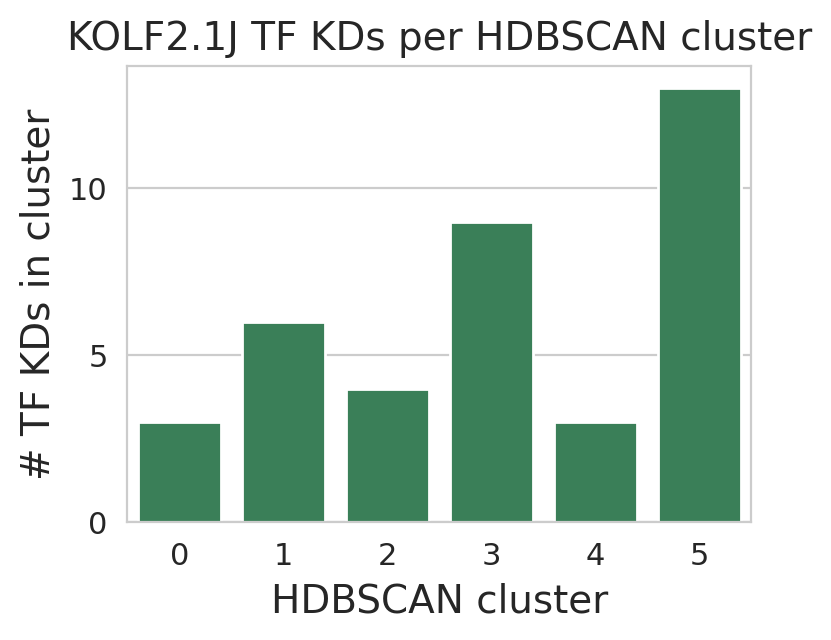

In [68]:
plot_n_perts_per_cluster(hdbscan_cluster_kds, title="KOLF2.1J TF KDs per HDBSCAN cluster",
                         xlabel="HDBSCAN cluster", color="seagreen", figsize=(4,3))

In [ ]:
hdbscan_corum_df = find_corum_complexes_in_clusters(corum_perturb, hdbscan_cluster_kds, "HDBSCAN")
hdbscan_corum_df

,HDBSCAN cluster,CORUM complex


## Standardize mean profiles

In [70]:
perturb_mean_profiles.shape

(909, 180)

In [34]:
mp_standardized = psp.da.standardize(perturb_mean_profiles, axis=0)

In [72]:
mp_standardized.shape

(180, 909)

## MDE (25 spectral nbrs, 7 MDE nbrs, repulsive fraction 5)

In [76]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                   n_components=20,
                                   spectral_n_neighbors=25,
                                   mde_n_neighbors=7, 
                                   repulsive_fraction=5)

Jun 05 12:56:51 AM: Fitting a centered embedding into R^2, for a graph with 180 items and 5896 edges.
Jun 05 12:56:51 AM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 05 12:56:51 AM: iteration 0000 | distortion 0.886607 | residual norm 0.247103 | step length 0.303738 | percent change 0.395572
Jun 05 12:56:51 AM: iteration 0200 | distortion 0.239401 | residual norm 0.000426666 | step length 1 | percent change 0.389276
Jun 05 12:56:52 AM: iteration 0400 | distortion 0.238921 | residual norm 2.4057e-05 | step length 0 | percent change 0
Jun 05 12:56:54 AM: iteration 0600 | distortion 0.238921 | residual norm 2.40575e-05 | step length 0 | percent change 0
Jun 05 12:56:56 AM: iteration 0800 | distortion 0.238921 | residual norm 2.40575e-05 | step length 0 | percent change 0
Jun 05 12:56:58 AM: iteration 1000 | distortion 0.238921 | residual norm 2.40575e-05 | step length 0 | percent change 0
Jun 05 12:57:00 AM: iteration 1200 | distortion 0.238921 | residual nor

Choose number of neighbors for KNN graph based on agreement with HDBSCAN clusters

In [77]:
pd.options.display.float_format = '{:,.3f}'.format

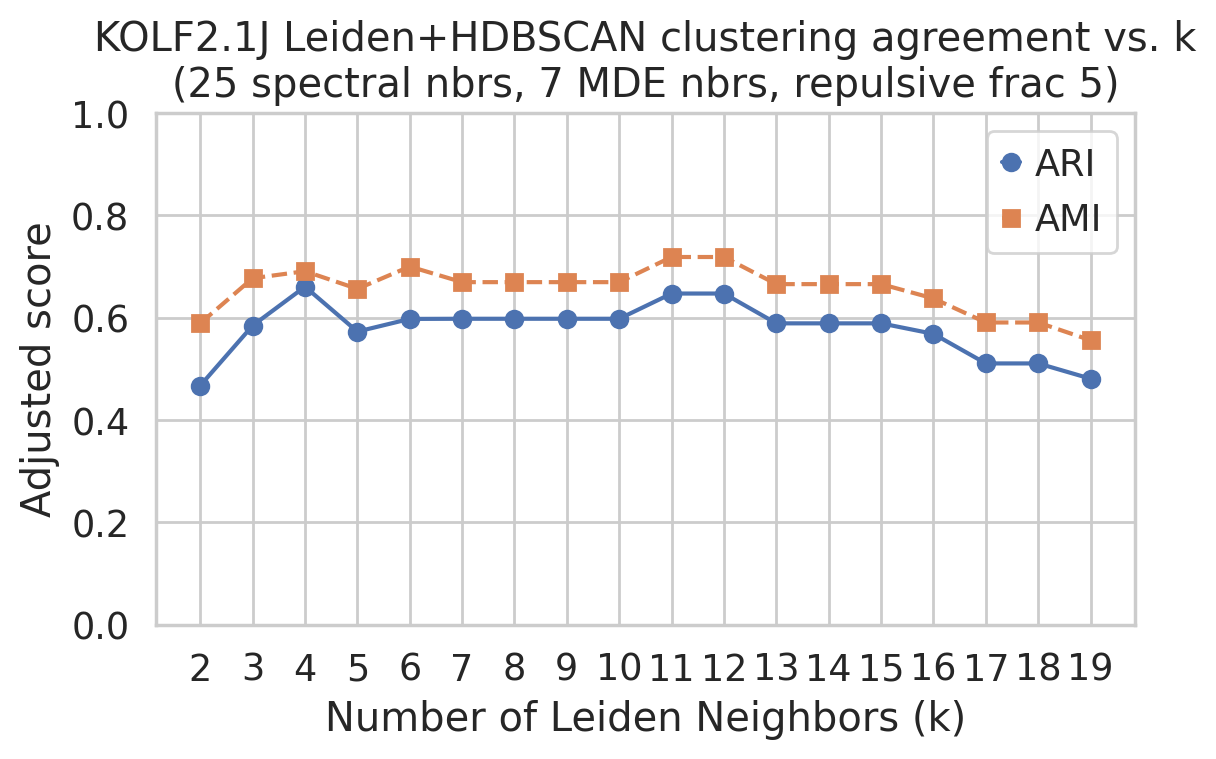

In [78]:
title = "KOLF2.1J Leiden+HDBSCAN clustering agreement vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 5)"
ari_ami_df = plot_cluster_agreement(mde_embedding, perturbation_HDBSCAN_labels,
                                    title=title)

In [79]:
ari_ami_df.head()

,ARI,AMI
2,0.467,0.589
3,0.584,0.677
4,0.660,0.691
5,0.573,0.656
6,0.598,0.700


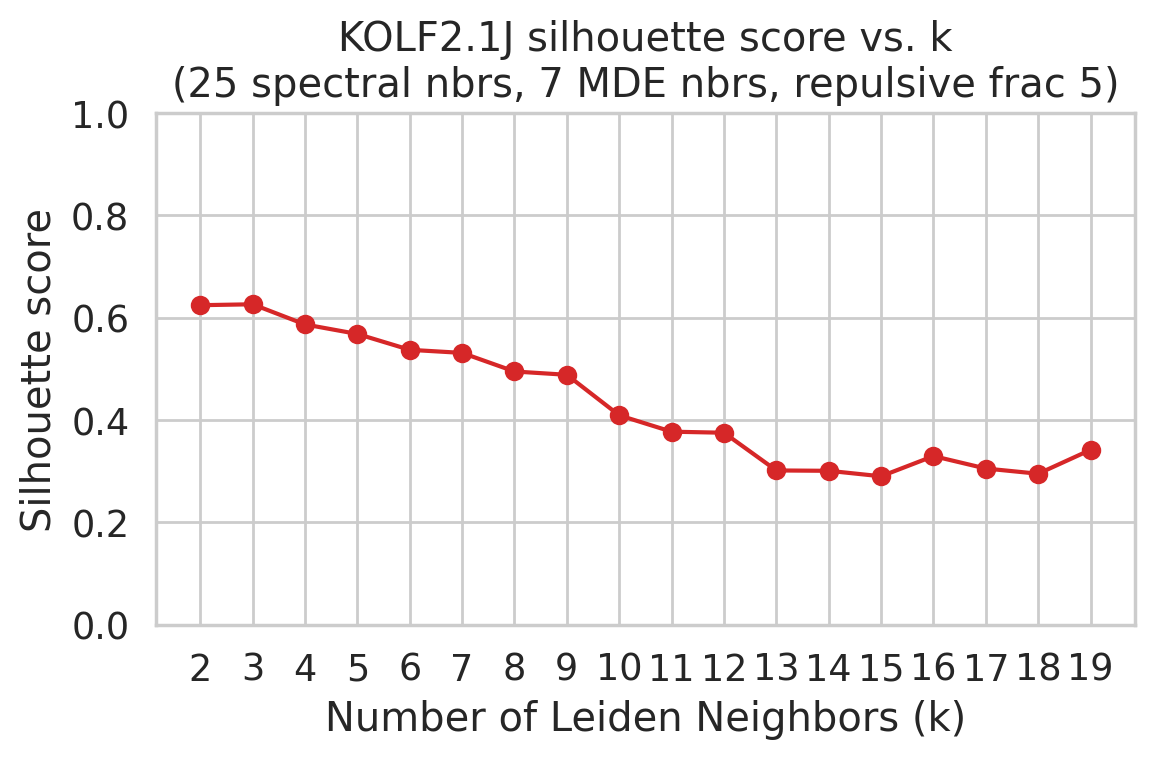

In [80]:
title = "KOLF2.1J silhouette score vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 5)"
silhouette_score_df = plot_silhouette_scores(mde_embedding, title=title)

In [81]:
silhouette_score_df.head()

,Silhouette score
2,0.624
3,0.626
4,0.587
5,0.568
6,0.537


### 6 KNN nbrs

In [112]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels, 
                            n_neighbors=6)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=6, # number of neighbors for KNN graph
                         title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)")

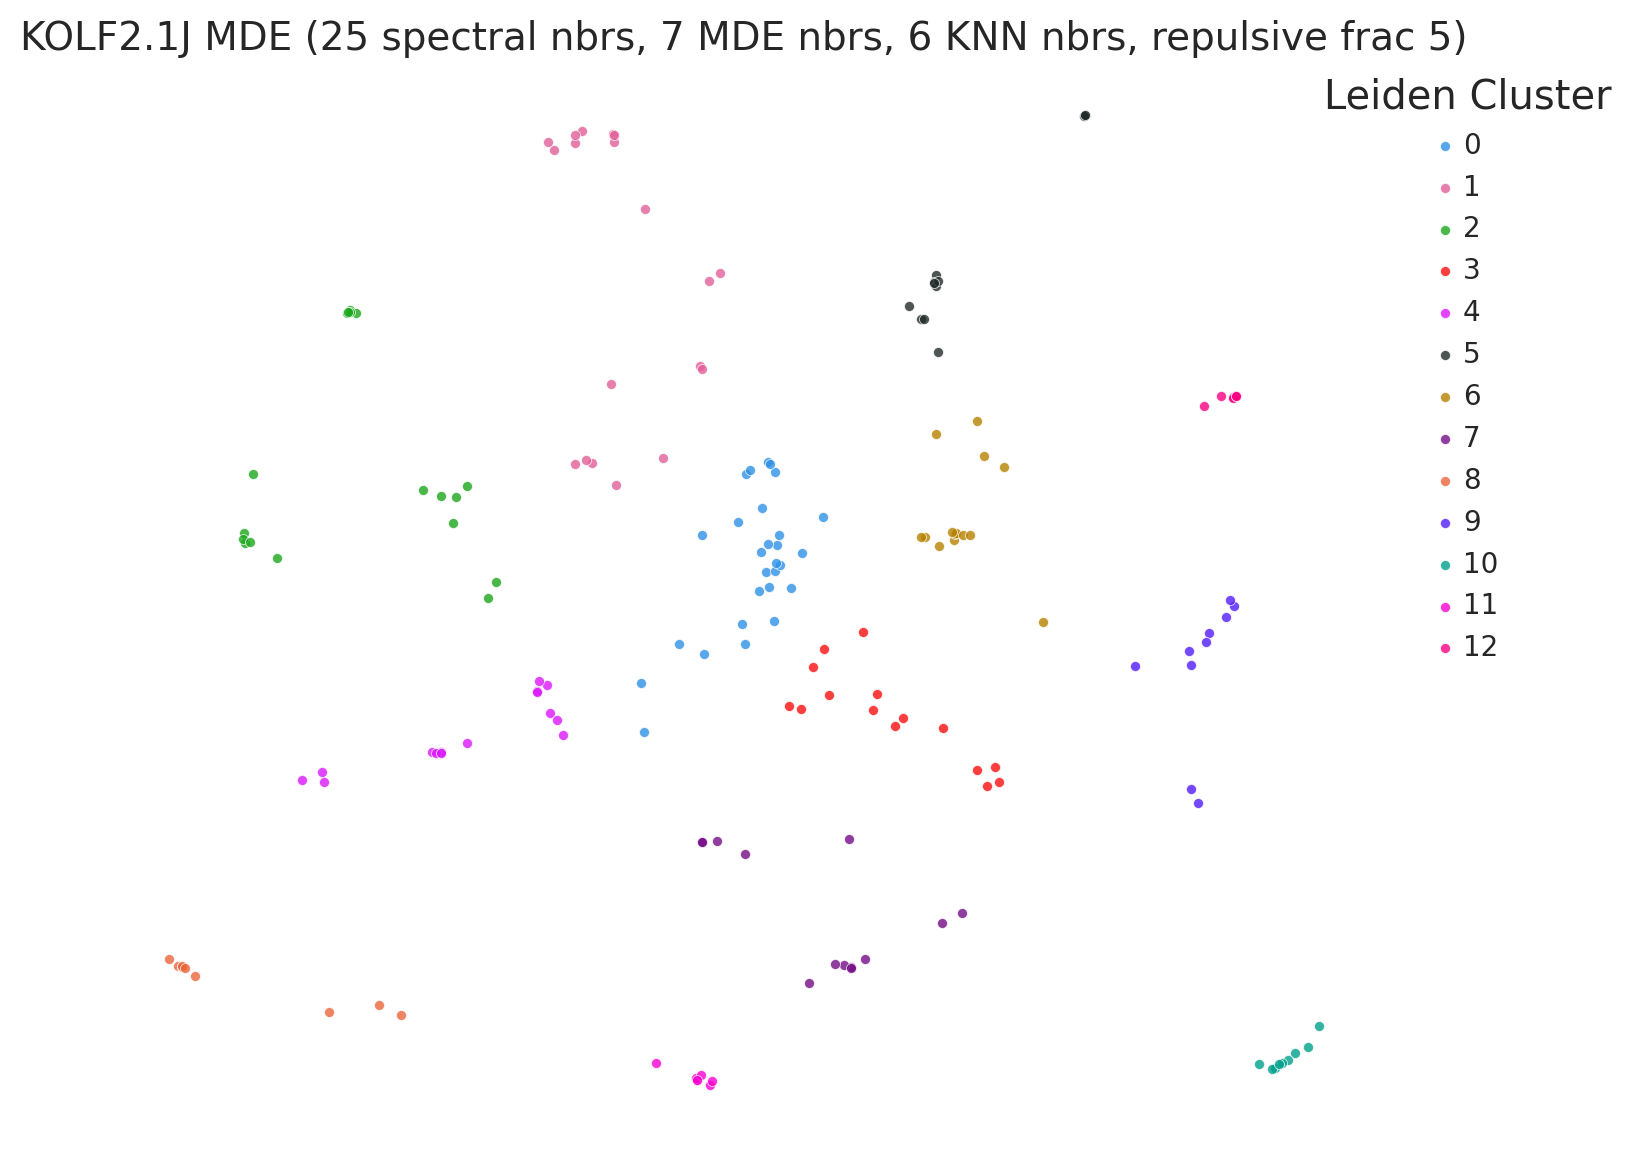

In [79]:
_ = plot_mde_static(mde_embedding, bulks_mde,
                    n_neighbors=6, # number of neighbors for KNN graph
                    title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)")

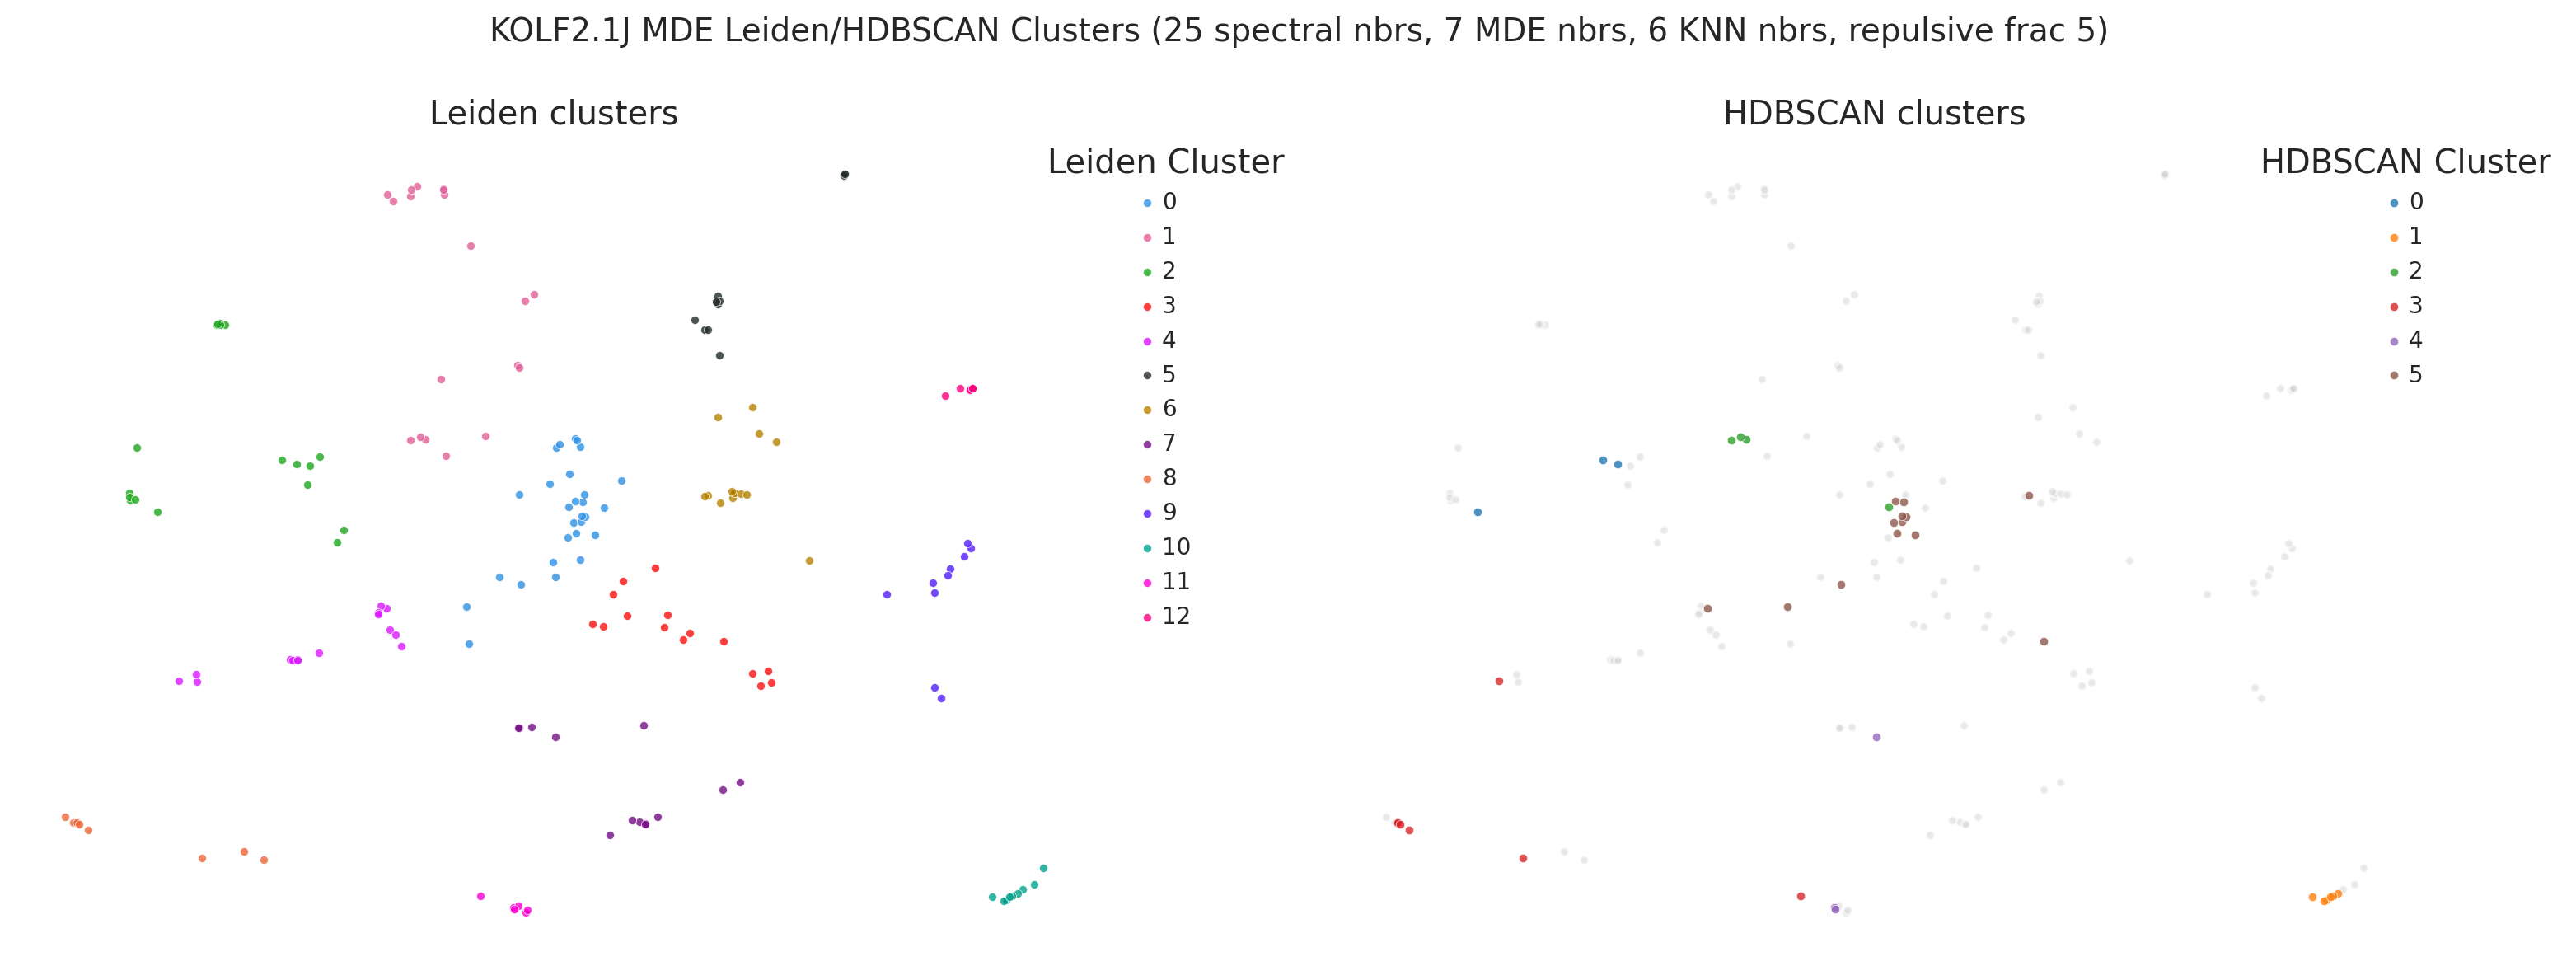

In [80]:
_ = plot_mde_leiden_hdbscan(mde_embedding, perturbation_HDBSCAN_labels, 
                            bulks_mde, n_neighbors=6,
                            suptitle="KOLF2.1J MDE Leiden/HDBSCAN Clusters (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)")

In [ ]:
title="KOLF2.1J subset MDE Leiden Clusters & CORUM Complexes (25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 5)"
_ = plot_mde_leiden_corum(mde_embedding, bulks_mde, corum_complexes, n_neighbors=5,
                          suptitle=title)

/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix


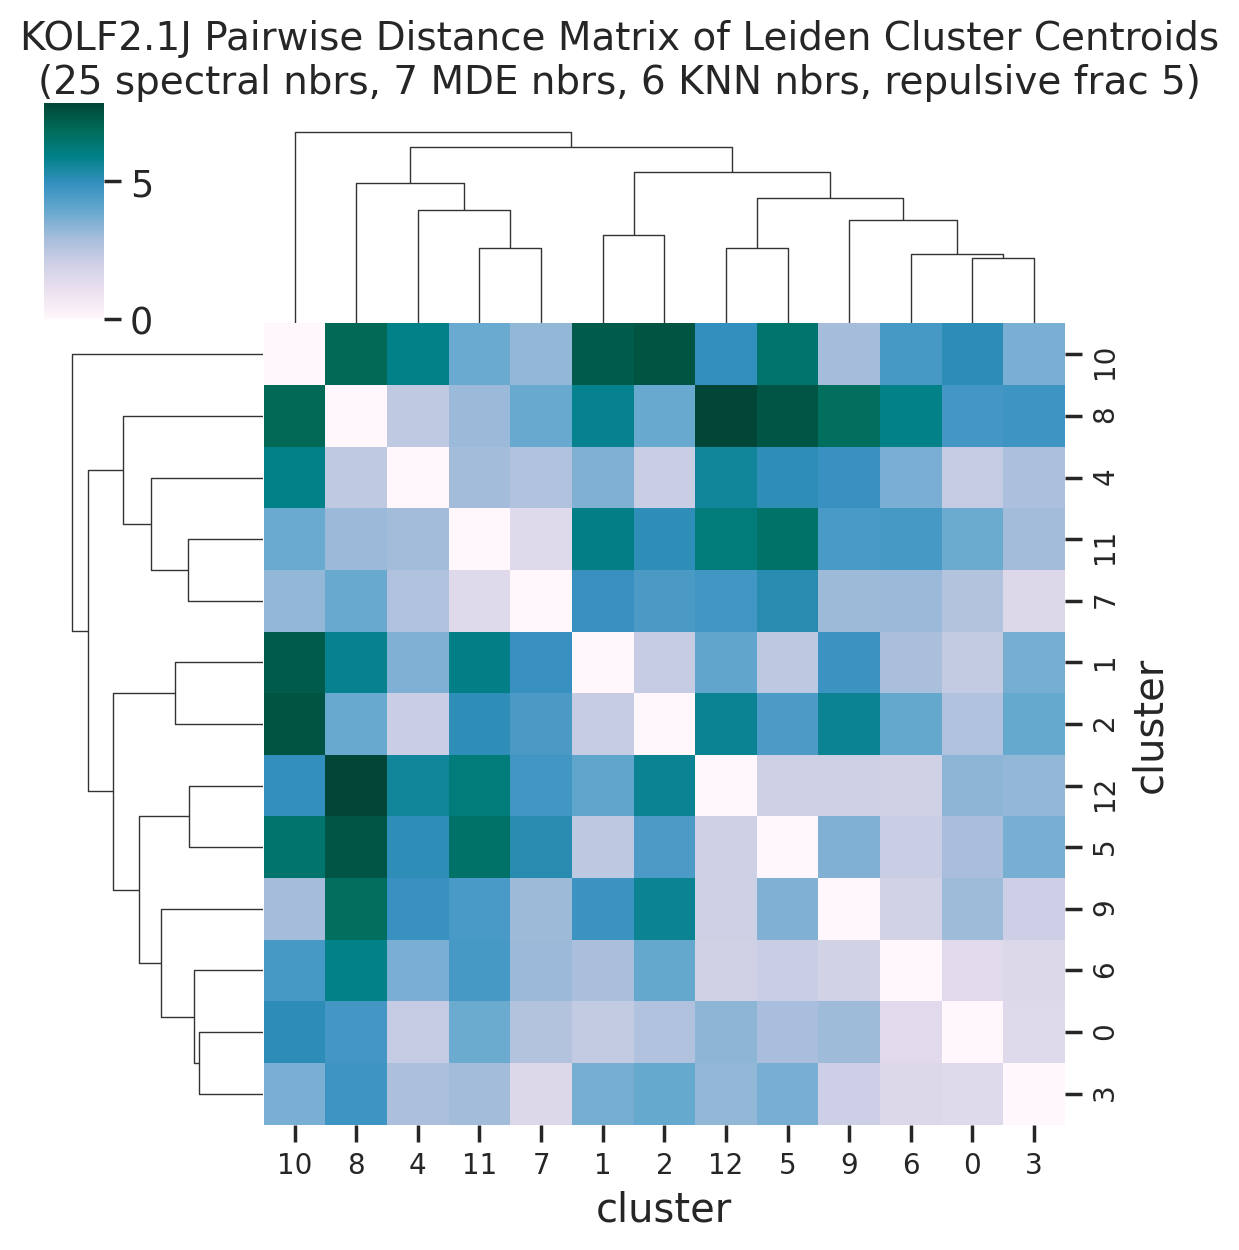

In [81]:
title="KOLF2.1J Pairwise Distance Matrix of Leiden Cluster Centroids\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
plot_pairwise_distance_matrix(mde_embedding, bulks_mde, n_neighbors=6, figsize=(6,6), tick_fontsize=10,
                              title=title, title_y_position=1.05)

In [113]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,CREB3L3,BARX1,BCL6B,DUXA,ARNT2,ARID3B,ATF1,ARID2,DOT1L,DMRT2,ADNP2,ARHGAP35,KMT2B
1,DMBX1,BHLHE40,CBX2,NKX6-2,BATF,LEF1,ESR1,ATF4,ETV3L,FOXE1,CHAMP1,KDM2A,NACC2
2,ESRRG,CREBL2,GLIS1,PHF1,ELF4,NKX2-4,ETV7,FOXH1,HNF4A,FOXG1,DNMT1,SOX4,NR4A3
3,FOXD3,EBF2,IKZF4,POU4F3,GATA5,RARG,IRF9,JUNB,PHF20,MESP1,E2F4,SOX11,REST
4,HIC1,EBF3,KLF14,RFX2,HBP1,RFX7,LCORL,KLF4,POU3F2,SIX5,PITX3,ZNF205,TCF20
5,HNF1A,EOMES,L3MBTL3,SETDB2,HMX3,SMAD3,MBD3,MTERF1,POU5F1,SPDEF,SETDB1,ZNF219,TGIF2
6,HOXA7,GPBP1L1,LHX1,TIGD7,NANOG,THAP6,RAG1,RXRG,POU5F1B,TMF1,VDR,ZNF763,ZBTB39
7,IRX5,GRHL2,MESP2,ZBTB4,NFE2L2,TSHZ1,RORC,THAP12,RBPJ,ZBTB22,ZNF561,NaN,NaN
8,NFKB2,GTF2IRD1,PCGF2,ZNF34,RFX5,ZNF14,TFCP2L1,ZBTB12,SP1,ZNF517,ZNF562,NaN,NaN
9,NR5A1,POU2F1,PKNOX2,ZNF136,SNAI2,ZNF16,ZBTB21,ZBTB14,ZNF396,ZNF688,NaN,NaN,NaN


In [97]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/KOLF_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-2-26.csv"
leiden_cluster_kds.to_csv(leiden_filepath)

In [ ]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/KOLF_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-2-26.csv"
leiden_cluster_kds = pd.read_csv(leiden_filepath, header=0, index_col=0)
leiden_cluster_kds.head()

[28, 19, 18, 15, 15, 14, 14, 13, 11, 10, 9, 7, 7]


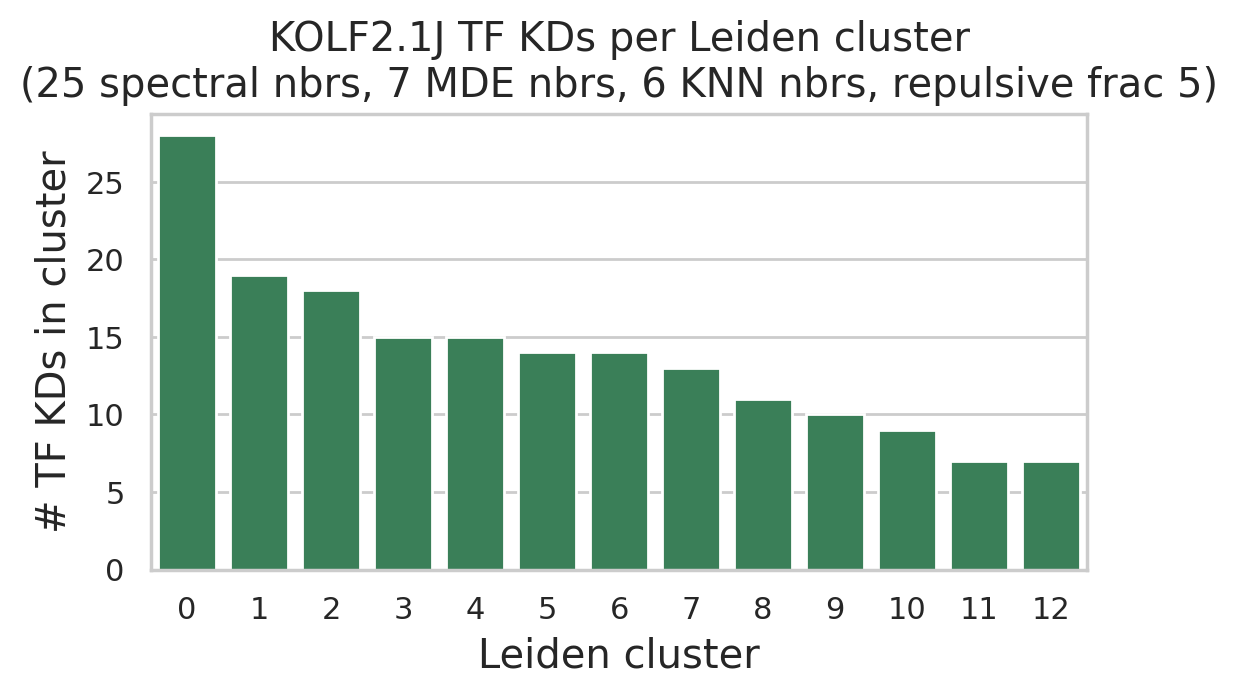

In [99]:
title = "KOLF2.1J TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title,
                         xlabel="Leiden cluster", color="seagreen", figsize=(6,3))

Check DEGs per cluster

In [114]:
sns.set_style("whitegrid")

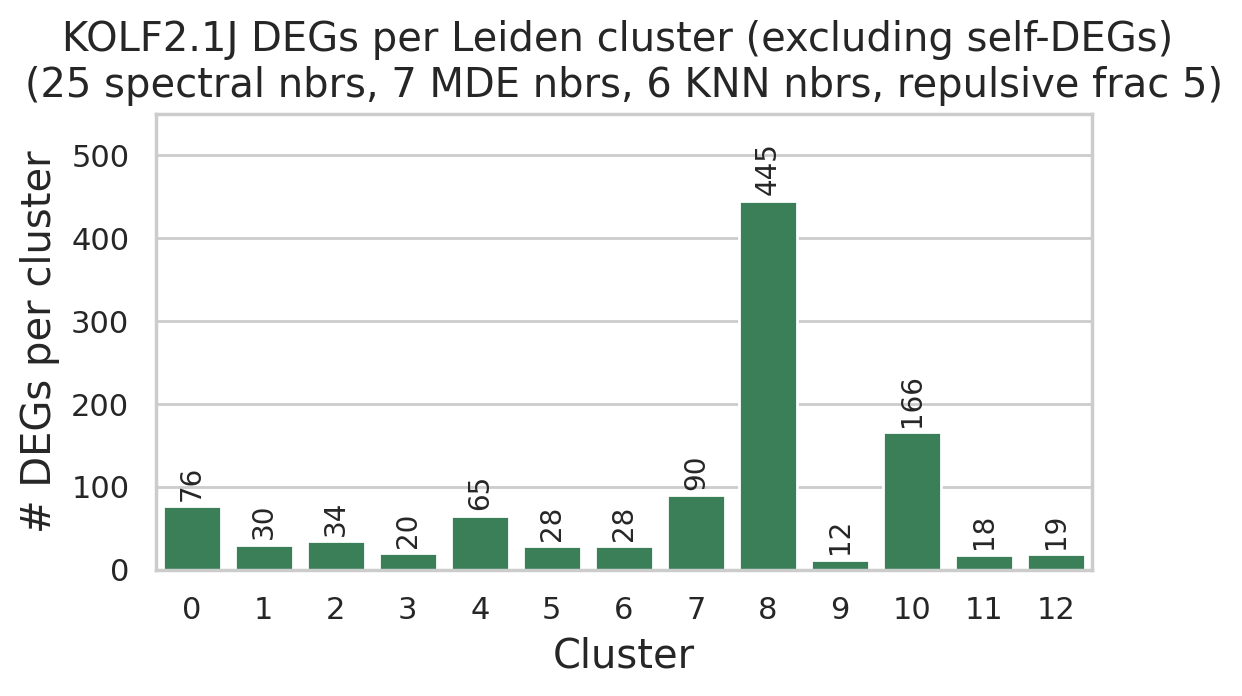

In [115]:
cluster_deg_dict_kolf = build_cluster_DEGs_dict(kd_deg_dict_kolf,
                                                leiden_cluster_kds)
title = "KOLF2.1J DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_kolf, title=title, color="seagreen", figsize=(6,3), ymax=550)

Check which clusters contain KDs of TFs with known function

In [87]:
pd.options.display.float_format = '{:,.0f}'.format

In [ ]:
kds_high_degs = n_degs_df.head(20).index.tolist()
print(", ".join(kds_high_degs))

POU5F1, DNMT1, ZNF521, THAP12, ZNF396, NANOG, ADNP2, PHF20, CHAMP1, POU5F1B, SETDB1, FOXH1, POU3F2, FOXD3, ZNF787, ZNF462, REST, PITX3, TCF7L1, HMX3


In [ ]:
find_kds_in_leiden_hdbscan_clusters(kds_high_degs, leiden_clusters_df=leiden_cluster_kds,
                                    hdbscan_clusters_df=hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
FOXD3,0,
ZNF462,0,
TCF7L1,2,
NANOG,4,3
HMX3,4,
ZNF787,7,4
THAP12,7,
FOXH1,7,
POU5F1,8,3
ZNF521,8,3


Check which Leiden clusters have HDBSCAN TF KDs

In [102]:
hdbscan_tf_kds = hdbscan_cluster_kds.to_numpy().flatten().tolist()
hdbscan_tf_kds = [kd for kd in hdbscan_tf_kds if not isinstance(kd, float)]
print(len(hdbscan_tf_kds))

38


In [103]:
leiden_hdbscan_df = \
    find_kds_in_leiden_hdbscan_clusters(hdbscan_tf_kds, leiden_clusters_df=leiden_cluster_kds,
                                        hdbscan_clusters_df=hdbscan_cluster_kds, sort_by="hdbscan")

In [104]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([0,1,2])]

,Leiden cluster,HDBSCAN cluster
CBX2,2,0
PCGF2,2,0
PKNOX2,2,0
ADNP2,10,1
CHAMP1,10,1
DNMT1,10,1
PITX3,10,1
SETDB1,10,1
VDR,10,1
ZNF695,0,2


In [105]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([3,4])]

,Leiden cluster,HDBSCAN cluster
NANOG,4,3
PHF20,8,3
POU3F2,8,3
POU5F1,8,3
POU5F1B,8,3
RBPJ,8,3
ZNF396,8,3
ZNF521,8,3
ZNF219,11,3
ZNF787,7,4


In [106]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([5])]

,Leiden cluster,HDBSCAN cluster
ESRRG,0,5
IRX5,0,5
NFKB2,0,5
SIX6,0,5
ZFP37,0,5
ZFP41,0,5
ZNF24,0,5
ZNF426,0,5
ZNF623,0,5
ZNF732,0,5


## MDE (25 spectral nbrs, 7 MDE nbrs, repulsive fraction 4)

In [35]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                   n_components=20,
                                   spectral_n_neighbors=25,
                                   mde_n_neighbors=7, 
                                   repulsive_fraction=4)

Jun 05 12:35:47 AM: Fitting a centered embedding into R^2, for a graph with 180 items and 4937 edges.
Jun 05 12:35:47 AM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 05 12:35:47 AM: iteration 0000 | distortion 0.862873 | residual norm 0.261149 | step length 0.302342 | percent change 0.416135
Jun 05 12:35:47 AM: iteration 0200 | distortion 0.268782 | residual norm 0.00153511 | step length 1 | percent change 0.744544
Jun 05 12:35:48 AM: iteration 0400 | distortion 0.267023 | residual norm 3.36195e-05 | step length 1 | percent change 0.0758454
Jun 05 12:35:48 AM: iteration 0600 | distortion 0.266536 | residual norm 0.000300443 | step length 1 | percent change 0.744482
Jun 05 12:35:49 AM: iteration 0800 | distortion 0.266476 | residual norm 2.03226e-05 | step length 0 | percent change 0
Jun 05 12:35:51 AM: iteration 1000 | distortion 0.266476 | residual norm 2.03226e-05 | step length 0 | percent change 0
Jun 05 12:35:53 AM: iteration 1200 | distortion 0.266476

Choose number of neighbors for KNN graph based on agreement with HDBSCAN clusters

In [ ]:
pd.options.display.float_format = '{:,.3f}'.format

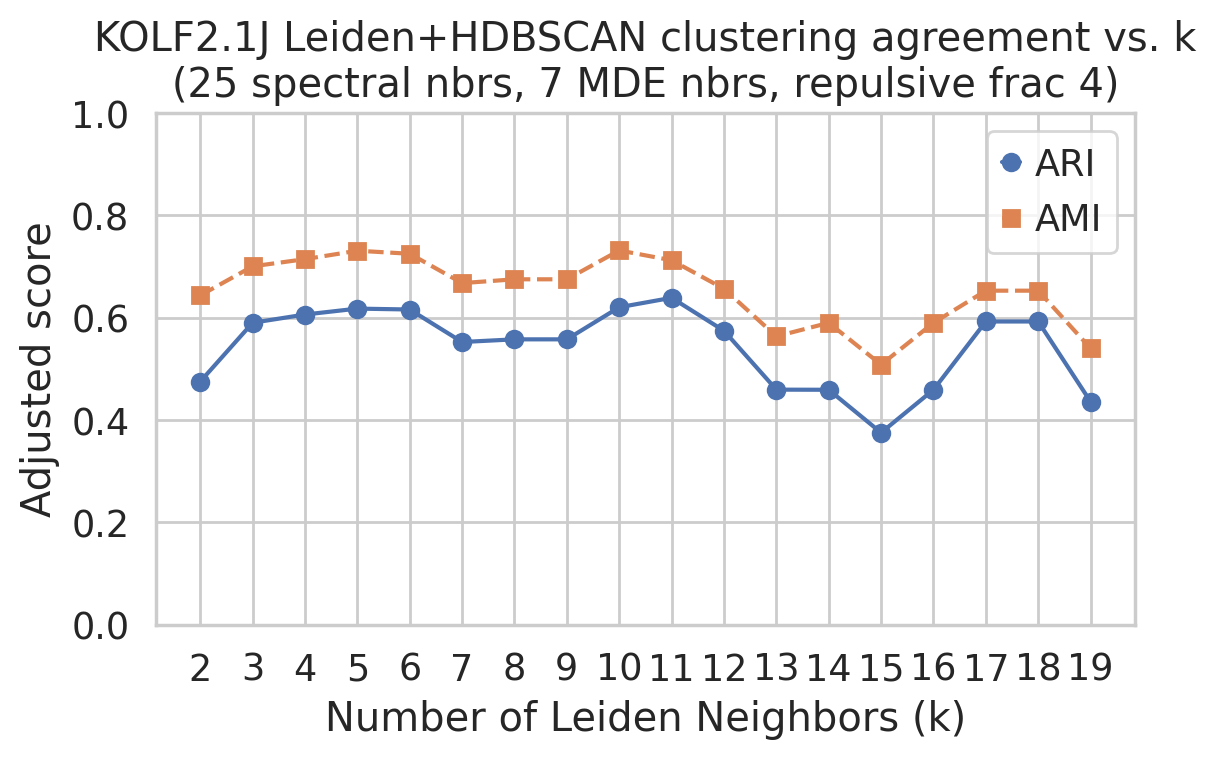

In [37]:
title = "KOLF2.1J Leiden+HDBSCAN clustering agreement vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 4)"
ari_ami_df = plot_cluster_agreement(mde_embedding, perturbation_HDBSCAN_labels,
                                    title=title)

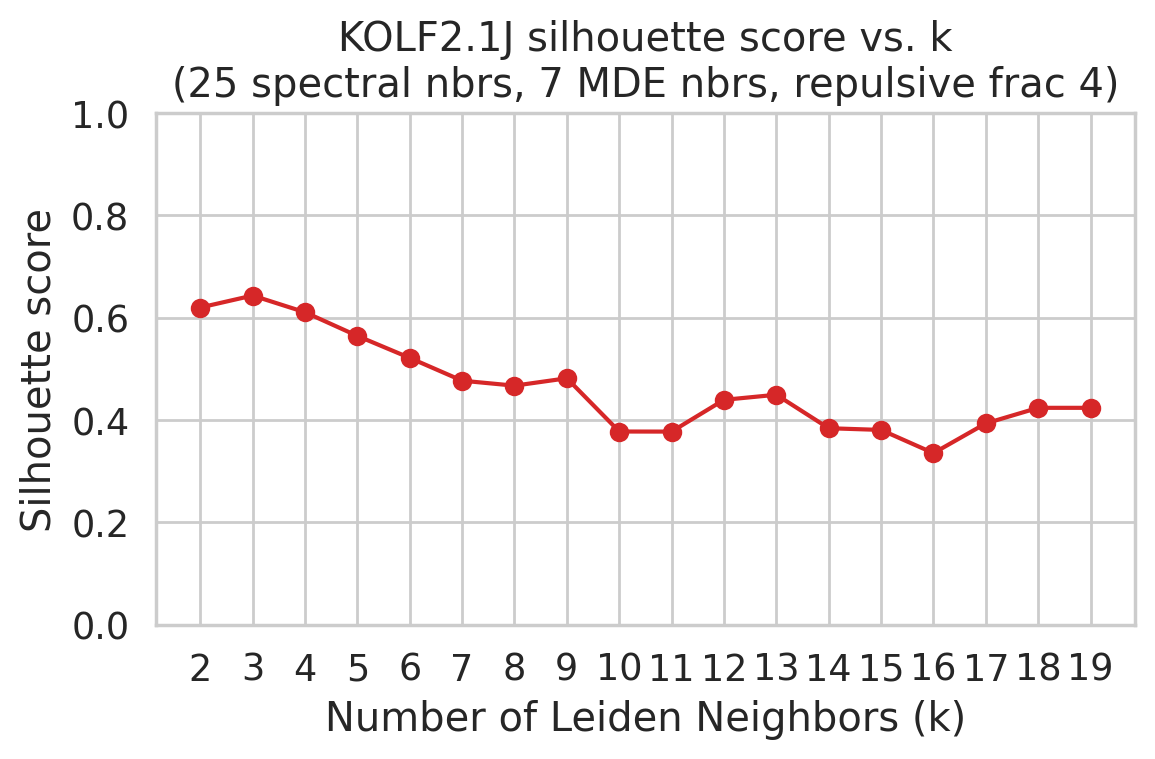

In [38]:
title = "KOLF2.1J silhouette score vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 4)"
silhouette_score_df = plot_silhouette_scores(mde_embedding, title=title)

### 4 KNN nbrs

In [39]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels, 
                            n_neighbors=4)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=6, # number of neighbors for KNN graph
                         title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)")

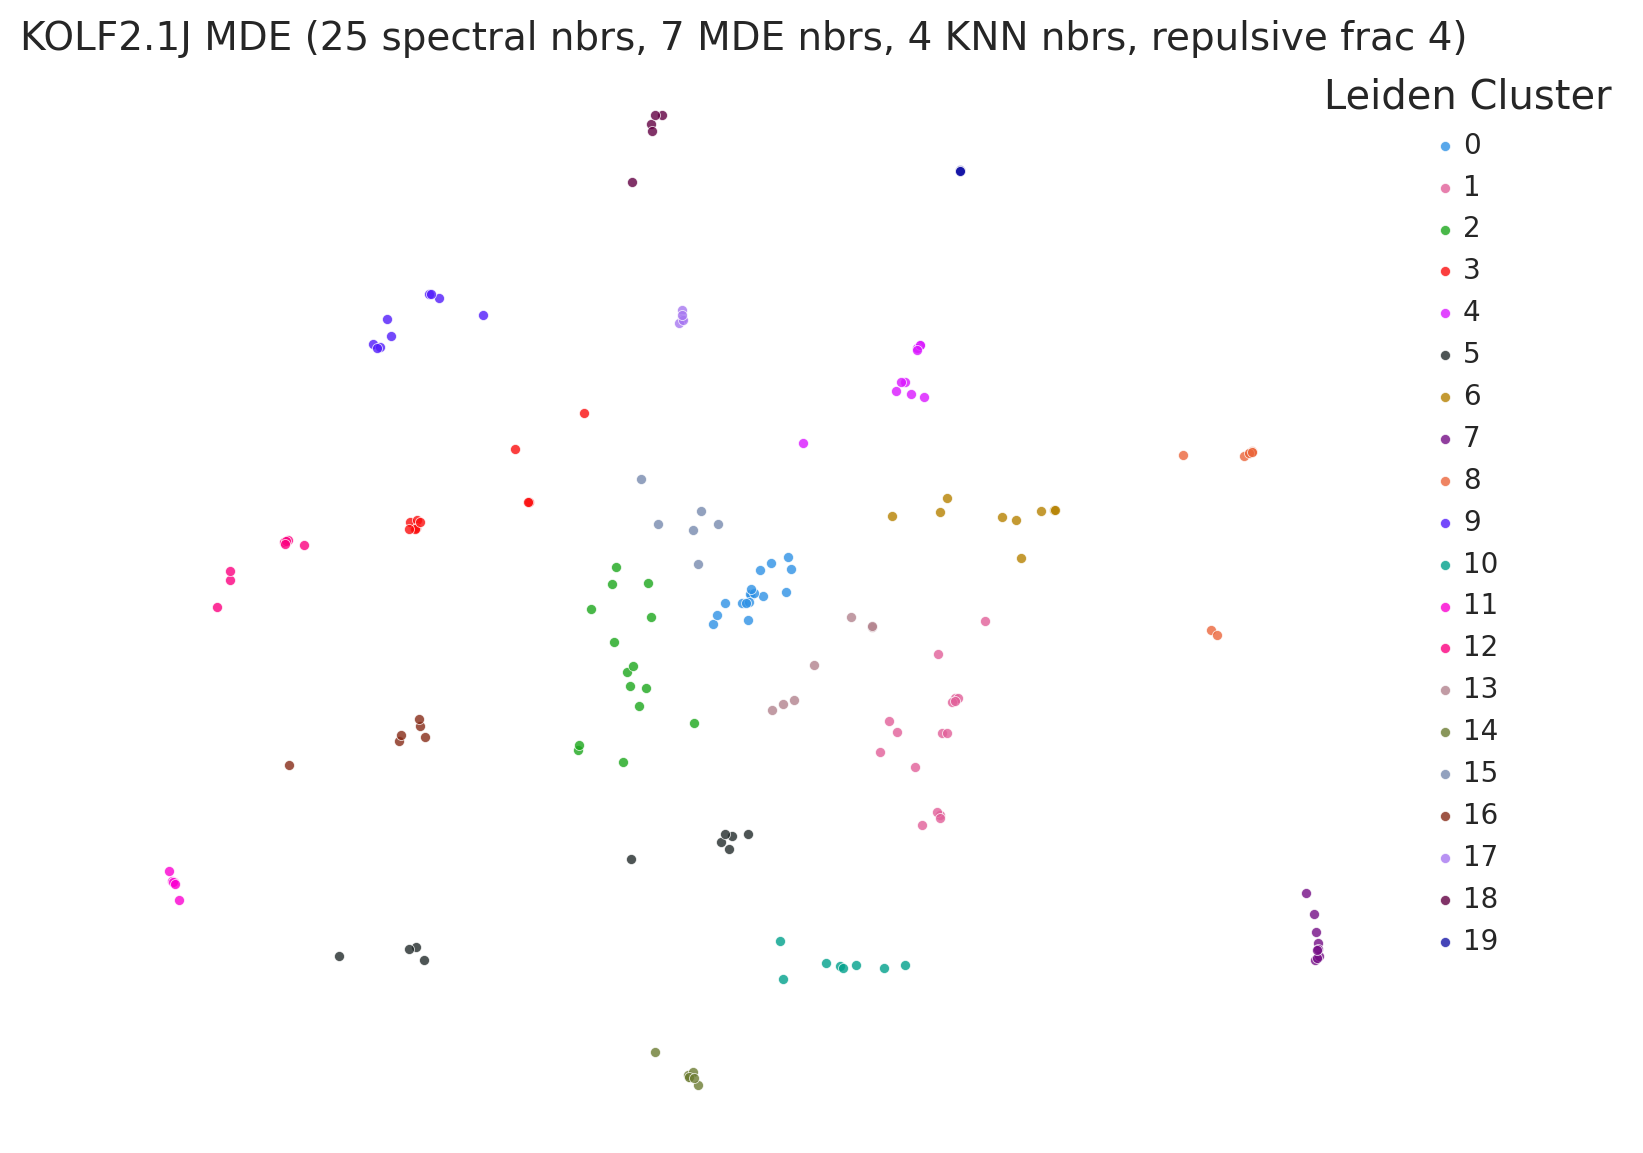

In [40]:
_ = plot_mde_static(mde_embedding, bulks_mde,
                    n_neighbors=4, # number of neighbors for KNN graph
                    title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 4 KNN nbrs, repulsive frac 4)")

In [ ]:
_ = plot_mde_leiden_hdbscan(mde_embedding, perturbation_HDBSCAN_labels, 
                            bulks_mde, n_neighbors=6,
                            suptitle="KOLF2.1J MDE Leiden/HDBSCAN Clusters (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)")

In [ ]:
title="KOLF2.1J subset MDE Leiden Clusters & CORUM Complexes (25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 5)"
_ = plot_mde_leiden_corum(mde_embedding, bulks_mde, corum_complexes, n_neighbors=5,
                          suptitle=title)

In [ ]:
title="KOLF2.1J Pairwise Distance Matrix of Leiden Cluster Centroids\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
plot_pairwise_distance_matrix(mde_embedding, bulks_mde, n_neighbors=6, figsize=(6,6), tick_fontsize=10,
                              title=title, title_y_position=1.05)

In [41]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,CREB3L3,ATF1,HIC1,ARNT2,ARID3B,ATF4,FOXE1,ADNP2,DMRT2,BARX1,ARID2,DOT1L,ELF4,DMBX1,ARHGAP35,DUXA,CBX2,BCL6B,GLIS1,RFX7
1,ESRRG,EBF2,IRX5,BATF,CREBL2,EOMES,MESP1,CHAMP1,FOXG1,BHLHE40,FOXH1,HNF4A,HBP1,HOXA7,KDM2A,SP140L,PCGF2,LHX1,KLF14,SMAD3
2,HNF1A,ESR1,NKX6-2,GATA5,LEF1,ETV3L,SIX5,DNMT1,KMT2B,EBF3,JUNB,PHF20,HMX3,IRF9,SOX4,TBX19,PKNOX2,MESP2,L3MBTL3,TSHZ1
3,NFKB2,ETV7,PCGF6,IKZF4,NKX2-4,FOXD3,SPDEF,E2F4,NACC2,GPBP1L1,MTERF1,POU3F2,NANOG,TFCP2L1,SOX11,ZBTB34,ZNF22,POGK,TCF7L1,ZNF564
4,NR5A1,GTF2IRD1,PHF1,NFE2L2,RARG,KLF4,TMF1,PITX3,NR4A3,GRHL2,THAP12,POU5F1,RFX5,ZNF341,ZNF205,ZNF180,ZNF382,SP8,ZNF324,ZNF783
5,OVOL3,LCORL,POU4F3,ZNF394,THAP6,RBPJ,ZBTB22,SETDB1,REST,POU2F1,ZBTB12,POU5F1B,SNAI2,ZNF462,ZNF219,ZNF701,ZNF596,NaN,NaN,NaN
6,SP110,MBD3,RFX2,ZNF490,ZNF14,RXRG,ZNF517,VDR,TCF20,RREB1,ZBTB14,ZNF396,ZFP92,ZNF471,ZNF763,NaN,NaN,NaN,NaN,NaN
7,ZFP37,RAG1,SETDB2,ZNF614,ZNF16,SP1,ZNF688,ZNF561,TGIF2,ZFY,ZNF358,ZNF521,ZNF572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ZFP41,RORC,SIX6,ZNF658,ZNF112,ZNF142,ZSCAN5B,ZNF562,ZBTB39,ZNF292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ZNF24,ZBTB21,TIGD7,ZNF764,ZNF551,ZNF787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/KOLF_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-2-26.csv"
leiden_cluster_kds.to_csv(leiden_filepath)

In [ ]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/KOLF_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-2-26.csv"
leiden_cluster_kds = pd.read_csv(leiden_filepath, header=0, index_col=0)
leiden_cluster_kds.head()

[17, 16, 15, 11, 10, 10, 9, 9, 9, 9, 8, 8, 8, 7, 7, 6, 6, 5, 5, 5]


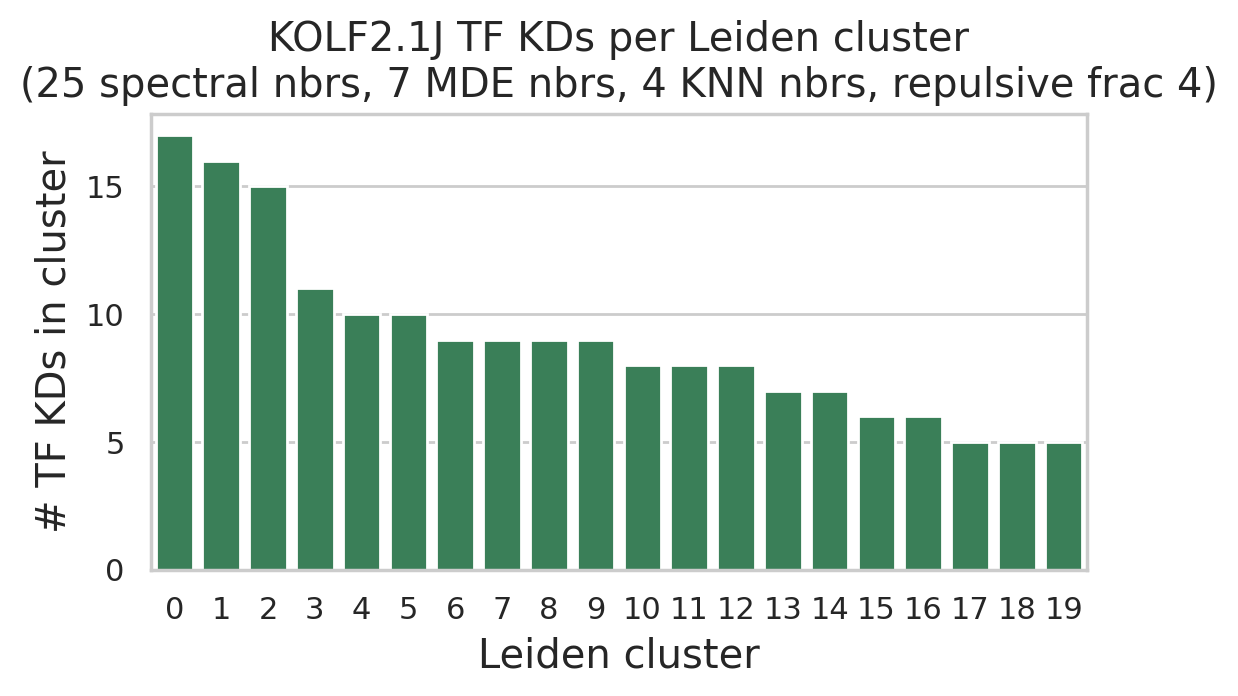

In [42]:
title = "KOLF2.1J TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 4 KNN nbrs, repulsive frac 4)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title,
                         xlabel="Leiden cluster", color="seagreen", figsize=(6,3))

Check DEGs per cluster

In [43]:
sns.set_style("whitegrid")

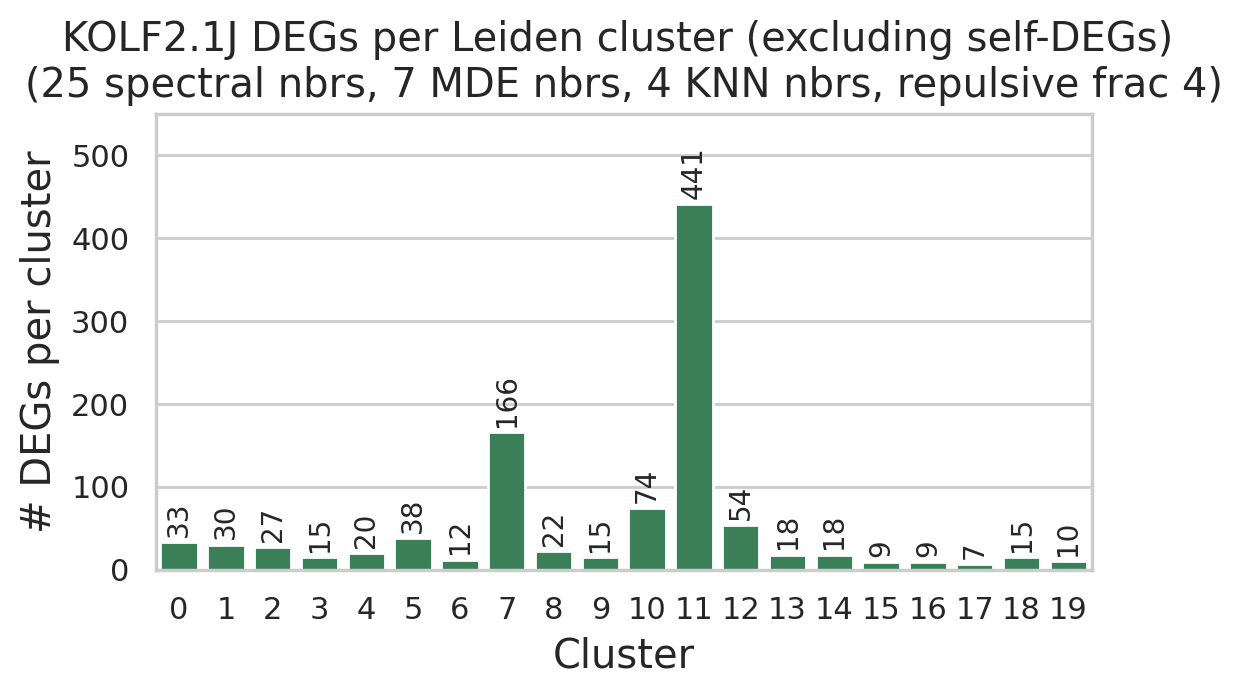

In [44]:
cluster_deg_dict_kolf = build_cluster_DEGs_dict(kd_deg_dict_kolf,
                                                leiden_cluster_kds)
title = "KOLF2.1J DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 4 KNN nbrs, repulsive frac 4)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_kolf, title=title, color="seagreen", figsize=(6,3), ymax=550)

Check which clusters contain KDs of TFs with known function

In [45]:
pd.options.display.float_format = '{:,.0f}'.format

In [46]:
kds_high_degs = n_degs_df.head(20).index.tolist()
print(", ".join(kds_high_degs))

POU5F1, DNMT1, ZNF521, THAP12, ZNF396, NANOG, ADNP2, PHF20, CHAMP1, POU5F1B, SETDB1, FOXH1, POU3F2, FOXD3, ZNF787, ZNF462, REST, PITX3, TCF7L1, HMX3


In [47]:
find_kds_in_leiden_hdbscan_clusters(kds_high_degs, leiden_clusters_df=leiden_cluster_kds,
                                    hdbscan_clusters_df=hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
ZNF787,5,4
FOXD3,5,
DNMT1,7,1
ADNP2,7,1
CHAMP1,7,1
SETDB1,7,1
PITX3,7,1
REST,8,
THAP12,10,
FOXH1,10,


## MDE (25 spectral nbrs, 7 MDE nbrs, repulsive fraction 3)

In [48]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                   n_components=20,
                                   spectral_n_neighbors=25,
                                   mde_n_neighbors=7, 
                                   repulsive_fraction=3)

Jun 05 12:41:06 AM: Fitting a centered embedding into R^2, for a graph with 180 items and 3959 edges.
Jun 05 12:41:06 AM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 05 12:41:06 AM: iteration 0000 | distortion 0.822570 | residual norm 0.283902 | step length 0.296488 | percent change 0.443632
Jun 05 12:41:07 AM: iteration 0200 | distortion 0.305212 | residual norm 0.000279509 | step length 1 | percent change 0.300823
Jun 05 12:41:08 AM: iteration 0400 | distortion 0.305138 | residual norm 1.4963e-05 | step length 0 | percent change 0
Jun 05 12:41:09 AM: iteration 0600 | distortion 0.305138 | residual norm 1.49633e-05 | step length 0 | percent change 0
Jun 05 12:41:11 AM: iteration 0800 | distortion 0.305138 | residual norm 1.49633e-05 | step length 0 | percent change 0
Jun 05 12:41:13 AM: iteration 1000 | distortion 0.305138 | residual norm 1.49633e-05 | step length 0 | percent change 0
Jun 05 12:41:14 AM: iteration 1200 | distortion 0.305138 | residual nor

Choose number of neighbors for KNN graph based on agreement with HDBSCAN clusters

In [ ]:
pd.options.display.float_format = '{:,.3f}'.format

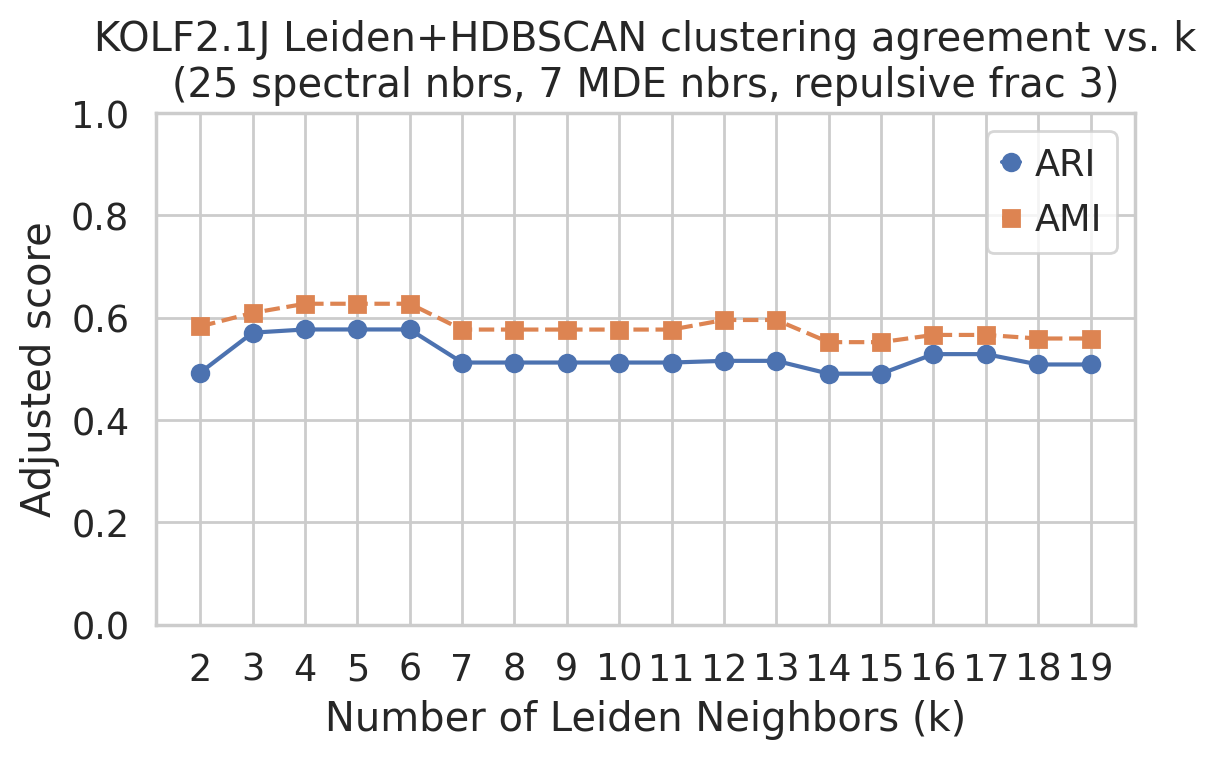

In [50]:
title = "KOLF2.1J Leiden+HDBSCAN clustering agreement vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 3)"
ari_ami_df = plot_cluster_agreement(mde_embedding, perturbation_HDBSCAN_labels,
                                    title=title)

In [60]:
ari_ami_df.head()

,ARI,AMI
2,0.671,0.711
3,0.553,0.644
4,0.564,0.664
5,0.593,0.674
6,0.593,0.674


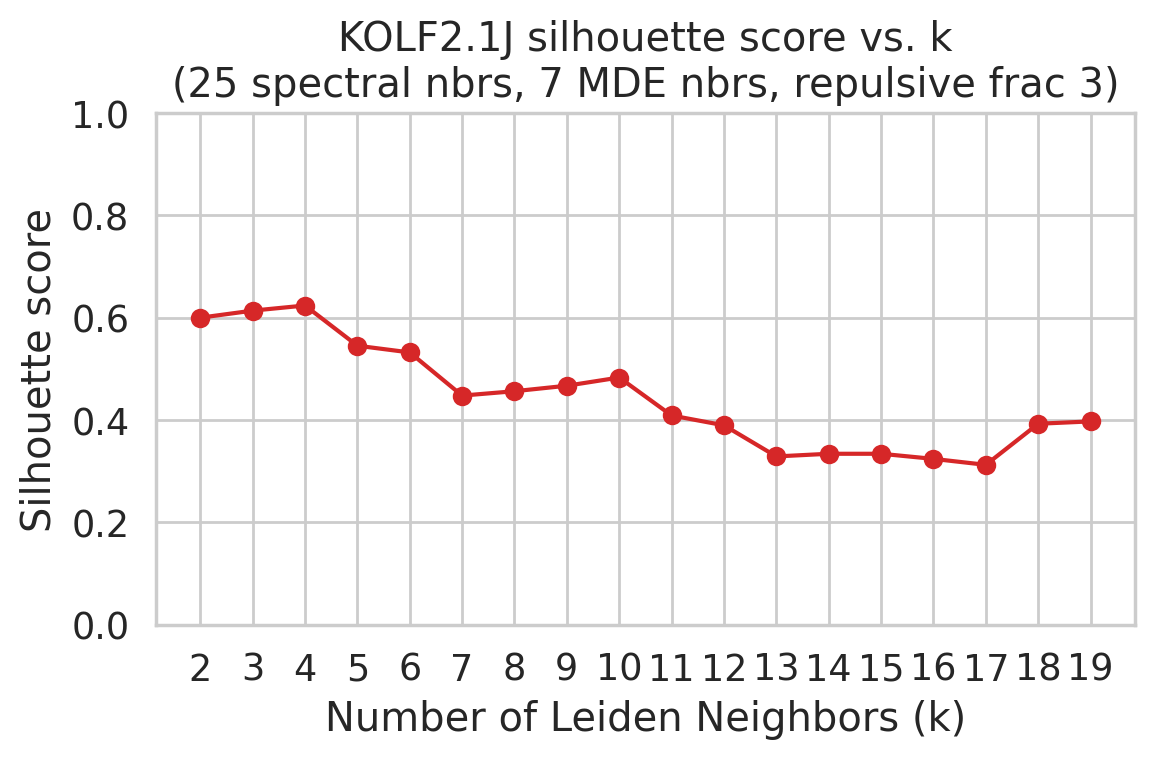

In [52]:
title = "KOLF2.1J silhouette score vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 3)"
silhouette_score_df = plot_silhouette_scores(mde_embedding, title=title)

In [61]:
silhouette_score_df.head()

,Silhouette score
2,0.581
3,0.551
4,0.551
5,0.465
6,0.431


### 6 KNN nbrs

In [73]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels, 
                            n_neighbors=6)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=6, # number of neighbors for KNN graph
                         title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 3)")

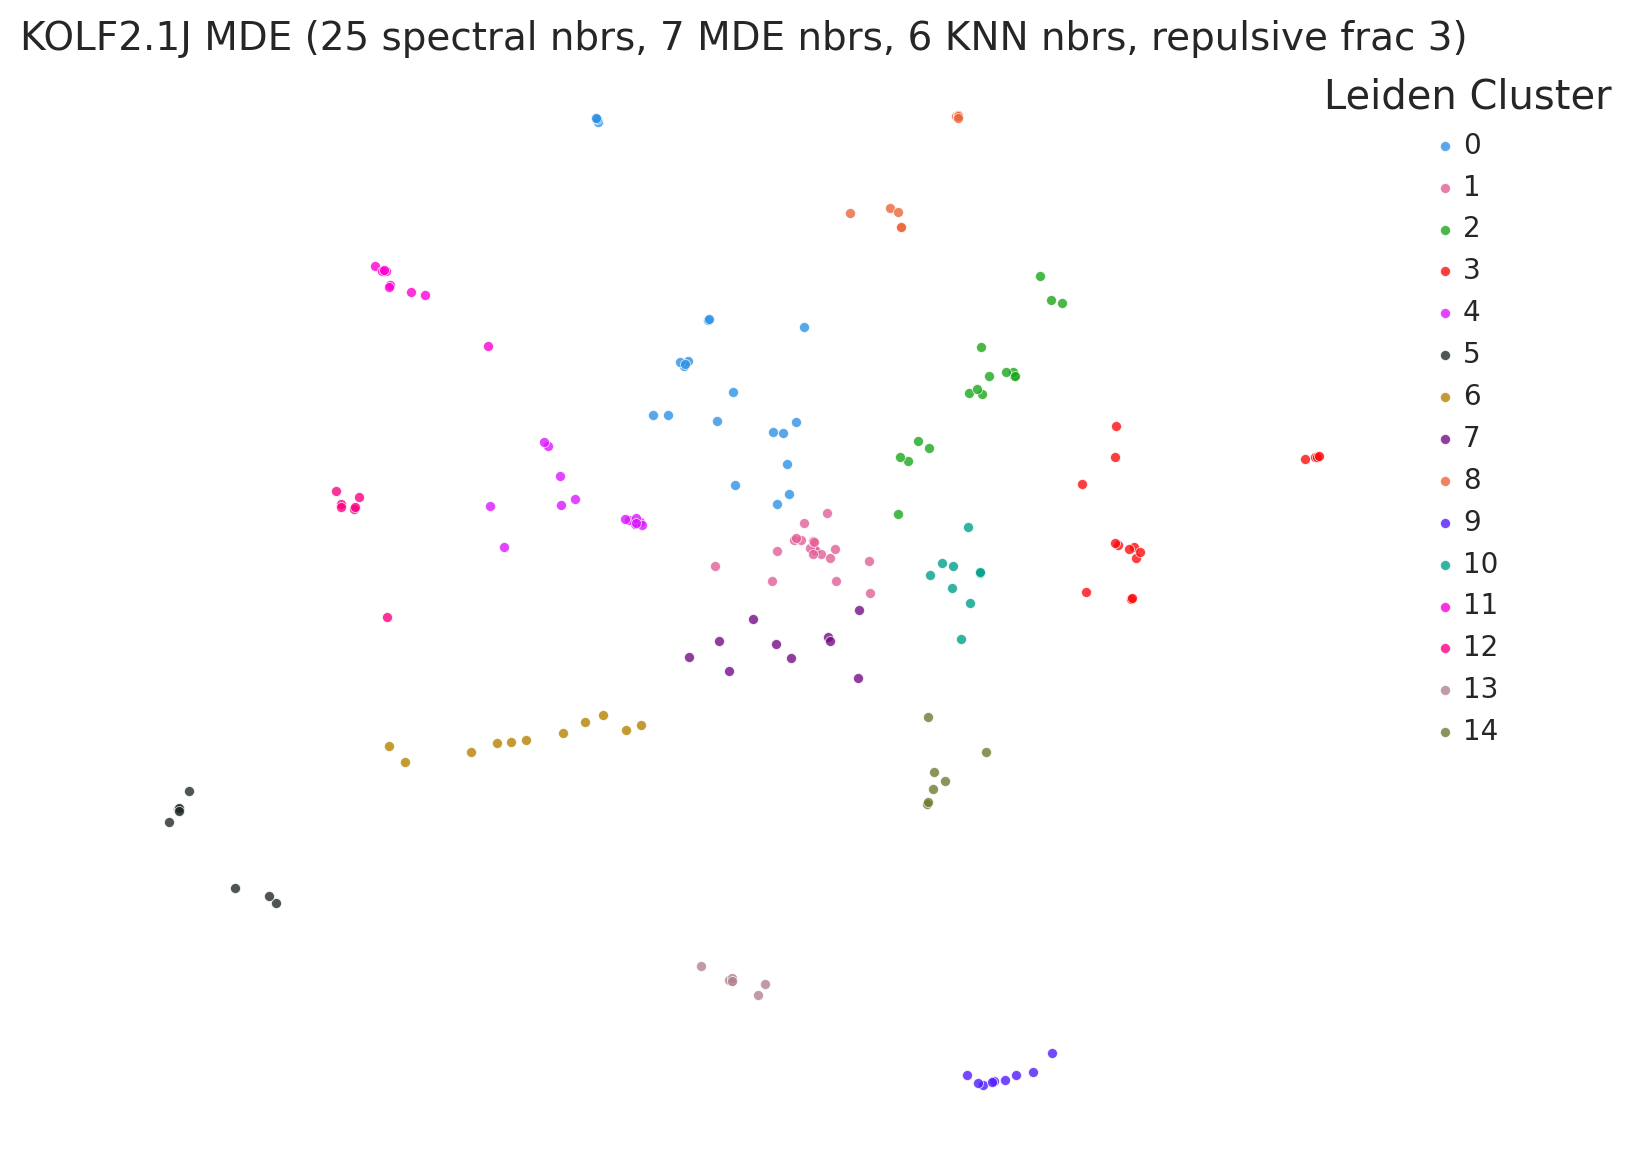

In [74]:
_ = plot_mde_static(mde_embedding, bulks_mde,
                    n_neighbors=6, # number of neighbors for KNN graph
                    title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 3)")

In [ ]:
_ = plot_mde_leiden_hdbscan(mde_embedding, perturbation_HDBSCAN_labels, 
                            bulks_mde, n_neighbors=6,
                            suptitle="KOLF2.1J MDE Leiden/HDBSCAN Clusters (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 2)")

In [ ]:
title="KOLF2.1J subset MDE Leiden Clusters & CORUM Complexes (25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 5)"
_ = plot_mde_leiden_corum(mde_embedding, bulks_mde, corum_complexes, n_neighbors=5,
                          suptitle=title)

In [ ]:
title="KOLF2.1J Pairwise Distance Matrix of Leiden Cluster Centroids\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
plot_pairwise_distance_matrix(mde_embedding, bulks_mde, n_neighbors=6, figsize=(6,6), tick_fontsize=10,
                              title=title, title_y_position=1.05)

In [76]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,BCL6B,CREB3L3,ARID2,ATF4,ARNT2,DOT1L,DMRT2,BATF,ARID3B,ADNP2,ATF1,BARX1,GLIS1,ARHGAP35,FOXE1
1,FOXD3,ESRRG,DUXA,ESR1,CBX2,ETV3L,ELF4,CREBL2,RARG,CHAMP1,NKX6-2,BHLHE40,HIC1,KDM2A,MESP1
2,GATA5,HNF1A,FOXH1,ETV7,EBF2,HNF4A,FOXG1,DMBX1,RFX7,DNMT1,PCGF6,EBF3,KLF14,SOX4,SIX5
3,IRX5,HOXA7,KLF4,LCORL,GTF2IRD1,PHF20,HBP1,EOMES,SMAD3,E2F4,PHF1,GPBP1L1,L3MBTL3,SOX11,SPDEF
4,LHX1,IRF9,LEF1,NACC2,IKZF4,POU3F2,HMX3,JUNB,THAP6,PITX3,TIGD7,GRHL2,PKNOX2,ZNF205,TMF1
5,MESP2,NFKB2,MTERF1,REST,KMT2B,POU5F1,NANOG,SP110,TSHZ1,SETDB1,ZBTB4,POU2F1,TCF7L1,ZNF219,ZNF517
6,NFE2L2,NR5A1,POU4F3,RFX2,MBD3,POU5F1B,RFX5,ZBTB22,ZNF16,VDR,ZNF142,RREB1,ZNF324,ZNF763,ZNF688
7,NKX2-4,OVOL3,RAG1,RORC,NR4A3,RBPJ,SNAI2,ZNF136,ZNF112,ZNF561,ZNF595,ZFY,NaN,NaN,NaN
8,POGK,ZBTB34,RXRG,TCF20,PCGF2,SP1,ZFP92,ZNF341,ZNF783,ZNF562,ZSCAN23,ZNF292,NaN,NaN,NaN
9,SIX6,ZFP37,SETDB2,TFCP2L1,ZNF22,ZNF396,ZNF564,ZSCAN18,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# leiden_filepath = \
#     "/home/ranwyl/output_files_tf_project/KOLF_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-2-26.csv"
# leiden_cluster_kds.to_csv(leiden_filepath)

In [ ]:
# leiden_filepath = \
#     "/home/ranwyl/output_files_tf_project/KOLF_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-2-26.csv"
# leiden_cluster_kds = pd.read_csv(leiden_filepath, header=0, index_col=0)
# leiden_cluster_kds.head()

[23, 20, 17, 17, 14, 11, 11, 10, 9, 9, 9, 9, 7, 7, 7]


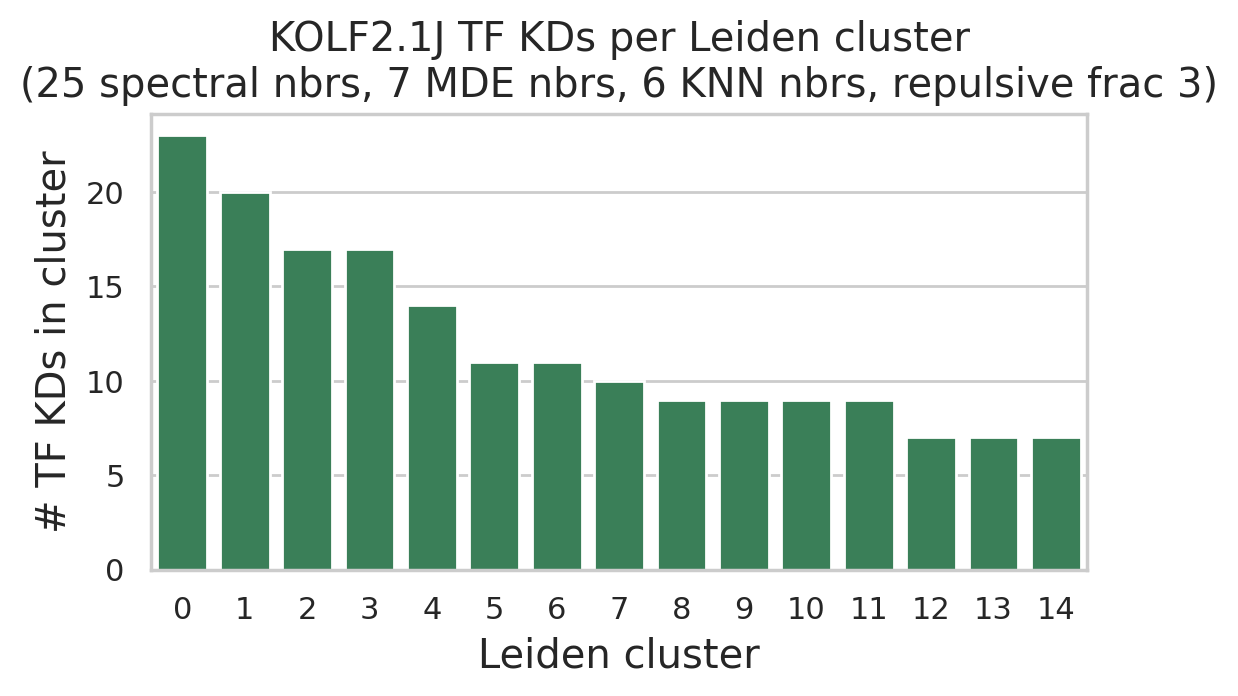

In [77]:
title = "KOLF2.1J TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 3)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title,
                         xlabel="Leiden cluster", color="seagreen", figsize=(6,3))

Check DEGs per cluster

In [78]:
sns.set_style("whitegrid")

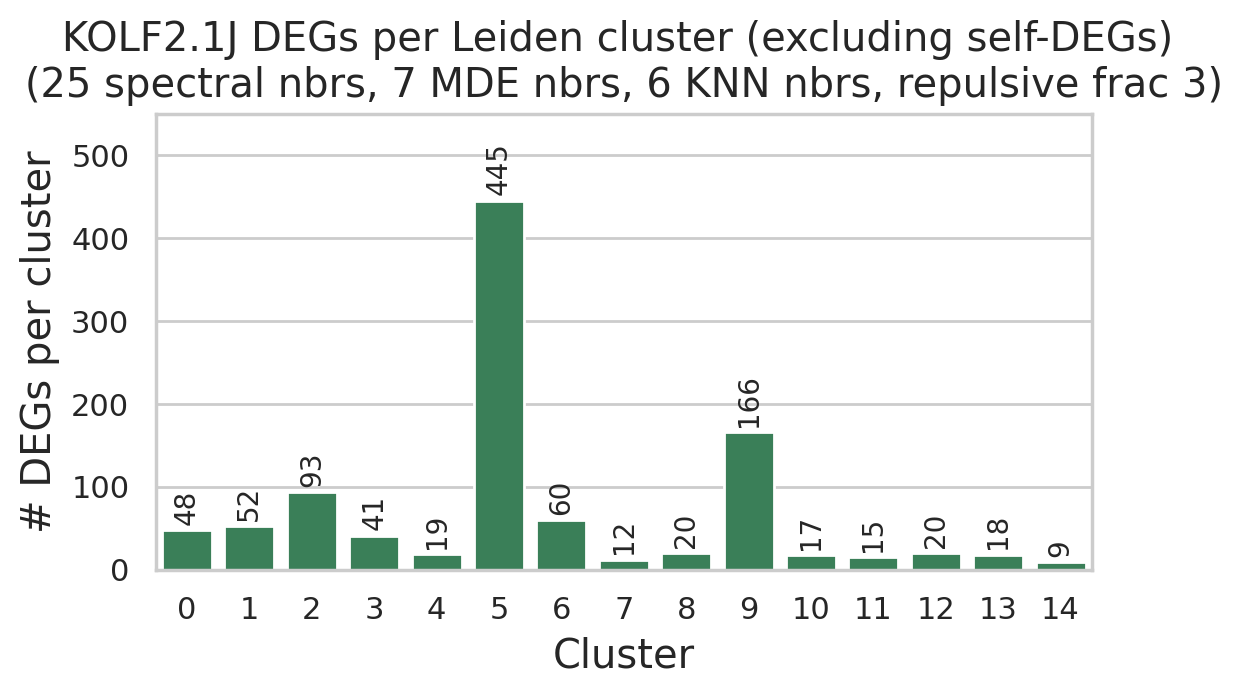

In [79]:
cluster_deg_dict_kolf = build_cluster_DEGs_dict(kd_deg_dict_kolf,
                                                leiden_cluster_kds)
title = "KOLF2.1J DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 3)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_kolf, title=title, color="seagreen", figsize=(6,3), ymax=550)

Check which clusters contain KDs of TFs with known function

In [80]:
pd.options.display.float_format = '{:,.0f}'.format

In [81]:
pluripotency_tfs = ['POU5F1', 'NANOG', 'SOX2', 'KLF4', 'MYC']
pluripotency_associated = ['SOX1', 'SOX3', 'KLF2', 'KLF5', 'MYCL', 'MYCN', 'UTF1', 'SALL4', 'TCL1A']
endoderm_tfs = ['GATA6', 'GATA4', 'FOXA2', 'SOX17']

In [82]:
find_kds_in_leiden_hdbscan_clusters(pluripotency_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
KLF4,2,
POU5F1,5,3
NANOG,6,3
SOX2,,
MYC,,


In [83]:
kds_high_degs = n_degs_df.head(20).index.tolist()
print(", ".join(kds_high_degs))

POU5F1, DNMT1, ZNF521, THAP12, ZNF396, NANOG, ADNP2, PHF20, CHAMP1, POU5F1B, SETDB1, FOXH1, POU3F2, FOXD3, ZNF787, ZNF462, REST, PITX3, TCF7L1, HMX3


In [84]:
find_kds_in_leiden_hdbscan_clusters(kds_high_degs, leiden_clusters_df=leiden_cluster_kds,
                                    hdbscan_clusters_df=hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
FOXD3,0,
ZNF462,1,
ZNF787,2,4
THAP12,2,
FOXH1,2,
REST,3,
POU5F1,5,3
ZNF521,5,3
ZNF396,5,3
PHF20,5,3


Check which Leiden clusters have HDBSCAN TF KDs

In [85]:
hdbscan_tf_kds = hdbscan_cluster_kds.to_numpy().flatten().tolist()
hdbscan_tf_kds = [kd for kd in hdbscan_tf_kds if not isinstance(kd, float)]
print(len(hdbscan_tf_kds))

38


In [86]:
leiden_hdbscan_df = \
    find_kds_in_leiden_hdbscan_clusters(hdbscan_tf_kds, leiden_clusters_df=leiden_cluster_kds,
                                        hdbscan_clusters_df=hdbscan_cluster_kds, sort_by="hdbscan")

In [87]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([0,1,2])]

,Leiden cluster,HDBSCAN cluster
CBX2,4,0
PCGF2,4,0
PKNOX2,12,0
ADNP2,9,1
CHAMP1,9,1
DNMT1,9,1
PITX3,9,1
SETDB1,9,1
VDR,9,1
ZNF695,1,2


In [88]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([3,4])]

,Leiden cluster,HDBSCAN cluster
PHF20,5,3
POU3F2,5,3
POU5F1,5,3
POU5F1B,5,3
RBPJ,5,3
ZNF396,5,3
ZNF521,5,3
NANOG,6,3
ZNF219,13,3
ZNF787,2,4


In [89]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([5])]

,Leiden cluster,HDBSCAN cluster
IRX5,0,5
SIX6,0,5
ESRRG,1,5
IRF9,1,5
NFKB2,1,5
ZFP37,1,5
ZFP41,1,5
ZNF24,1,5
ZNF426,1,5
ZNF623,1,5


## MDE (25 spectral nbrs, 7 MDE nbrs, repulsive fraction 2)

In [62]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                   n_components=20,
                                   spectral_n_neighbors=25,
                                   mde_n_neighbors=7, 
                                   repulsive_fraction=2)

Jun 05 12:47:15 AM: Fitting a centered embedding into R^2, for a graph with 180 items and 2979 edges.
Jun 05 12:47:15 AM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 05 12:47:15 AM: iteration 0000 | distortion 0.744268 | residual norm 0.221586 | step length 0.34247 | percent change 0.399957
Jun 05 12:47:15 AM: iteration 0200 | distortion 0.338851 | residual norm 0.000729595 | step length 1 | percent change 0.726516
Jun 05 12:47:16 AM: iteration 0400 | distortion 0.338544 | residual norm 2.16016e-05 | step length 0 | percent change 0
Jun 05 12:47:18 AM: iteration 0600 | distortion 0.338544 | residual norm 2.16016e-05 | step length 0 | percent change 0
Jun 05 12:47:19 AM: iteration 0800 | distortion 0.338544 | residual norm 2.16016e-05 | step length 0 | percent change 0
Jun 05 12:47:21 AM: iteration 1000 | distortion 0.338544 | residual norm 2.16016e-05 | step length 0 | percent change 0


Jun 05 12:47:23 AM: iteration 1200 | distortion 0.338544 | residual norm 2.16016e-05 | step length 0 | percent change 0
Jun 05 12:47:24 AM: iteration 1400 | distortion 0.338544 | residual norm 2.16016e-05 | step length 0 | percent change 0
Jun 05 12:47:26 AM: iteration 1600 | distortion 0.338544 | residual norm 2.16016e-05 | step length 0 | percent change 0
Jun 05 12:47:27 AM: iteration 1800 | distortion 0.338544 | residual norm 2.16016e-05 | step length 0 | percent change 0
Jun 05 12:47:29 AM: iteration 1999 | distortion 0.338544 | residual norm 2.16016e-05 | step length 0 | percent change 0
Jun 05 12:47:29 AM: Finished fitting in 13.708 seconds and 2000 iterations.
Jun 05 12:47:29 AM: average distortion 0.339 | residual norm 2.2e-05


Choose number of neighbors for KNN graph based on agreement with HDBSCAN clusters

In [63]:
pd.options.display.float_format = '{:,.3f}'.format

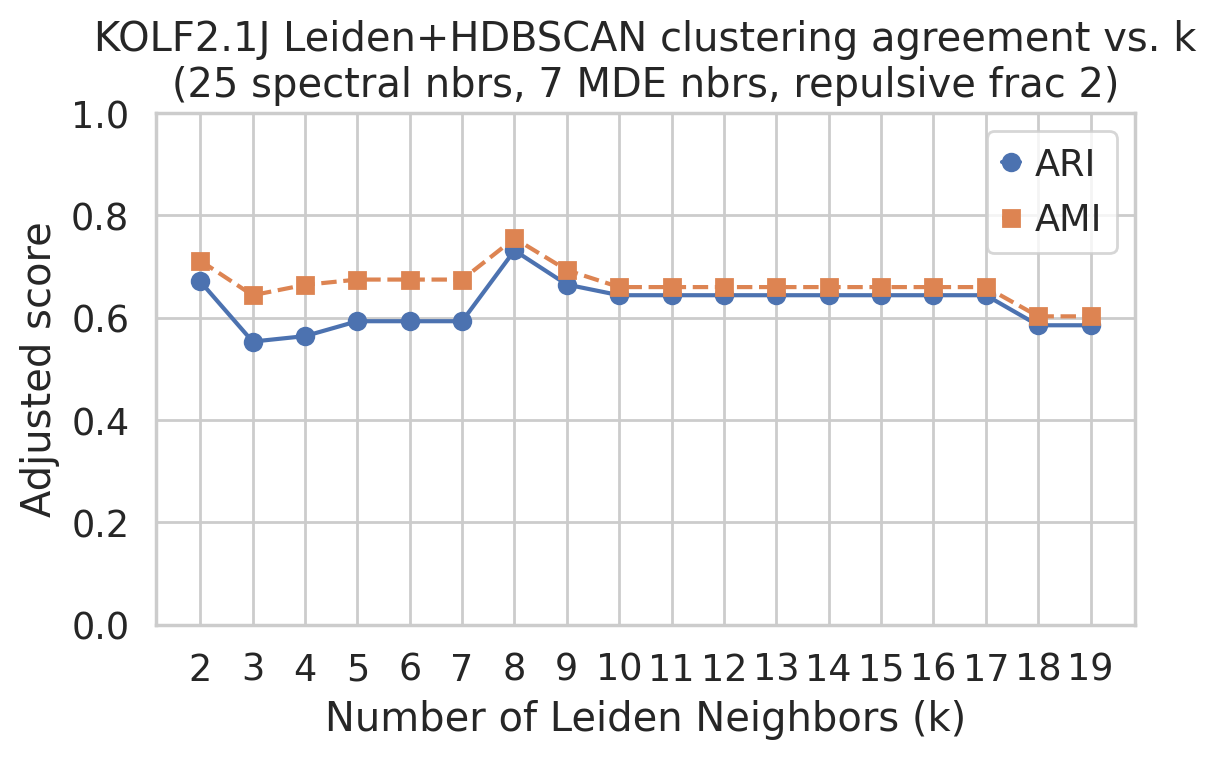

In [64]:
title = "KOLF2.1J Leiden+HDBSCAN clustering agreement vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 2)"
ari_ami_df = plot_cluster_agreement(mde_embedding, perturbation_HDBSCAN_labels,
                                    title=title)

In [65]:
ari_ami_df.head(10)

,ARI,AMI
2,0.671,0.711
3,0.553,0.644
4,0.564,0.664
5,0.593,0.674
6,0.593,0.674
7,0.593,0.674
8,0.731,0.755
9,0.665,0.693
10,0.644,0.660
11,0.644,0.660


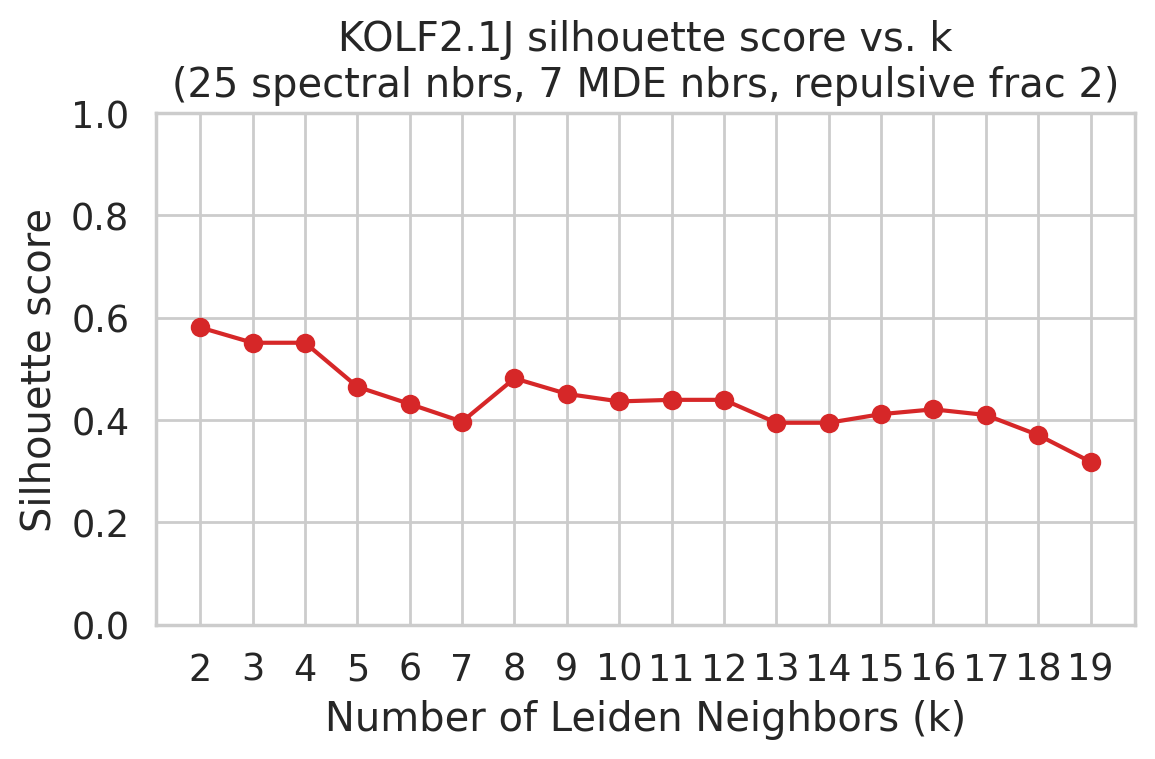

In [66]:
title = "KOLF2.1J silhouette score vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 2)"
silhouette_score_df = plot_silhouette_scores(mde_embedding, title=title)

In [67]:
silhouette_score_df.head(10)

,Silhouette score
2,0.581
3,0.551
4,0.551
5,0.465
6,0.431
7,0.397
8,0.481
9,0.451
10,0.436
11,0.439


### 8 KNN nbrs

In [91]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels, 
                            n_neighbors=8)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=8, # number of neighbors for KNN graph
                         title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 2)")

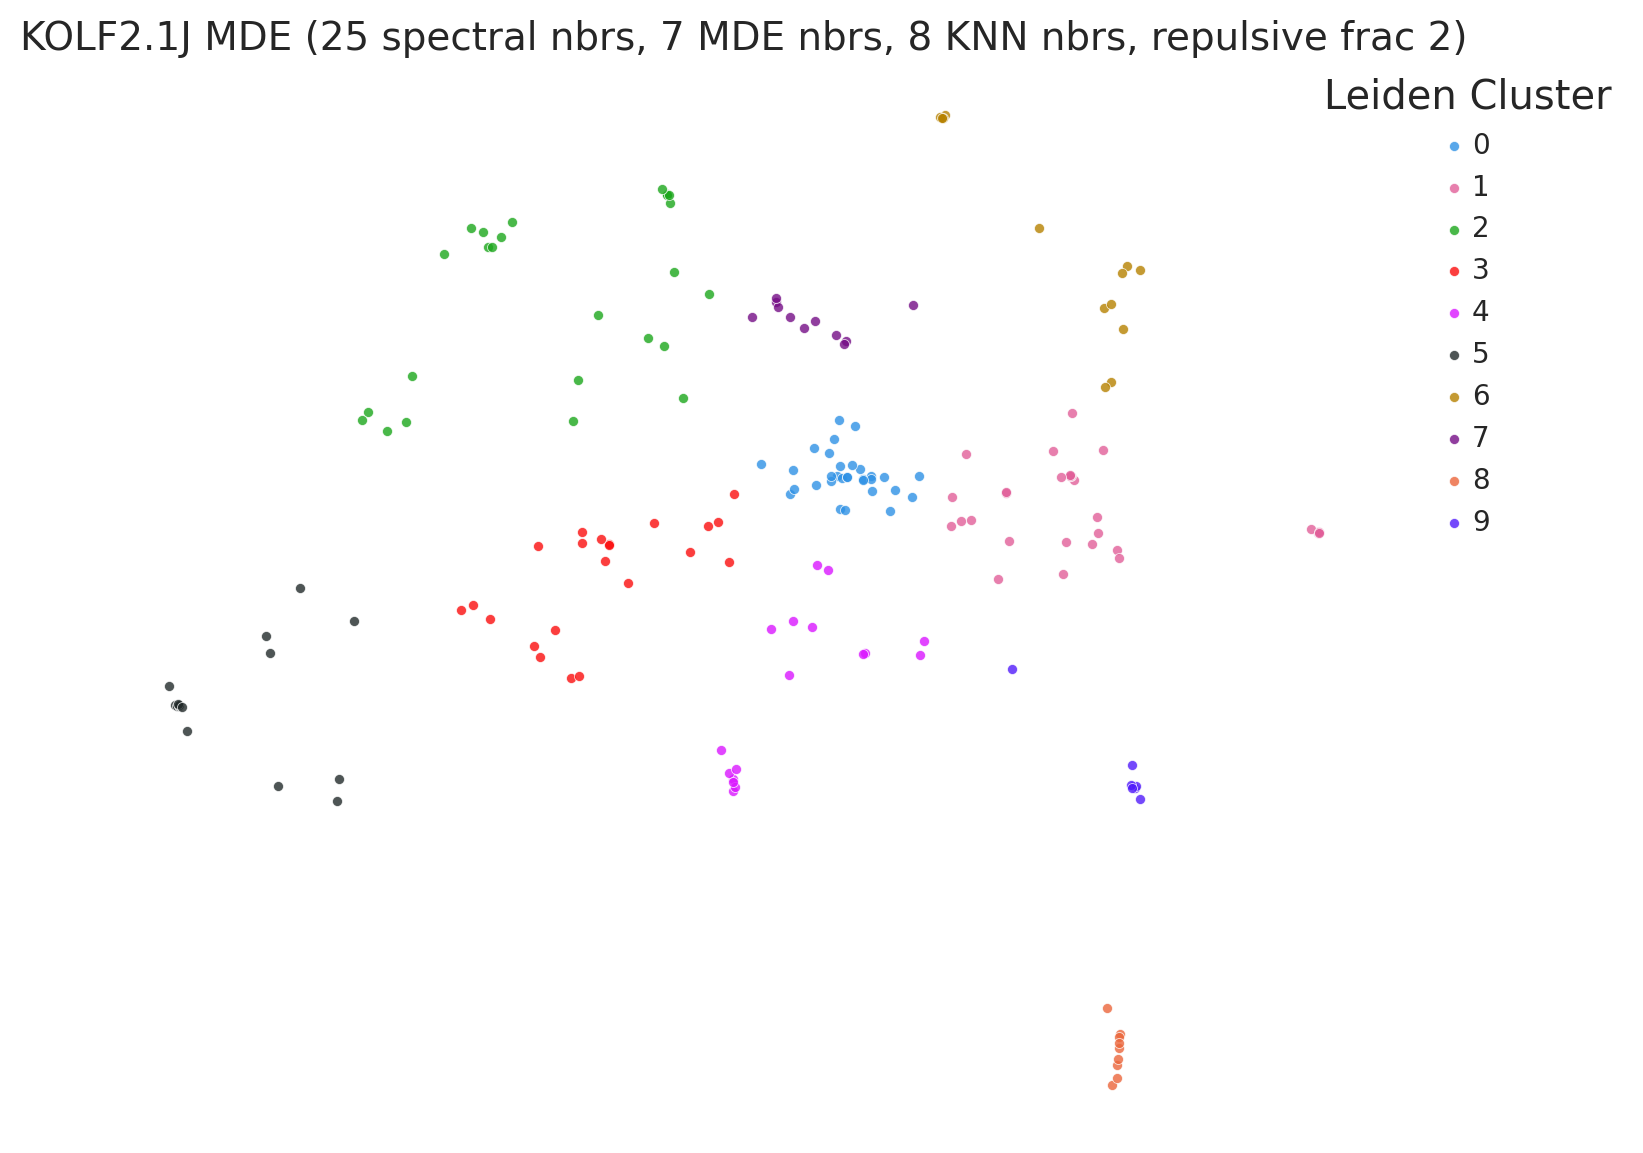

In [92]:
_ = plot_mde_static(mde_embedding, bulks_mde,
                    n_neighbors=8, # number of neighbors for KNN graph
                    title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 2)")

In [ ]:
_ = plot_mde_leiden_hdbscan(mde_embedding, perturbation_HDBSCAN_labels, 
                            bulks_mde, n_neighbors=8,
                            suptitle="KOLF2.1J MDE Leiden/HDBSCAN Clusters (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 2)")

In [ ]:
title="KOLF2.1J subset MDE Leiden Clusters & CORUM Complexes (25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 5)"
_ = plot_mde_leiden_corum(mde_embedding, bulks_mde, corum_complexes, n_neighbors=5,
                          suptitle=title)

In [ ]:
title="KOLF2.1J Pairwise Distance Matrix of Leiden Cluster Centroids\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
plot_pairwise_distance_matrix(mde_embedding, bulks_mde, n_neighbors=6, figsize=(6,6), tick_fontsize=10,
                              title=title, title_y_position=1.05)

In [48]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9
0,CREB3L3,ARID2,BARX1,ARNT2,EOMES,DOT1L,ARID3B,EBF2,ADNP2,ARHGAP35
1,CREBL2,ATF1,BCL6B,BATF,FOXD3,ETV3L,LEF1,GTF2IRD1,CHAMP1,JUNB
2,DMBX1,ATF4,BHLHE40,DMRT2,FOXE1,HMX3,RARG,HNF1A,DNMT1,KDM2A
3,DUXA,ESR1,CBX2,ELF4,KLF4,HNF4A,RFX7,HOXA7,E2F4,SOX4
4,ESRRG,ETV7,EBF3,FOXG1,MESP1,NANOG,SMAD3,SP110,PITX3,SOX11
5,IRF9,FOXH1,GLIS1,GATA5,RXRG,PHF20,THAP6,SP140L,SETDB1,ZNF205
6,IRX5,LCORL,GPBP1L1,HBP1,SIX5,PKNOX2,THAP12,ZNF22,VDR,ZNF219
7,NFKB2,MTERF1,GRHL2,KMT2B,SPDEF,POU3F2,TSHZ1,ZNF180,ZNF561,ZNF763
8,NKX2-4,NACC2,HIC1,MBD3,TMF1,POU5F1,ZNF14,ZNF316,ZNF562,NaN
9,NR5A1,NKX6-2,IKZF4,NFE2L2,ZBTB4,POU5F1B,ZNF16,ZNF420,NaN,NaN


In [ ]:
# leiden_filepath = \
#     "/home/ranwyl/output_files_tf_project/KOLF_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-2-26.csv"
# leiden_cluster_kds.to_csv(leiden_filepath)

In [ ]:
# leiden_filepath = \
#     "/home/ranwyl/output_files_tf_project/KOLF_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-2-26.csv"
# leiden_cluster_kds = pd.read_csv(leiden_filepath, header=0, index_col=0)
# leiden_cluster_kds.head()

[31, 29, 25, 22, 17, 15, 13, 11, 9, 8]


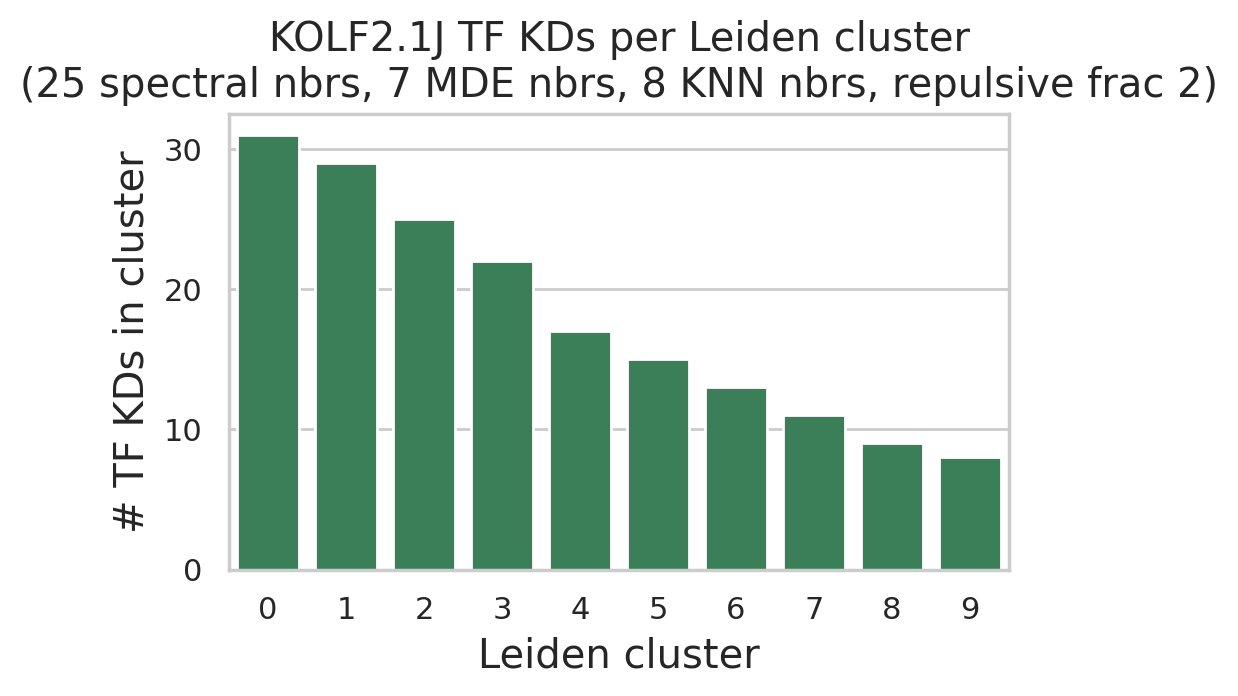

In [50]:
title = "KOLF2.1J TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 2)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title,
                         xlabel="Leiden cluster", color="seagreen", figsize=(5,3))

Check DEGs per cluster

In [51]:
sns.set_style("whitegrid")

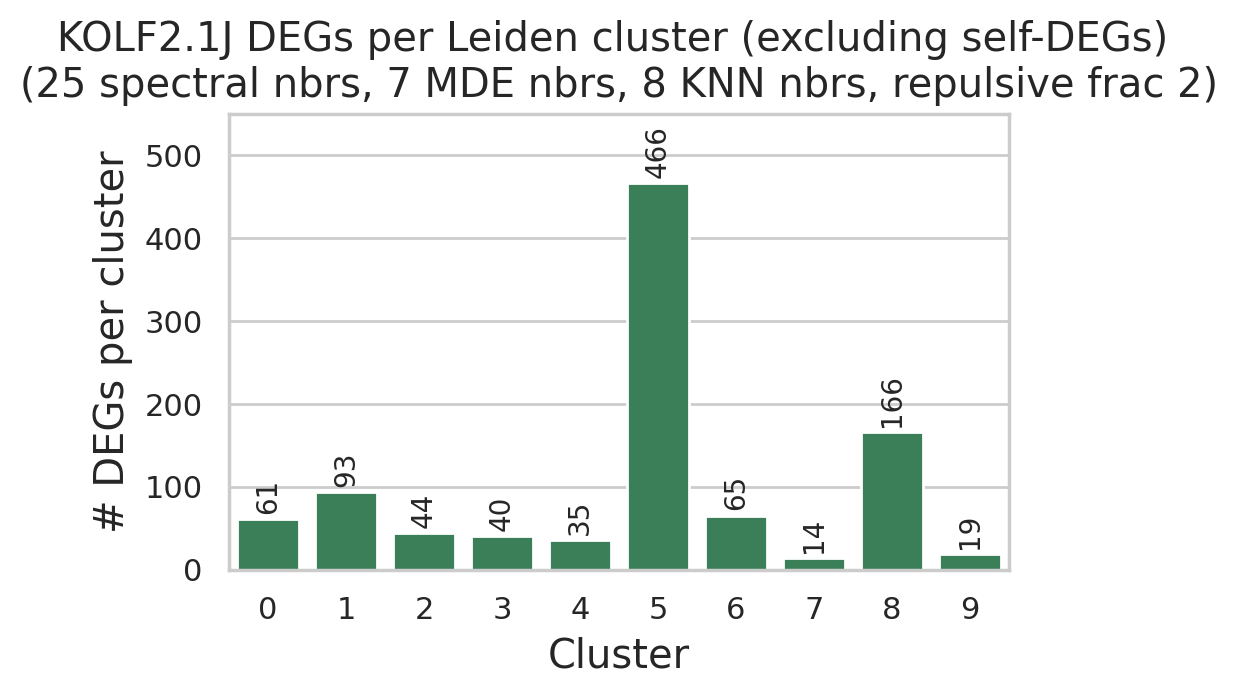

In [68]:
cluster_deg_dict_kolf = build_cluster_DEGs_dict(kd_deg_dict_kolf,
                                                leiden_cluster_kds)
title = "KOLF2.1J DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 2)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_kolf, title=title, color="seagreen", figsize=(5,3), ymax=550)

Check which clusters contain KDs of TFs with known function

In [53]:
pd.options.display.float_format = '{:,.0f}'.format

In [61]:
kds_high_degs = n_degs_df.head(20).index.tolist()
print(", ".join(kds_high_degs))

POU5F1, DNMT1, ZNF521, THAP12, ZNF396, NANOG, ADNP2, PHF20, CHAMP1, POU5F1B, SETDB1, FOXH1, POU3F2, FOXD3, ZNF787, ZNF462, REST, PITX3, TCF7L1, HMX3


In [62]:
find_kds_in_leiden_hdbscan_clusters(kds_high_degs, leiden_clusters_df=leiden_cluster_kds,
                                    hdbscan_clusters_df=hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
ZNF787,1,4
FOXH1,1,
ZNF462,1,
REST,1,
TCF7L1,2,
FOXD3,4,
POU5F1,5,3
ZNF521,5,3
ZNF396,5,3
NANOG,5,3


Check which Leiden clusters have HDBSCAN TF KDs

In [63]:
hdbscan_tf_kds = hdbscan_cluster_kds.to_numpy().flatten().tolist()
hdbscan_tf_kds = [kd for kd in hdbscan_tf_kds if not isinstance(kd, float)]
print(len(hdbscan_tf_kds))

38


In [64]:
leiden_hdbscan_df = \
    find_kds_in_leiden_hdbscan_clusters(hdbscan_tf_kds, leiden_clusters_df=leiden_cluster_kds,
                                        hdbscan_clusters_df=hdbscan_cluster_kds, sort_by="hdbscan")

In [65]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([0,1,2])]

,Leiden cluster,HDBSCAN cluster
CBX2,2,0
PCGF2,2,0
PKNOX2,5,0
ADNP2,8,1
CHAMP1,8,1
DNMT1,8,1
PITX3,8,1
SETDB1,8,1
VDR,8,1
ZNF695,0,2


In [66]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([3,4])]

,Leiden cluster,HDBSCAN cluster
NANOG,5,3
PHF20,5,3
POU3F2,5,3
POU5F1,5,3
POU5F1B,5,3
RBPJ,5,3
ZNF396,5,3
ZNF521,5,3
ZNF219,9,3
ZNF787,1,4


In [67]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([5])]

,Leiden cluster,HDBSCAN cluster
ESRRG,0,5
IRF9,0,5
IRX5,0,5
NFKB2,0,5
ZFP37,0,5
ZFP41,0,5
ZNF24,0,5
ZNF426,0,5
ZNF623,0,5
ZNF732,0,5


### 5 KNN nbrs

In [ ]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels, 
                            n_neighbors=5)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=8, # number of neighbors for KNN graph
                         title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 2)")

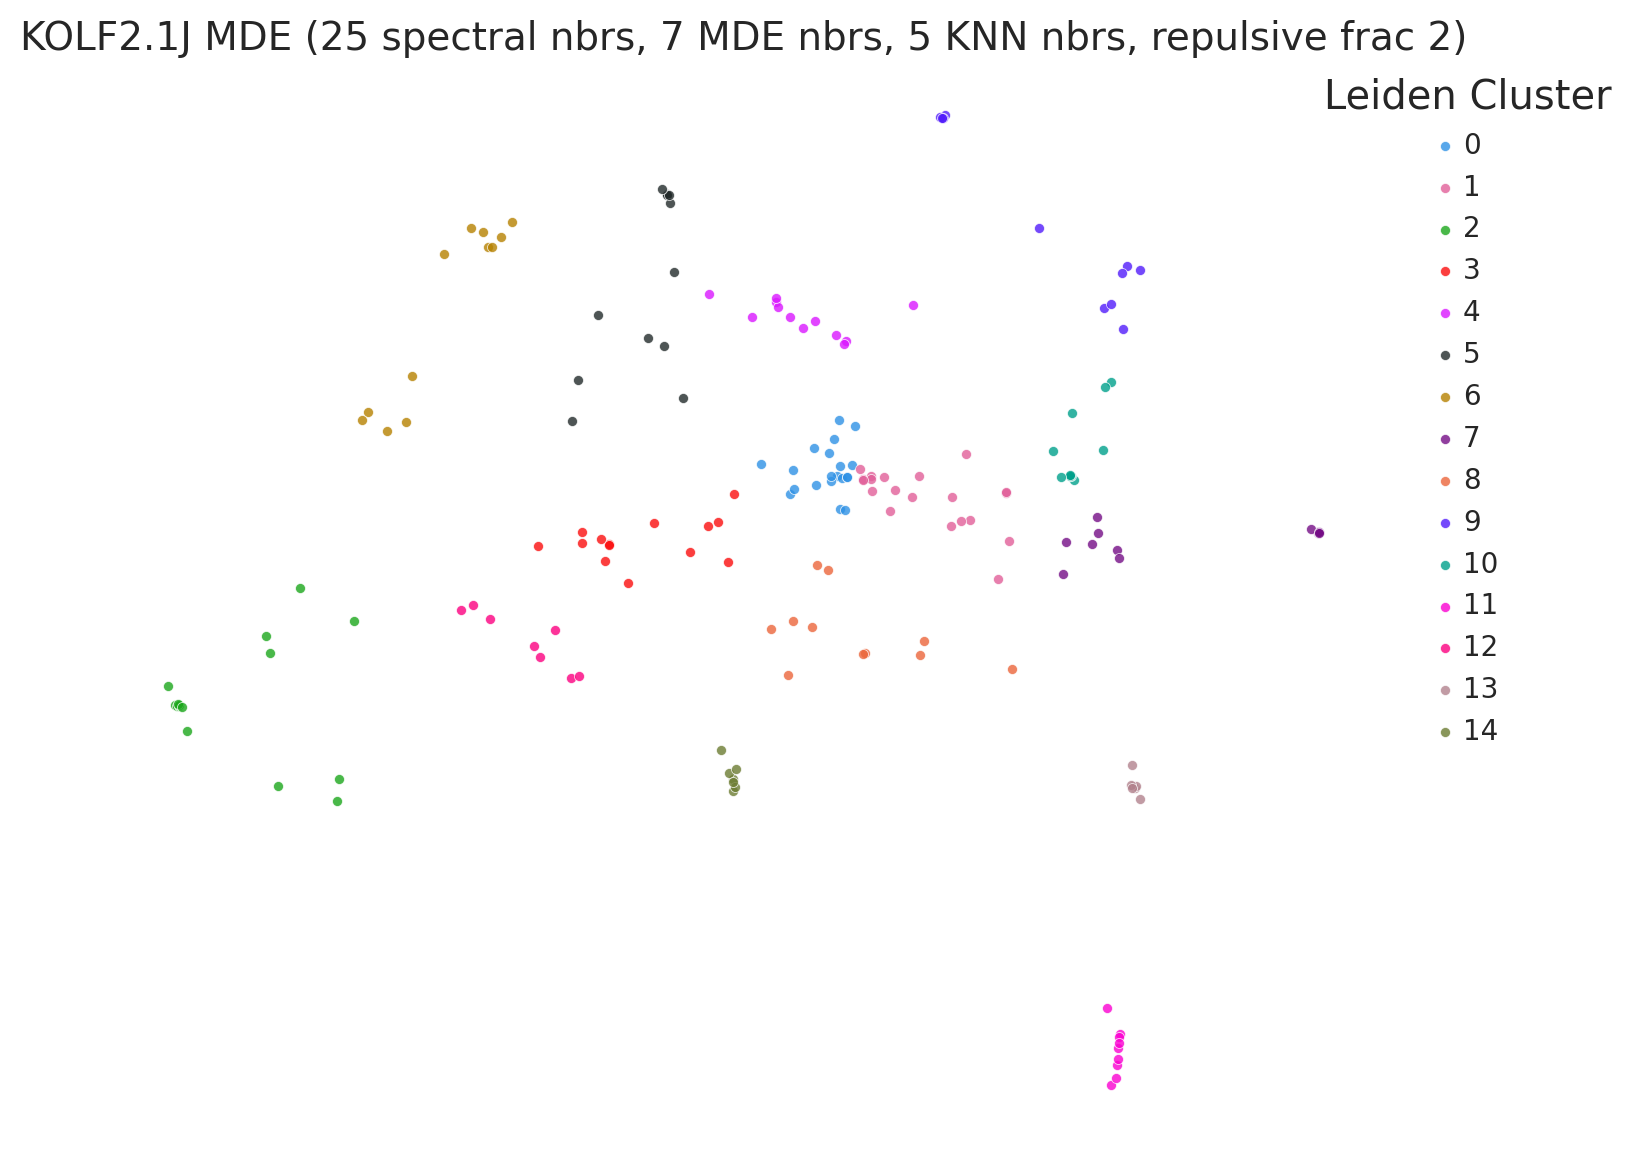

In [68]:
_ = plot_mde_static(mde_embedding, bulks_mde,
                    n_neighbors=5, # number of neighbors for KNN graph
                    title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 2)")

In [ ]:
_ = plot_mde_leiden_hdbscan(mde_embedding, perturbation_HDBSCAN_labels, 
                            bulks_mde, n_neighbors=8,
                            suptitle="KOLF2.1J MDE Leiden/HDBSCAN Clusters (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 2)")

In [ ]:
title="KOLF2.1J subset MDE Leiden Clusters & CORUM Complexes (25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 5)"
_ = plot_mde_leiden_corum(mde_embedding, bulks_mde, corum_complexes, n_neighbors=5,
                          suptitle=title)

In [ ]:
title="KOLF2.1J Pairwise Distance Matrix of Leiden Cluster Centroids\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
plot_pairwise_distance_matrix(mde_embedding, bulks_mde, n_neighbors=6, figsize=(6,6), tick_fontsize=10,
                              title=title, title_y_position=1.05)

In [69]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,CREB3L3,ATF1,HIC1,ARNT2,ARID3B,ATF4,FOXE1,ADNP2,DMRT2,BARX1,ARID2,DOT1L,ELF4,DMBX1,ARHGAP35,DUXA,CBX2,BCL6B,GLIS1,RFX7
1,ESRRG,EBF2,IRX5,BATF,CREBL2,EOMES,MESP1,CHAMP1,FOXG1,BHLHE40,FOXH1,HNF4A,HBP1,HOXA7,KDM2A,SP140L,PCGF2,LHX1,KLF14,SMAD3
2,HNF1A,ESR1,NKX6-2,GATA5,LEF1,ETV3L,SIX5,DNMT1,KMT2B,EBF3,JUNB,PHF20,HMX3,IRF9,SOX4,TBX19,PKNOX2,MESP2,L3MBTL3,TSHZ1
3,NFKB2,ETV7,PCGF6,IKZF4,NKX2-4,FOXD3,SPDEF,E2F4,NACC2,GPBP1L1,MTERF1,POU3F2,NANOG,TFCP2L1,SOX11,ZBTB34,ZNF22,POGK,TCF7L1,ZNF564
4,NR5A1,GTF2IRD1,PHF1,NFE2L2,RARG,KLF4,TMF1,PITX3,NR4A3,GRHL2,THAP12,POU5F1,RFX5,ZNF341,ZNF205,ZNF180,ZNF382,SP8,ZNF324,ZNF783
5,OVOL3,LCORL,POU4F3,ZNF394,THAP6,RBPJ,ZBTB22,SETDB1,REST,POU2F1,ZBTB12,POU5F1B,SNAI2,ZNF462,ZNF219,ZNF701,ZNF596,NaN,NaN,NaN
6,SP110,MBD3,RFX2,ZNF490,ZNF14,RXRG,ZNF517,VDR,TCF20,RREB1,ZBTB14,ZNF396,ZFP92,ZNF471,ZNF763,NaN,NaN,NaN,NaN,NaN
7,ZFP37,RAG1,SETDB2,ZNF614,ZNF16,SP1,ZNF688,ZNF561,TGIF2,ZFY,ZNF358,ZNF521,ZNF572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ZFP41,RORC,SIX6,ZNF658,ZNF112,ZNF142,ZSCAN5B,ZNF562,ZBTB39,ZNF292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ZNF24,ZBTB21,TIGD7,ZNF764,ZNF551,ZNF787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[17, 16, 15, 11, 10, 10, 9, 9, 9, 9, 8, 8, 8, 7, 7, 6, 6, 5, 5, 5]


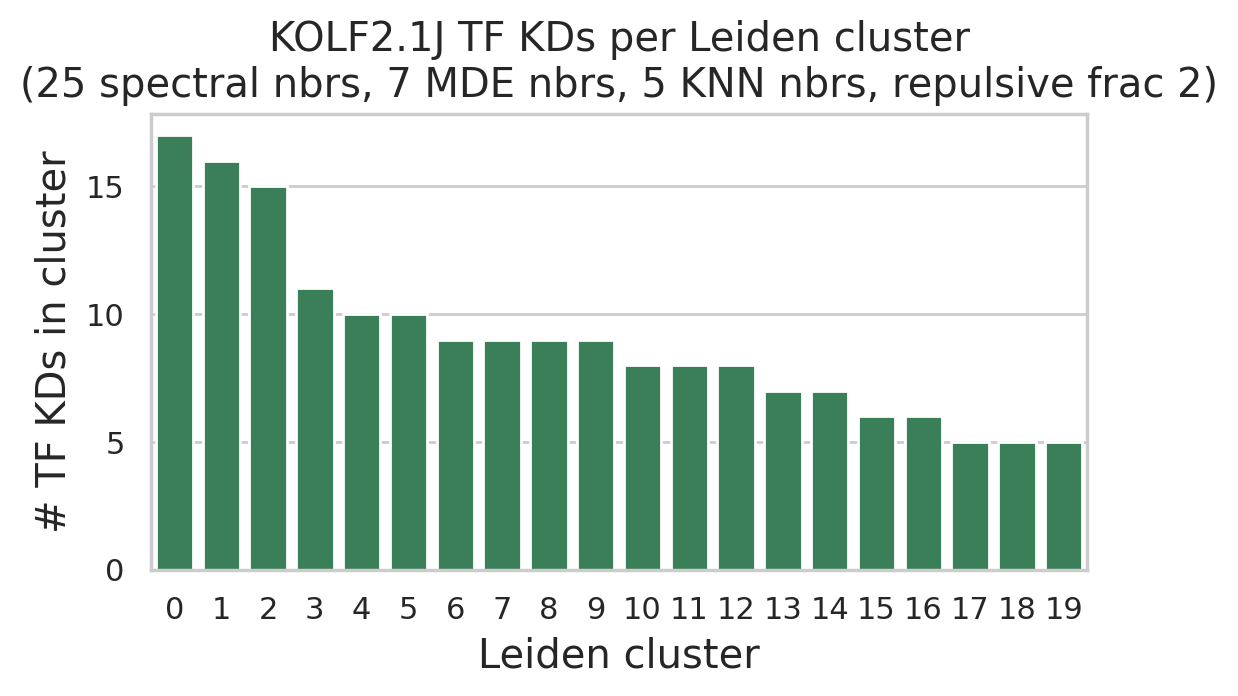

In [70]:
title = "KOLF2.1J TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 2)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title,
                         xlabel="Leiden cluster", color="seagreen", figsize=(6,3))

Check DEGs per cluster

In [71]:
sns.set_style("whitegrid")

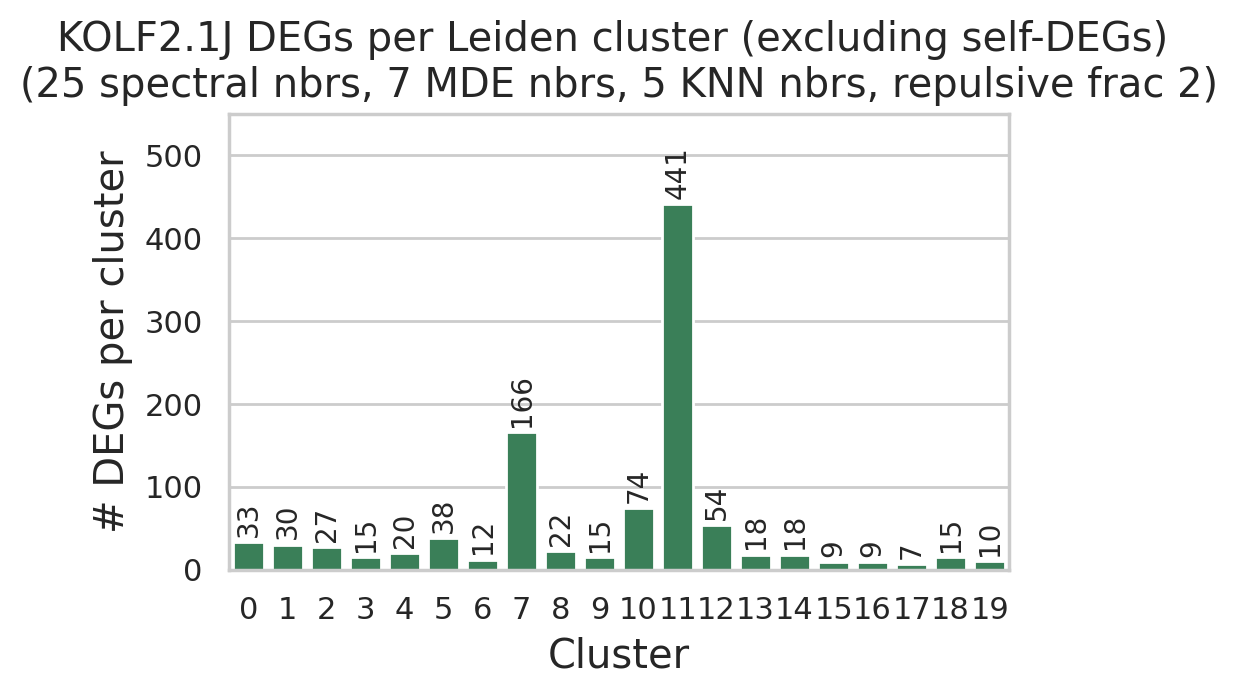

In [72]:
cluster_deg_dict_kolf = build_cluster_DEGs_dict(kd_deg_dict_kolf,
                                                leiden_cluster_kds)
title = "KOLF2.1J DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 2)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_kolf, title=title, color="seagreen", figsize=(5,3), ymax=550)

Check which clusters contain KDs of TFs with known function

In [73]:
pd.options.display.float_format = '{:,.0f}'.format

In [74]:
kds_high_degs = n_degs_df.head(20).index.tolist()
print(", ".join(kds_high_degs))

POU5F1, DNMT1, ZNF521, THAP12, ZNF396, NANOG, ADNP2, PHF20, CHAMP1, POU5F1B, SETDB1, FOXH1, POU3F2, FOXD3, ZNF787, ZNF462, REST, PITX3, TCF7L1, HMX3


In [75]:
find_kds_in_leiden_hdbscan_clusters(kds_high_degs, leiden_clusters_df=leiden_cluster_kds,
                                    hdbscan_clusters_df=hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
ZNF787,5,4
FOXD3,5,
DNMT1,7,1
ADNP2,7,1
CHAMP1,7,1
SETDB1,7,1
PITX3,7,1
REST,8,
THAP12,10,
FOXH1,10,


## MDE (25 spectral nbrs, 7 MDE nbrs, repulsive fraction 1)

In [94]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                   n_components=20,
                                   spectral_n_neighbors=25,
                                   mde_n_neighbors=7, 
                                   repulsive_fraction=1)

Jun 05 12:00:40 AM: Fitting a centered embedding into R^2, for a graph with 180 items and 2002 edges.
Jun 05 12:00:40 AM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 05 12:00:40 AM: iteration 0000 | distortion 0.620689 | residual norm 0.247875 | step length 0.363288 | percent change 0.474605
Jun 05 12:00:40 AM: iteration 0200 | distortion 0.360699 | residual norm 0.000434868 | step length 1 | percent change 0.114163
Jun 05 12:00:41 AM: iteration 0400 | distortion 0.360672 | residual norm 2.11817e-05 | step length 0 | percent change 0
Jun 05 12:00:43 AM: iteration 0600 | distortion 0.360672 | residual norm 2.11817e-05 | step length 0 | percent change 0
Jun 05 12:00:44 AM: iteration 0800 | distortion 0.360672 | residual norm 2.11817e-05 | step length 0 | percent change 0
Jun 05 12:00:46 AM: iteration 1000 | distortion 0.360672 | residual norm 2.11817e-05 | step length 0 | percent change 0
Jun 05 12:00:47 AM: iteration 1200 | distortion 0.360672 | residual no

Choose number of neighbors for KNN graph based on agreement with HDBSCAN clusters

In [ ]:
pd.set_option('display.precision', 3)

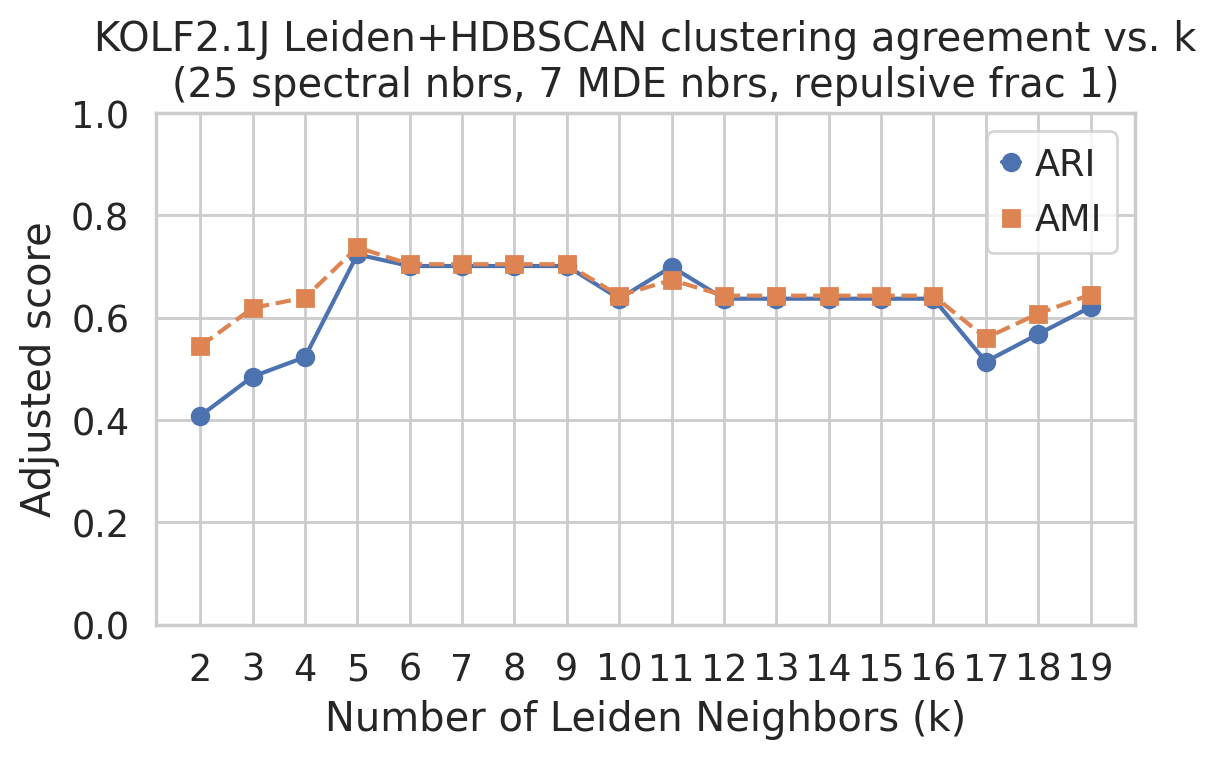

In [95]:
title = "KOLF2.1J Leiden+HDBSCAN clustering agreement vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 1)"
ari_ami_df = plot_cluster_agreement(mde_embedding, perturbation_HDBSCAN_labels,
                                    title=title)

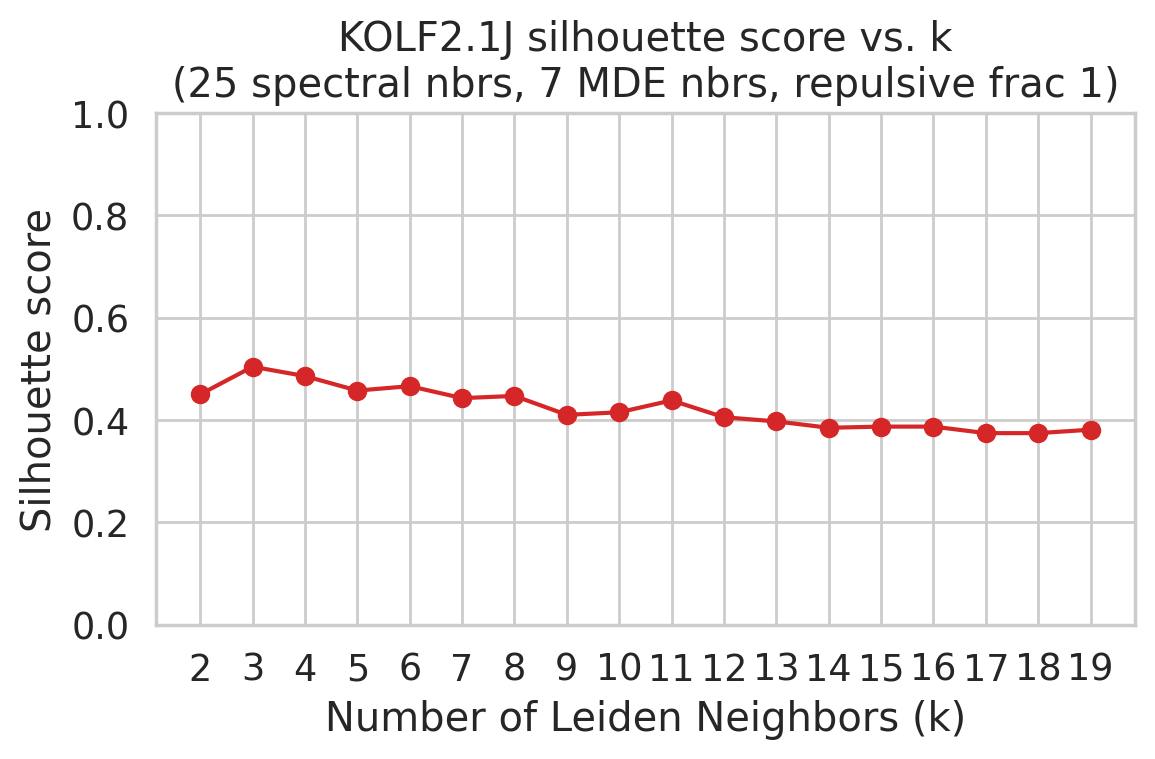

In [96]:
title = "KOLF2.1J silhouette score vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 1)"
silhouette_score_df = plot_silhouette_scores(mde_embedding, title=title)

### 5 KNN nbrs

In [97]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels, 
                            n_neighbors=5)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=8, # number of neighbors for KNN graph
                         title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 2)")

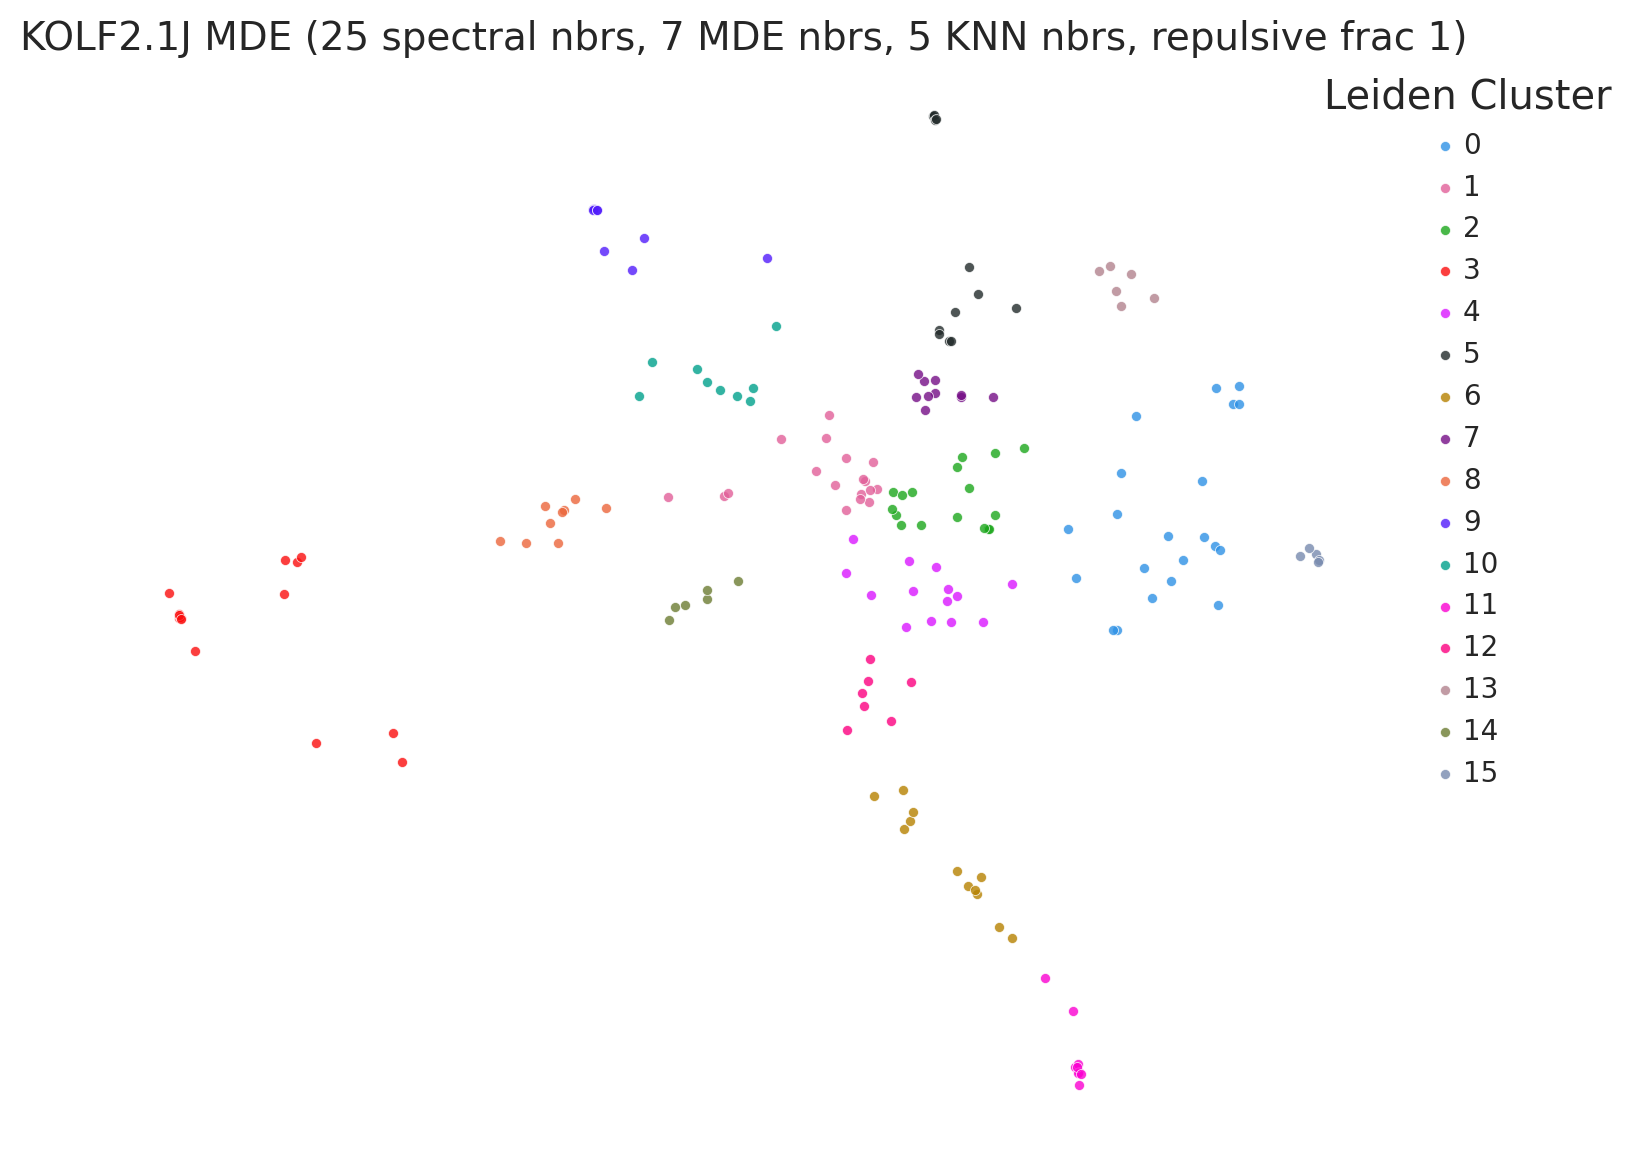

In [98]:
_ = plot_mde_static(mde_embedding, bulks_mde,
                    n_neighbors=5, # number of neighbors for KNN graph
                    title="KOLF2.1J MDE (25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 1)")

In [99]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,ARID2,ARNT2,CREBL2,DOT1L,EOMES,FOXE1,ARHGAP35,DMRT2,CBX2,BARX1,GATA5,ADNP2,BCL6B,ARID3B,EBF2,NACC2
1,ATF1,BATF,ESRRG,ETV3L,KLF4,MESP1,GLIS1,DUXA,ELF4,BHLHE40,NFE2L2,CHAMP1,DMBX1,KMT2B,GTF2IRD1,REST
2,ATF4,CREB3L3,IRF9,HMX3,NKX6-2,NR4A3,KDM2A,FOXG1,HBP1,EBF3,POU2F1,DNMT1,JUNB,THAP6,HNF1A,TCF20
3,ESR1,FOXD3,NR5A1,HNF4A,RXRG,RARG,KLF14,MBD3,IKZF4,GPBP1L1,ZNF394,E2F4,LHX1,ZNF14,HOXA7,TGIF2
4,ETV7,HIC1,PHF1,NANOG,TIGD7,RFX7,L3MBTL3,NKX2-4,PCGF2,GRHL2,ZNF490,PITX3,MESP2,ZNF16,ZNF420,ZBTB39
5,FOXH1,IRX5,POU4F3,PHF20,ZBTB4,SIX5,SOX4,TMF1,SNAI2,PCGF6,ZNF658,SETDB1,POGK,ZNF112,ZNF471,NaN
6,LCORL,NFKB2,RAG1,PKNOX2,ZBTB34,SMAD3,SOX11,ZBTB22,ZNF22,RREB1,ZNF764,VDR,SP8,NaN,NaN,NaN
7,LEF1,OVOL3,SETDB2,POU3F2,ZNF136,SPDEF,TCF7L1,ZNF316,ZNF382,ZFY,ZNF841,ZNF561,NaN,NaN,NaN,NaN
8,MTERF1,RFX5,ZBTB12,POU5F1,ZNF142,TSHZ1,ZNF205,ZNF551,ZNF596,ZNF292,ZSCAN18,ZNF562,NaN,NaN,NaN,NaN
9,RFX2,SIX6,ZFP1,POU5F1B,ZNF341,ZNF517,ZNF219,ZSCAN5B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[21, 18, 17, 15, 14, 13, 12, 10, 9, 9, 9, 9, 7, 6, 6, 5]


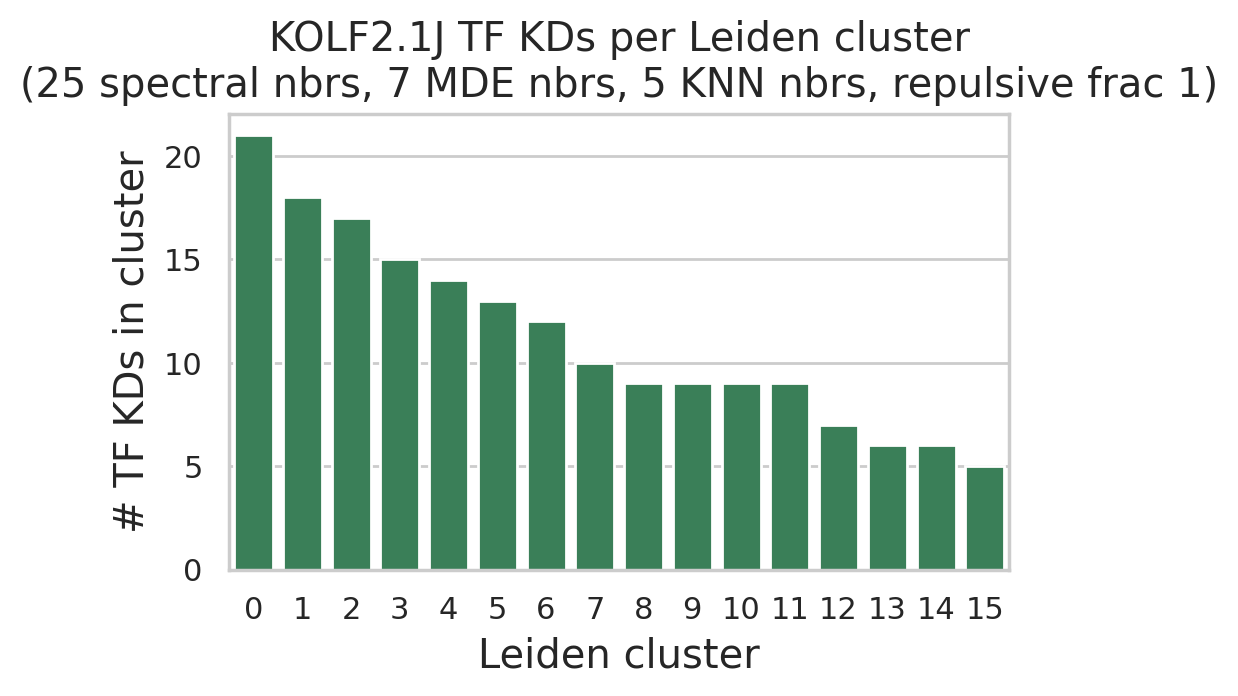

In [103]:
title = "KOLF2.1J TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 1)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title,
                         xlabel="Leiden cluster", color="seagreen", figsize=(5,3))

Check DEGs per cluster

In [101]:
sns.set_style("whitegrid")

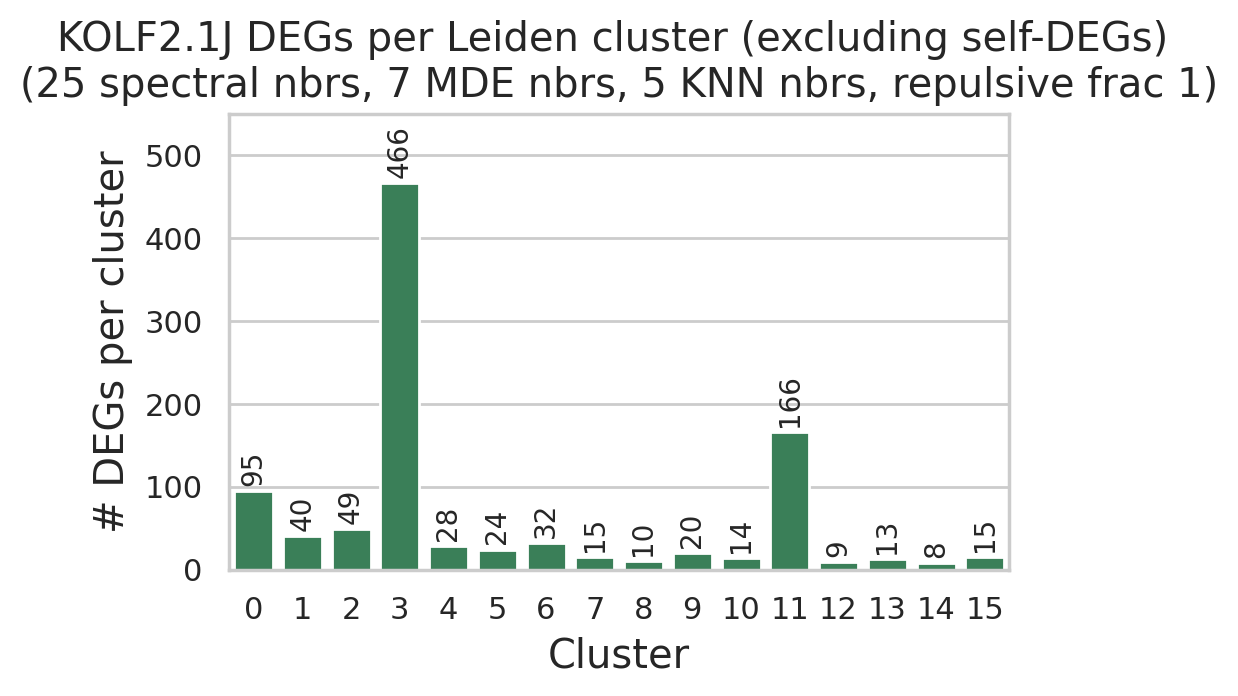

In [102]:
cluster_deg_dict_kolf = build_cluster_DEGs_dict(kd_deg_dict_kolf,
                                                leiden_cluster_kds)
title = "KOLF2.1J DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 5 KNN nbrs, repulsive frac 1)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_kolf, title=title, color="seagreen", figsize=(5,3), ymax=550)

Check which clusters contain KDs of TFs with known function

In [104]:
pd.options.display.float_format = '{:,.0f}'.format

In [ ]:
pluripotency_tfs = ['POU5F1', 'NANOG', 'SOX2', 'KLF4', 'MYC']
find_kds_in_leiden_hdbscan_clusters(pluripotency_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
POU5F1,3,3
NANOG,3,3
KLF4,4,
SOX2,,
MYC,,


## MDE (7 spectral nbrs, 7 MDE nbrs, repulsive fraction 5)

In [113]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                   n_components=20,
                                   spectral_n_neighbors=7,
                                   mde_n_neighbors=7, 
                                   repulsive_fraction=5)

Jun 02 11:17:40 PM: Your dataset appears to contain duplicated items (rows); when embedding, you should typically have unique items.
Jun 02 11:17:40 PM: The following items have duplicates [ 77 147]
Jun 02 11:17:40 PM: Fitting a centered embedding into R^2, for a graph with 180 items and 5306 edges.
Jun 02 11:17:40 PM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 02 11:17:40 PM: iteration 0000 | distortion 1.327935 | residual norm 0.831824 | step length 0.0989436 | percent change 0.433779
Jun 02 11:17:41 PM: iteration 0200 | distortion 0.218079 | residual norm 0.000548869 | step length 1 | percent change 0.0319225
Jun 02 11:17:41 PM: iteration 0400 | distortion 0.217166 | residual norm 0.000735286 | step length 1 | percent change 0.202956
Jun 02 11:17:41 PM: iteration 0600 | distortion 0.216334 | residual norm 0.000114189 | step length 1 | percent change 0.016514
Jun 02 11:17:43 PM: iteration 0800 | distortion 0.216330 | residual norm 9.10328e-05 | step len

Jun 02 11:17:46 PM: iteration 1000 | distortion 0.216330 | residual norm 9.10328e-05 | step length 0 | percent change 0
Jun 02 11:17:49 PM: iteration 1200 | distortion 0.216330 | residual norm 9.10328e-05 | step length 0 | percent change 0
Jun 02 11:17:52 PM: iteration 1400 | distortion 0.216330 | residual norm 9.10328e-05 | step length 0 | percent change 0
Jun 02 11:17:55 PM: iteration 1600 | distortion 0.216330 | residual norm 9.10328e-05 | step length 0 | percent change 0
Jun 02 11:17:58 PM: iteration 1800 | distortion 0.216330 | residual norm 9.10328e-05 | step length 0 | percent change 0
Jun 02 11:18:01 PM: iteration 1999 | distortion 0.216330 | residual norm 9.10328e-05 | step length 0 | percent change 0
Jun 02 11:18:01 PM: Finished fitting in 21.224 seconds and 2000 iterations.
Jun 02 11:18:01 PM: average distortion 0.216 | residual norm 9.1e-05
